<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>51095 מודלי יסוד: ארכיטקטורות, אימון ויישור</p>
<p>מטלת בית 2 — LLM Alignment</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבנה המחברת:</p>
<ul>
<li>חלק א׳ — SFT מלא על 3,000 דוגמאות Dolly-15k, 12 פרומפטים קבועים לפני ואחרי</li>
<li>חלק ב׳ — Full FT מול LoRA מול QLoRA: פרמטרים, זיכרון, זמן ואיכות</li>
<li>חלק ג׳ — 200 דוגמאות בלבד, ו-3,000 שב-30% מהן התשובה הוחלפה</li>
<li>חלק ד׳ — 300 פרומפטים, שתי דגימות לכל אחד, שופט זוגי ו-reward model</li>
<li>חלק ה׳ — DPO מול SFT, עם שופט שני לבדיקת מעגליות</li>
<li>חלק ו׳ — Best-of-N עם N=4 ו-N=8 מול DPO, איכות מול עלות</li>
<li>בונוס: LoRA על attention בלבד מול כל השכבות</li>
<li>חוסן לפי seed, וסינתזה</li>
<li>מגבלות, נספח פלטים גולמיים של השופט, ו-README</li>
</ul>
<p>מודל: Qwen2.5-0.5B base. שופט: Phi-4, 14B ב-NF4. שופט שני: Granite-3.3-8B. הדו"ח בתוך המחברת, לפי הנחיית המרצה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תקציר מנהלים:</p>
<ul>
<li>SFT — Full FT על 3,000 דוגמאות Dolly הפך את Qwen2.5-0.5B base לעוזר: 100% עצירה עצמית, תשובות קצרות פי 5, ובדיקות שעלו מ-6 ל-9 מ-12. ב-epoch השני לוס ה-held-out עלה: התאמת-יתר</li>
<li>PEFT — LoRA באיכות Full FT (0.50 בהשוואה ישירה), עם 1.8% מהפרמטרים ו-43% פחות זיכרון. QLoRA איטית ב-27% ולא חוסכת זיכרון ב-0.5B</li>
<li>דאטה — 200 דוגמאות נוטות להפסיד ל-3,000 (0.43), ו-30% תשובות מוחלפות לא שינו דבר (0.51). הלוס מבחין בין התצורות, השופט לא</li>
<li>העדפות — 190 זוגות מ-300 פרומפטים. אין הטיה מצטברת למיקום או לאורך, אבל 21% מהפסקים התהפכו עם הסדר. ה-reward model בלי אות (0.45 ב-cross-validation, 0.50 ב-held-out)</li>
<li>DPO — התוצאה המוכרעת היחידה של יישור: 0.66 ב-Phi-4, ו-0.63 באותו כיוון ב-Granite. אבל התשובות התארכו, ו-DPO עוברת 6 בדיקות מול 9</li>
<li>Best-of-N — אין שיפור (0.44 ב-Phi-4, 0.48 ב-Granite), כצפוי מ-reward model בלי אות. פי 7 טוקנים</li>
<li>בונוס — LoRA על attention בלבד: פי 4 פחות פרמטרים ו-21% פחות זמן, בלי פגיעה מדידה (0.43)</li>
<li>שחזוריות — אותו קוד על L4 נתן מסקנה אחרת בארבע השוואות, וגם בתוך ההרצה הזו חלק מההשוואות מתהפכות בין שני ה-seeds</li>
</ul>
<p>המלצה: LoRA על כל השכבות הליניאריות. DPO מראה שיפור מבטיח אבל שביר, ו-Best-of-N דורש reward model טוב יותר. המספרים בסוגריים הם pref_decisive, ומוכרע פירושו רווח סמך של 95% שלא כולל 0.5.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>עקרונות הניסוי:</p>
<ul>
<li>משתנה אחד בכל השוואה: אותו בסיס, דאטה, epochs, אורך רצף, optimizer ו-seed</li>
<li>קצב הלמידה שונה בין Full FT ל-LoRA, לפי הערך המקובל לכל שיטה</li>
<li>כל השוואת שופט רצה בשני seeds של דגימה ובשני סדרי הצגה</li>
<li>המדדים והבדיקות הוגדרו לפני ההרצה</li>
<li>בכל ניתוח, המספרים הם תוצאה מדודה. "לשאלת הניתוח" הוא פרשנות, ו"ייתכן" או "הסבר אפשרי" מסמנים ספקולציה, כנדרש בנספח א׳</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התקנת הספריות, בגרסאות נעוצות כדי שההרצה תהיה ניתנת לשחזור. הפקודה הראשונה, pip install:</p>
<ul>
<li>q — מצב שקט, מסתיר את פלט ההתקנה</li>
<li>U — עדכון, כך שגם ספריות שכבר מותקנות ב-Colab מוחלפות בגרסה הנעוצה</li>
<li>transformers 5.16.1 — טעינת המודלים והטוקנייזרים, יצירת טקסט, ומנגנון האימון</li>
<li>trl 1.13.0 — SFTTrainer לחלקים א׳ עד ג׳, ו-DPOTrainer לחלק ה׳</li>
<li>peft 0.20.0 — מתאמי LoRA ו-QLoRA, ואימון השורה של im_end</li>
<li>datasets 5.0.1 — טעינת Dolly-15k מ-Hugging Face</li>
<li>accelerate 1.15.0 — ניהול המכשיר וה-dtype בזמן האימון</li>
<li>bitsandbytes 0.47 ומעלה — קוונטיזציית NF4 ל-QLoRA ולשופט Phi-4</li>
<li>sentencepiece — טוקנייזרים של השופטים</li>
<li>scikit-learn — הרגרסיה הלוגיסטית של ה-reward model בחלק ד׳</li>
</ul>
<p>הפקודה השנייה, pip uninstall:</p>
<ul>
<li>y — אישור אוטומטי, בלי שאלה</li>
<li>q — מצב שקט</li>
<li>torchao — Colab מגיע עם גרסה 0.10, ו-peft 0.20 עוצר את האימון מולה. המחברת לא משתמשת בו, ולכן הוא מוסר</li>
</ul>
</div>

In [1]:
!pip install -q -U "transformers==5.16.1" "trl==1.13.0" "peft==0.20.0" "datasets==5.0.1" "accelerate==1.15.0" "bitsandbytes>=0.47" sentencepiece scikit-learn
!pip uninstall -y -q torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 141.8 MB/s eta 0:00:00


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כל הייבואים של המחברת, בתא אחד:</p>
<ul>
<li>os — משתני סביבה ונתיבי קבצים</li>
<li>sys — גרסת Python, ורשימת המודולים הטעונים לתיקון torchao</li>
<li>gc — שחרור זיכרון בין אימונים</li>
<li>re — ביטויים רגולריים בבדיקות האוטומטיות ובקריאת פסקי השופט</li>
<li>json — הדפסה ושמירה של התוצאות</li>
<li>time — מדידת זמני יצירה והמתנה בין ניסיונות לשופט API</li>
<li>math — חישוב מספר הצעדים, רווח הסמך, והקו של log 2 בגרף DPO</li>
<li>random — קביעת seed</li>
<li>warnings — השתקת אזהרות</li>
<li>importlib.metadata — הגרסאות שהותקנו בפועל, לתא הגרסאות</li>
<li>numpy — חישובים סטטיסטיים</li>
<li>pandas — כל הטבלאות</li>
<li>torch — המודלים, הכרטיס ומדידת הזיכרון</li>
<li>matplotlib — כל הגרפים</li>
<li>transformers — גרסה לתיעוד, seed, והשתקת הלוגים</li>
<li>datasets — גרסה לתיעוד</li>
<li>peft — גרסה לתיעוד</li>
<li>trl — גרסה לתיעוד</li>
<li>peft.import_utils — המודול שבו נמצאת בדיקת torchao</li>
<li>AutoTokenizer — טעינת הטוקנייזרים של המודל והשופטים</li>
<li>AutoModelForCausalLM — טעינת המודל והשופטים</li>
<li>BitsAndBytesConfig — הגדרת NF4 ל-QLoRA ולשופט Phi-4</li>
<li>load_dataset — טעינת Dolly-15k</li>
<li>Dataset — בניית סטי האימון וזוגות ה-DPO</li>
<li>LoraConfig — הגדרת מתאמי LoRA</li>
<li>prepare_model_for_kbit_training — הכנת בסיס ב-NF4 לאימון QLoRA</li>
<li>SFTConfig — הגדרות אימון ה-SFT</li>
<li>SFTTrainer — אימון ה-SFT, בחלקים א׳ עד ג׳ ובבונוס</li>
<li>DPOConfig — הגדרות אימון ה-DPO</li>
<li>DPOTrainer — אימון ה-DPO בחלק ה׳</li>
<li>model_info — מזהה הגרסה המדויק של כל מודל ב-Hub</li>
<li>dataset_info — מזהה הגרסה המדויק של הדאטהסט ב-Hub</li>
<li>LogisticRegression — ה-reward model</li>
<li>StandardScaler — נרמול ההטמעות לפני ה-reward model</li>
<li>GroupKFold — cross-validation לפי זוגות</li>
<li>bitsandbytes — ל-NF4. בתוך try, ו-HAS_BNB מסמן אם הוא מותקן</li>
<li>google.colab ו-userdata — קריאת מפתחות משופט API אופציונלי. בתוך try, ו-IN_COLAB מסמן אם הריצה ב-Colab</li>
<li>openai — לשופט API אופציונלי. בתוך try, כי ייתכן שאינו מותקן</li>
<li>תיקון torchao: אחרי הייבוא, בדיקת torchao בכל מודולי peft מוחלפת ב-False, למקרה שההסרה בתא ההתקנה לא נקלטה</li>
</ul>
</div>

In [2]:
import os, sys, gc, re, json, time, math, random, warnings
import importlib.metadata as im

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import transformers, datasets, peft, trl
import peft.import_utils as _peft_import_utils
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset, Dataset
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer, DPOConfig, DPOTrainer
from huggingface_hub import model_info, dataset_info
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

try:
    import bitsandbytes as bnb
    HAS_BNB = True
except Exception:
    HAS_BNB = False
try:
    import google.colab
    from google.colab import userdata
    IN_COLAB = True
except Exception:
    userdata = None
    IN_COLAB = False
try:
    from openai import OpenAI
except Exception:
    OpenAI = None

_peft_import_utils.is_torchao_available.cache_clear()
for _name, _mod in list(sys.modules.items()):
    if _name.split(".")[0] == "peft" and hasattr(_mod, "is_torchao_available"):
        _mod.is_torchao_available = lambda: False

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרות הסביבה, לפי הסדר בתא:</p>
<ul>
<li>PYTORCH_CUDA_ALLOC_CONF — הקצאת זיכרון גמישה בכרטיס, שמפחיתה פיצול זיכרון ונפילות על חוסר זיכרון בין אימונים</li>
<li>WANDB_DISABLED — מכבה את Weights &amp; Biases, כדי שה-Trainer לא ינסה להתחבר לשירות חיצוני</li>
<li>TOKENIZERS_PARALLELISM — מכבה את המקביליות של הטוקנייזר, שמייצרת אזהרות כשהתהליך מתפצל</li>
<li>warnings.filterwarnings — השתקת אזהרות Python, כדי שהפלטים יכילו רק תוצאות</li>
<li>transformers.logging — מציג רק שגיאות מ-transformers, בלי הודעות מידע</li>
<li>plt.style — סגנון ggplot אחיד לכל הגרפים</li>
<li>max_colwidth — עד 90 תווים בתא טבלה, כדי שתשובות ארוכות לא ישברו את הטבלה</li>
<li>display.width — טבלה ברוחב 200 תווים, כדי שעמודות לא יתפצלו לשורות</li>
<li>display — הפונקציה שמציגה טבלאות. מחוץ למחברת, בבדיקת העשן, היא מוחלפת ב-print</li>
</ul>
</div>

In [3]:
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()
plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)
try:
    display
except NameError:
    display = print

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרות ההרצה, במקום אחד, לפי הסדר בתא:</p>
<ul>
<li>SMOKE — הרצה מוקטנת על CPU לבדיקת הקוד בלבד. בהרצה ב-Colab הוא כבוי</li>
<li>GLOBAL_SEED — 51095, ה-seed של כל המחברת</li>
<li>BASE_MODEL — Qwen2.5-0.5B בגרסת base, לא instruct, כנדרש</li>
<li>DATASET — databricks-dolly-15k, דאטהסט ההוראות</li>
<li>JUDGE_MODEL — Phi-4 של Microsoft, ממשפחה אחרת מ-Qwen כנדרש בנספח ב׳</li>
<li>JUDGE2_MODEL — Granite-3.3-8B של IBM, משפחה שלישית, לבדיקת ההסכמה בין שופטים בחלק ה׳</li>
<li>JUDGE_4BIT — השופטים שנטענים ב-NF4. Phi-4 ב-bf16 דורש 28GB, יותר מהכרטיס</li>
<li>JUDGE_API — שופט API אופציונלי, אם שלושת המפתחות מוגדרים ב-Colab secrets. בהרצה הזו לא מוגדר</li>
<li>USE_API_JUDGE — האם להשתמש בשופט ה-API במקום בשופט המקומי</li>
<li>CFG, דאטה — 3,000 דוגמאות אימון, 200 held-out, 200 לסט הקטן, ו-30% רעש בסט הרועש</li>
<li>CFG, אימון — 2 epochs, אורך רצף 512, batch 8 כפול 2 צעדי צבירה, כלומר 16. קצב למידה 2e-5 ל-Full FT ו-2e-4 ל-LoRA</li>
<li>CFG, LoRA — r=16, alpha=32, dropout 0.05</li>
<li>CFG, יצירה והעדפות — 256 טוקנים. 300 פרומפטים לחלק ד׳, 70 לגיבוי, סף 40 זוגות, טמפרטורה 0.8, top-p 0.95, 30 זוגות held-out</li>
<li>CFG, DPO — beta 0.1, 3 epochs, קצב למידה 5e-5, batch 4 כפול 2</li>
<li>CFG, הערכה — Best-of-N עד N=8, טמפרטורה 0.7, שני seeds, 50 פרומפטים בסט השופט</li>
<li>CFG, שופט — עד 220 טוקנים לפסק, 8 פסקים במקביל, ותשובות נחתכות ל-1,500 תווים</li>
<li>בבדיקת עשן כל הגדלים מוקטנים, כדי שהצנרת תרוץ על CPU בדקות</li>
<li>RUN_DIR — תיקיית hw2_runs, לכל הקבצים שההרצה שומרת</li>
</ul>
</div>

In [4]:
SMOKE = os.environ.get("HW2_SMOKE", "0") == "1"

GLOBAL_SEED  = 51095
BASE_MODEL   = "Qwen/Qwen2.5-0.5B"
DATASET      = "databricks/databricks-dolly-15k"
JUDGE_MODEL  = "HuggingFaceTB/SmolLM2-360M-Instruct" if SMOKE else "microsoft/phi-4"
JUDGE2_MODEL = "HuggingFaceTB/SmolLM2-360M-Instruct" if SMOKE else "ibm-granite/granite-3.3-8b-instruct"
JUDGE_4BIT   = {"microsoft/phi-4"}

JUDGE_API = {k: os.environ.get(k) for k in ("JUDGE_BASE_URL", "JUDGE_API_KEY", "JUDGE_API_MODEL")}
if IN_COLAB:
    for k in JUDGE_API:
        try:
            v = userdata.get(k)
            if v:
                JUDGE_API[k] = v
        except Exception:
            pass
USE_API_JUDGE = all(JUDGE_API.values())

CFG = dict(
    n_train=3000, n_eval=200, n_small=200, noise_rate=0.30,
    epochs=2, max_len=512, bsz=8, grad_acc=2, lr_full=2e-5, lr_lora=2e-4,
    lora_r=16, lora_alpha=32, lora_dropout=0.05,
    max_new=256, n_pref_prompts=300, n_pref_extra=70, min_pairs=40, pref_temp=0.8, pref_top_p=0.95, n_pref_holdout=30,
    dpo_beta=0.1, dpo_epochs=3, dpo_lr=5e-5, dpo_bsz=4, dpo_grad_acc=2,
    bon_N=8, eval_temp=0.7, eval_seeds=[1, 2], n_judge=50,
    judge_max_new=220, judge_bsz=8, judge_max_chars=1500,
)
if SMOKE:
    CFG.update(n_train=8, n_eval=4, n_small=4, epochs=1, max_len=160, bsz=2, grad_acc=1,
               max_new=24, n_pref_prompts=6, n_pref_extra=2, min_pairs=99, n_pref_holdout=2, dpo_epochs=1, dpo_bsz=2, dpo_grad_acc=1,
               bon_N=4, eval_seeds=[1], n_judge=3, judge_max_new=140, judge_bsz=4)

RUN_DIR = os.path.abspath("hw2_runs")
os.makedirs(RUN_DIR, exist_ok=True)
print("SMOKE" if SMOKE else "FULL RUN", "| judge:", JUDGE_API["JUDGE_API_MODEL"] if USE_API_JUDGE else JUDGE_MODEL, "| run dir:", RUN_DIR)

FULL RUN | judge: microsoft/phi-4 | run dir: /content/hw2_runs


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>seed, חומרה ותיעוד הסביבה, בארבעה תאים:</p>
<ul>
<li>set_all_seeds — אותו seed לכל מקורות האקראיות</li>
<li>זיהוי הכרטיס וה-dtype</li>
<li>hub_sha — מזהה הגרסה של כל מודל ודאטהסט ב-Hub</li>
<li>ENV ו-RESULTS — תיעוד הסביבה, והמבנה שאליו נאספות כל המדידות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>set_all_seeds: קובעת seed לכל מקורות האקראיות. נקראת לפני כל יצירה, כך שהפלטים ניתנים לשחזור.</p>
</div>

In [5]:
def set_all_seeds(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    transformers.set_seed(seed)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קביעת seed, dtype לפי הכרטיס, והקטנת batch אוטומטית בכרטיס קטן מ-20 GiB. ה-batch האפקטיבי נשאר 16 בכל מקרה.</p>
</div>

In [6]:
set_all_seeds()

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
BF16    = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
DTYPE   = torch.bfloat16 if BF16 else (torch.float16 if DEVICE == "cuda" else torch.float32)
GPU_GIB = round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1) if DEVICE == "cuda" else 0.0
if DEVICE == "cuda" and GPU_GIB < 20 and not SMOKE:
    CFG.update(bsz=4, grad_acc=4)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>hub_sha: מזהה ה-commit של מודל או דאטהסט ב-Hub, לשחזוריות. אם ה-Hub לא זמין, מחזירה הודעה במקום לעצור את ההרצה.</p>
</div>

In [7]:
def hub_sha(repo, kind="model"):
    try:
        return (dataset_info(repo) if kind == "dataset" else model_info(repo)).sha
    except Exception as e:
        return f"unavailable ({type(e).__name__})"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תיעוד הסביבה והגרסאות:</p>
<ul>
<li>ENV — גרסאות הספריות, הכרטיס, ה-dtype וה-seed</li>
<li>RESULTS — המבנה שאליו נאספים האימונים, ההשוואות ופסקי השופט, ונשמר לקובץ. נרשמים בו המודלים והדאטהסט עם מזהי ה-commit</li>
</ul>
</div>

In [8]:
ENV = {
    "torch": torch.__version__, "transformers": transformers.__version__, "trl": trl.__version__,
    "peft": peft.__version__, "datasets": datasets.__version__,
    "bitsandbytes": (bnb.__version__ if HAS_BNB else "not installed"),
    "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu",
    "gpu_total_gib": GPU_GIB, "dtype": str(DTYPE).replace("torch.", ""), "seed": GLOBAL_SEED, "smoke": SMOKE,
}
RESULTS = {
    "environment": ENV, "config": dict(CFG),
    "models": {"base": {"name": BASE_MODEL, "revision": hub_sha(BASE_MODEL)},
               "judge": {"name": JUDGE_API["JUDGE_API_MODEL"] if USE_API_JUDGE else JUDGE_MODEL,
                         "revision": "api" if USE_API_JUDGE else hub_sha(JUDGE_MODEL)},
               "judge2": {"name": JUDGE2_MODEL, "revision": hub_sha(JUDGE2_MODEL)},
               "dataset": {"name": DATASET, "revision": hub_sha(DATASET, "dataset")}},
    "runs": {}, "comparisons": {}, "judge_log": {},
}
print(" | ".join(f"{k}={v}" for k, v in ENV.items()))
print(json.dumps(RESULTS["models"], indent=1))

torch=2.11.0+cu128 | transformers=5.16.1 | trl=1.13.0 | peft=0.20.0 | datasets=5.0.1 | bitsandbytes=0.50.2 | gpu=NVIDIA A100-SXM4-80GB | gpu_total_gib=79.3 | dtype=bfloat16 | seed=51095 | smoke=False
{
 "base": {
  "name": "Qwen/Qwen2.5-0.5B",
  "revision": "060db6499f32faf8b98477b0a26969ef7d8b9987"
 },
 "judge": {
  "name": "microsoft/phi-4",
  "revision": "2db69c1c3e91a05d2c64a3185acfbaf36f744e25"
 },
 "judge2": {
  "name": "ibm-granite/granite-3.3-8b-instruct",
  "revision": "51dd4bc2ade4059a6bd87649d68aa11e4fb2529b"
 },
 "dataset": {
  "name": "databricks/databricks-dolly-15k",
  "revision": "bdd27f4d94b9c1f951818a7da7fd7aeea5dbff1a"
 }
}


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ההרצה רצה על A100 עם 80 GiB, ב-bfloat16, בגרסאות שננעצו בתא ההתקנה. מזהי ה-commit של שלושת המודלים והדאטהסט נרשמו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טוקנייזר ותבנית שיחה:</p>
<ul>
<li>תבנית ChatML של Qwen נכפית על מודל ה-base</li>
<li>eos הוא im_end, סוף התור של העוזר. זה הטוקן שהמודל לומד כדי לעצור</li>
<li>pad הוא endoftext, טוקן אחר, כדי שריפוד לא ייראה כמו סוף תשובה</li>
<li>הריפוד מימין לאימון, וביצירה עובר לשמאל</li>
<li>SYSTEM_PROMPT — הודעת system קבועה בכל הפרומפטים</li>
</ul>
</div>

In [9]:
tok = AutoTokenizer.from_pretrained(BASE_MODEL)
tok.eos_token = "<|im_end|>"
tok.pad_token = "<|endoftext|>"
tok.padding_side = "right"
IM_END, ENDTEXT = tok.convert_tokens_to_ids("<|im_end|>"), tok.convert_tokens_to_ids("<|endoftext|>")
SYSTEM_PROMPT = "You are a helpful assistant."

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמשת קבצי הטוקנייזר ירדו מה-Hub. האזהרה על HF_TOKEN נוגעת לקצב ההורדה. המודלים והדאטהסט פתוחים, והיא לא משפיעה על התוצאות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>to_prompt: הוראה, וקונטקסט אם יש, לפרומפט ChatML עם הודעת system קבועה. הפרומפט נגמר בפתיח תשובת העוזר, והמודל ממשיך משם.</p>
</div>

In [10]:
def to_prompt(instruction, context=""):
    user = instruction.strip()
    if context and context.strip():
        user += "\n\n" + context.strip()
    msgs = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": user}]
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>free_gpu: מפנה זיכרון GPU בין מודלים ומאפסת את מונה השיא, כדי שמדידת הזיכרון של כל אימון תתחיל מאפס.</p>
</div>

In [11]:
def free_gpu():
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>gib: ממירה בתים ל-GiB, מעוגל לשלוש ספרות.</p>
</div>

In [12]:
def gib(x):
    return round(x / 2**30, 3)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>load_base: טוענת את מודל הבסיס ל-GPU, ב-bfloat16 או ב-NF4 עבור QLoRA, ומגדירה לו את טוקן הריפוד של הטוקנייזר.</p>
</div>

In [13]:
def load_base(dtype=None, quant=None):
    kw = {"dtype": dtype or DTYPE}
    if DEVICE == "cuda":
        kw["device_map"] = {"": 0}
    if quant == "4bit":
        kw["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                                       bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=DTYPE)
    m = AutoModelForCausalLM.from_pretrained(BASE_MODEL, **kw)
    m.config.pad_token_id = tok.pad_token_id
    return m

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקה מהירה: הדפסת פרומפט לדוגמה, כדי לוודא שתבנית ChatML נבנית נכון.</p>
</div>

In [14]:
print(repr(to_prompt("Say hello.")))

'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nSay hello.<|im_end|>\n<|im_start|>assistant\n'


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפרומפט בנוי נכון: הודעת system, הודעת user שנסגרת ב-&lt;|im_end|&gt;, ופתיח של assistant שהמודל ממשיך ממנו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>generate: יצירה ב-batches עם ריפוד משמאל. בלי temperature היא greedy, ועם temperature היא מבצעת דגימת top-p. לכל תשובה מוחזרים הטקסט, מספר הטוקנים, והאם המודל עצר לבד ב-&lt;|im_end|&gt; או ב-&lt;|endoftext|&gt;. מוחזר גם זמן הריצה.</p>
</div>

In [15]:
@torch.no_grad()
def generate(model, prompts, max_new=None, temperature=None, top_p=0.95, seed=GLOBAL_SEED, num_return=1, batch_size=8):
    model.eval()
    tok.padding_side = "left"
    outs, t0 = [], time.perf_counter()
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i + batch_size]
        enc = tok(batch, return_tensors="pt", padding=True).to(model.device)
        set_all_seeds(seed)
        kw = dict(max_new_tokens=max_new or CFG["max_new"], pad_token_id=tok.pad_token_id,
                  eos_token_id=[IM_END, ENDTEXT], num_return_sequences=num_return)
        if temperature:
            kw.update(do_sample=True, temperature=float(temperature), top_p=top_p, top_k=0)
        else:
            kw.update(do_sample=False)
        out = model.generate(**enc, **kw)[:, enc["input_ids"].shape[1]:]
        for row in out.tolist():
            ended = False
            for j, t in enumerate(row):
                if t in (IM_END, ENDTEXT):
                    row, ended = row[:j], True
                    break
            outs.append(dict(text=tok.decode(row, skip_special_tokens=True).strip(), n_tokens=len(row), ended=ended))
    tok.padding_side = "right"
    return outs, round(time.perf_counter() - t0, 2)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>count_params: פרמטרים ניתנים לאימון וסך הפרמטרים.</p>
</div>

In [16]:
def count_params(model):
    if hasattr(model, "get_nb_trainable_parameters"):
        tr, tot = model.get_nb_trainable_parameters()
        return int(tr), int(tot)
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(tr), int(sum(p.numel() for p in model.parameters()))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>wilson: שיעור ורווח סמך של 95%, מדויק גם במדגם קטן.</p>
</div>

In [17]:
def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0, 0.0)
    p = k / n
    d = 1 + z * z / n
    c = p + z * z / (2 * n)
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return (round(p, 3), round((c - h) / d, 3), round((c + h) / d, 3))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>words: מפרקת טקסט למילים, בשביל מדדי האורך והגיוון.</p>
</div>

In [18]:
def words(t):
    return re.findall(r"\b\w+\b", t)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>rep4: שיעור רביעיות המילים שחוזרות בתשובה. ערך גבוה מעיד על לולאות.</p>
</div>

In [19]:
def rep4(t):
    w = words(t.lower())
    if len(w) < 8:
        return 0.0
    grams = [tuple(w[i:i + 4]) for i in range(len(w) - 3)]
    return round(1 - len(set(grams)) / len(grams), 3)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>lcs_ratio: כמה מתשובת הייחוס שוחזר, ברמת מילים ולפי הסדר (recall של ROUGE-L).</p>
</div>

In [20]:
def lcs_ratio(generated, reference):
    A, B = words(generated.lower()), words(reference.lower())
    if not A or not B:
        return 0.0
    prev = [0] * (len(B) + 1)
    for x in A:
        cur = [0] * (len(B) + 1)
        for j, y in enumerate(B, 1):
            cur[j] = prev[j - 1] + 1 if x == y else max(prev[j], cur[j - 1])
        prev = cur
    return round(prev[-1] / len(B), 3)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>behavior_stats: על הפרומפטים הקבועים: אורך, שיעור עצירה עצמית, חזרתיות ושיעור מעבר בדיקות.</p>
</div>

In [21]:
def behavior_stats(outs, fixed=None):
    fixed = fixed or FIXED
    return dict(n=len(outs),
                mean_words=round(float(np.mean([len(words(o["text"])) for o in outs])), 1),
                median_words=float(np.median([len(words(o["text"])) for o in outs])),
                ended_rate=round(float(np.mean([o["ended"] for o in outs])), 3),
                rep4=round(float(np.mean([rep4(o["text"]) for o in outs])), 3),
                check_pass=round(float(np.mean([bool(f["check"](o["text"])) for f, o in zip(fixed, outs)])), 3))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>12 הפרומפטים הקבועים, לכל אחד בדיקה אוטומטית:</p>
<ul>
<li>נכתבו כאן ולא נלקחו מ-Dolly, כדי שלא יופיעו באימון</li>
<li>מכסים עובדה, הסבר, פורמט, סיווג, סיכום, שכתוב, חשבון, רעיונות, עצה, קוד ותרגום</li>
<li>PASSAGE — קטע על תולדות האופניים, קונטקסט לפרומפטים של סיכום ושאלה על טקסט</li>
</ul>
</div>

In [22]:
PASSAGE = ("The first bicycles appeared in Europe in the early nineteenth century as wooden frames with two wheels "
           "and no pedals; riders pushed themselves along with their feet. Pedals were added a few decades later, and "
           "by the 1880s the safety bicycle, with two equal-sized wheels and a chain drive, had become popular. Cheaper "
           "steel frames and pneumatic tyres then turned cycling from a hobby of the wealthy into everyday transport "
           "for workers and families.")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>_n_items: סופרת פריטי רשימה, לבדיקות הפורמט.</p>
</div>

In [23]:
def _n_items(t):
    return len([l for l in t.splitlines() if re.match(r"^\s*(\d+[\.\)]|[-*•])\s+\S", l)])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>_sentences: מפצלת טקסט למשפטים, לבדיקות האורך.</p>
</div>

In [24]:
def _sentences(t):
    return [s for s in re.split(r"(?<=[.!?])\s+", t.strip()) if s]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>_json_ok: בודקת שבתשובה יש JSON תקין עם name=Dana ו-age=30.</p>
</div>

In [25]:
def _json_ok(t):
    m = re.search(r"\{.*?\}", t, re.S)
    try:
        d = json.loads(m.group(0))
        return d.get("name") == "Dana" and d.get("age") == 30
    except Exception:
        return False

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>_last_line_has_80: בודקת שהשורה האחרונה מכילה 80, התשובה לפרומפט החשבון.</p>
</div>

In [26]:
def _last_line_has_80(t):
    lines = [l for l in t.strip().splitlines() if l.strip()]
    return bool(lines) and bool(re.search(r"\b80\b", lines[-1]))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת הפרומפטים והבדיקות, למשל Canberra בתשובה או בדיוק 5 פריטים.</p>
</div>

In [27]:
FIXED = [
    dict(id="capital", cat="factual", prompt="What is the capital of Australia? Answer in one sentence.",
         check=lambda r: "canberra" in r.lower() and len(_sentences(r)) <= 2),
    dict(id="sky", cat="explanation", prompt="Explain in simple terms why the sky is blue, in no more than four sentences.",
         check=lambda r: 1 <= len(_sentences(r)) <= 4 and "scatter" in r.lower()),
    dict(id="fruits", cat="format", prompt="List exactly five fruits that are red, as a numbered list with one fruit per line and nothing else.",
         check=lambda r: _n_items(r) == 5),
    dict(id="json", cat="format", prompt='Return a JSON object with the keys "name" and "age" for a fictional person named Dana who is 30 years old. Output only the JSON.',
         check=_json_ok),
    dict(id="sentiment", cat="classification", prompt='Classify the sentiment of this review as Positive, Negative or Neutral: "The battery died after two hours and support never replied." Answer with one word only.',
         check=lambda r: r.strip().strip(".").lower() == "negative"),
    dict(id="summary", cat="summarization", prompt=PASSAGE + "\n\nSummarize the passage above in one sentence.",
         check=lambda r: len(words(r)) <= 40 and len(_sentences(r)) == 1),
    dict(id="formal", cat="rewrite", prompt='Rewrite the following sentence in a formal tone: "hey, can u send me the file asap?"',
         check=lambda r: len(words(r)) <= 40 and " u " not in " " + r.lower() + " " and "asap" not in r.lower()),
    dict(id="speed", cat="reasoning", prompt="A train travels 60 km in 45 minutes. What is its average speed in km/h? Show your steps briefly and put only the final number on the last line.",
         check=_last_line_has_80),
    dict(id="bakery", cat="brainstorm", prompt="Give three creative names for a bakery that sells only sourdough bread, as a numbered list, with a one-line explanation for each name.",
         check=lambda r: _n_items(r) == 3),
    dict(id="tips", cat="advice", prompt="I have trouble waking up early. Give me exactly three practical tips as a numbered list.",
         check=lambda r: _n_items(r) == 3),
    dict(id="fib", cat="code", prompt="Write a Python function fib(n) that returns the n-th Fibonacci number iteratively. Output only the code, no explanation.",
         check=lambda r: "def fib" in r and "return" in r and not re.match(r"(?i)\s*(here|this|the function|sure)", r)),
    dict(id="french", cat="translation", prompt='Translate to French: "The library closes at eight tonight."',
         check=lambda r: "biblioth" in r.lower() and "ferme" in r.lower()),
]
if SMOKE:
    FIXED = FIXED[:3]
FIXED_PROMPTS = [to_prompt(f["prompt"]) for f in FIXED]
INSTR = [f["prompt"] for f in FIXED]
print(len(FIXED), "fixed prompts:", [f["id"] for f in FIXED])

12 fixed prompts: ['capital', 'sky', 'fruits', 'json', 'sentiment', 'summary', 'formal', 'speed', 'bakery', 'tips', 'fib', 'french']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כל 12 הפרומפטים נטענו. זו הרצה מלאה, בלי SMOKE.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השופט, לפי נספח ב׳:</p>
<ul>
<li>ממשפחה אחרת מ-Qwen</li>
<li>נימוק לפני פסק, בפורמט JSON, greedy. ההנחיה: להתעלם מאורך ומסדר. הפרומפט והסכמה המדויקים בתא שלמטה</li>
<li>כל זוג בשני סדרים. פסק שמתהפך עם הסדר נספר כתיקו</li>
<li>פסק לא קריא נשאל שוב פעם אחת (RETRY_SUFFIX)</li>
<li>JUDGE_CACHE שומר פסקים שכבר חושבו</li>
<li>לפי הרצאה 8: נימוק לפני ציון, סולם בינארי, טמפרטורה נמוכה וטיפול בהטיות. היפוך שנספר כתיקו הוא ההגדרה של MT-Bench (Zheng et al., 2023)</li>
<li>בהרצה מקדימה Phi-3.5-mini בחר במשבצת הראשונה ב-89% מהפסקים, ולכן הוחלף ב-Phi-4</li>
</ul>
</div>

In [28]:
JUDGE_SYSTEM = ("You are a strict, impartial evaluator of assistant responses. You compare two responses to the same "
                "instruction. Judge how well each response follows the instruction, its factual correctness, helpfulness "
                "and clarity. Do not prefer a response because it is longer, and do not prefer a response because of its position.")

JUDGE_TEMPLATE = """[Instruction]
{instruction}

[Response A]
{a}

[Response B]
{b}

Write a short rationale (2-4 sentences) comparing the two responses, then give your verdict.
Answer with a single JSON object and nothing else, in exactly this form:
{{"rationale": "<your reasoning>", "verdict": "A" or "B" or "tie"}}
Use "tie" only when the responses are of genuinely equal quality.

Here is the shape of a correct answer, for format only:
{{"rationale": "A follows the instruction and stops there, while B adds unrelated text after the answer.", "verdict": "A"}}"""

RETRY_SUFFIX = ('\n\nYour previous answer was not a single JSON object. Reply again with nothing but the JSON object, '
                'starting with {"rationale" and ending with }.')

_JUDGE = {"model": None, "tok": None, "name": None}
JUDGE_CACHE = {}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>judge_name: שם השופט הפעיל, מקומי או API.</p>
</div>

In [29]:
def judge_name(name=None):
    return name or (("api:" + JUDGE_API["JUDGE_API_MODEL"]) if USE_API_JUDGE else JUDGE_MODEL)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>free_judge: מוציאה את השופט מה-GPU לפני אימון או החלפת שופט.</p>
</div>

In [30]:
def free_judge():
    if _JUDGE["model"] is not None:
        _JUDGE.update(model=None, tok=None, name=None)
        free_gpu()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>get_judge: טוענת שופט, ועוצרת אם הוא ממשפחת Qwen, לפי נספח ב׳. Phi-4 נטען ב-NF4.</p>
</div>

In [31]:
def get_judge(name):
    assert "qwen" not in name.lower(), "Appendix B: the judge must come from a different model family than Qwen"
    if _JUDGE["name"] != name:
        free_judge()
        jt = AutoTokenizer.from_pretrained(name)
        jt.padding_side = "left"
        if jt.pad_token is None:
            jt.pad_token = jt.eos_token
        kw = {"dtype": DTYPE}
        if DEVICE == "cuda":
            kw["device_map"] = {"": 0}
            if name in JUDGE_4BIT:
                kw["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                                               bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=DTYPE)
        jm = AutoModelForCausalLM.from_pretrained(name, **kw).eval()
        _JUDGE.update(model=jm, tok=jt, name=name)
    return _JUDGE["model"], _JUDGE["tok"]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>judge_local: מריצה את השופט המקומי ב-batches, greedy, ומחזירה טקסט גולמי. טוקן הפתיחה לא נוסף פעמיים.</p>
</div>

In [32]:
@torch.no_grad()
def judge_local(texts, name):
    jm, jt = get_judge(name)
    outs = []
    for i in range(0, len(texts), CFG["judge_bsz"]):
        chats = [jt.apply_chat_template([{"role": "system", "content": JUDGE_SYSTEM}, {"role": "user", "content": t}],
                                        tokenize=False, add_generation_prompt=True, enable_thinking=False)
                 for t in texts[i:i + CFG["judge_bsz"]]]
        add_special = not (jt.bos_token and chats[0].startswith(jt.bos_token))
        enc = jt(chats, return_tensors="pt", padding=True, add_special_tokens=add_special).to(jm.device)
        out = jm.generate(**enc, max_new_tokens=CFG["judge_max_new"], do_sample=False, pad_token_id=jt.pad_token_id)
        outs += [jt.decode(r[enc["input_ids"].shape[1]:], skip_special_tokens=True).strip() for r in out]
    return outs

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>judge_api: שופט API אופציונלי, תואם OpenAI. לא פעיל בהרצה הזו.</p>
</div>

In [33]:
def judge_api(texts):
    assert OpenAI is not None, "the API judge needs the openai package: pip install openai"
    assert "qwen" not in JUDGE_API["JUDGE_API_MODEL"].lower(), "Appendix B: the judge must come from a different model family"
    client = OpenAI(base_url=JUDGE_API["JUDGE_BASE_URL"], api_key=JUDGE_API["JUDGE_API_KEY"])
    outs = []
    for t in texts:
        for attempt in range(3):
            try:
                r = client.chat.completions.create(model=JUDGE_API["JUDGE_API_MODEL"], temperature=0,
                                                   max_tokens=CFG["judge_max_new"],
                                                   messages=[{"role": "system", "content": JUDGE_SYSTEM},
                                                             {"role": "user", "content": t}])
                outs.append(r.choices[0].message.content or "")
                break
            except Exception as e:
                if attempt == 2:
                    outs.append(f"ERROR: {e}")
                time.sleep(2 * (attempt + 1))
    return outs

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>JUDGE_RETRIES: כמה פסקים נשאלו שוב, וכמה מהם תוקנו.</p>
</div>

In [34]:
JUDGE_RETRIES = {"asked": 0, "recovered": 0}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>_judge_call: מפנה לשופט המקומי או ל-API.</p>
</div>

In [35]:
def _judge_call(prompts, jn):
    return judge_api(prompts) if jn.startswith("api:") else judge_local(prompts, jn)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>judge_texts: שולחת לשופט, עם מטמון וניסיון חוזר לפסק לא קריא.</p>
</div>

In [36]:
def judge_texts(texts, name=None):
    jn = judge_name(name)
    todo = list({t for t in texts if (jn, t) not in JUDGE_CACHE})
    if todo:
        res = _judge_call(todo, jn)
        bad = [(t, r) for t, r in zip(todo, res) if parse_verdict(r)[0] == "invalid"]
        if bad:
            JUDGE_RETRIES["asked"] += len(bad)
            again = _judge_call([t + RETRY_SUFFIX for t, _ in bad], jn)
            fixed = {t: r for (t, _), r in zip(bad, again) if parse_verdict(r)[0] != "invalid"}
            JUDGE_RETRIES["recovered"] += len(fixed)
            res = [fixed.get(t, r) for t, r in zip(todo, res)]
        for t, r in zip(todo, res):
            JUDGE_CACHE[(jn, t)] = r
    return [JUDGE_CACHE[(jn, t)] for t in texts]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>parse_verdict: מחלצת פסק ונימוק, או invalid כשאין פסק קריא.</p>
</div>

In [37]:
def parse_verdict(text):
    m = re.search(r'"verdict"\s*:\s*"?\s*(A|B|tie)\b', text, re.I)
    if not m:
        m = re.search(r"\bverdict\b[^A-Za-z]{0,10}(A|B|tie)\b", text, re.I)
    v = m.group(1) if m else "invalid"
    v = v.lower() if v.lower() in ("tie", "invalid") else v.upper()
    r = re.search(r'"rationale"\s*:\s*"(.*?)"\s*,', text, re.S)
    return v, (r.group(1).strip() if r else text[:300])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>aggregate: מאחדת את שני הסדרים. ניצחון רק אם שניהם מסכימים, ואחרת תיקו. היפוכים ופסקים לא קריאים נספרים בנפרד.</p>
</div>

In [38]:
def aggregate(v1, v2):
    m1 = {"A": "x", "B": "y", "tie": "tie", "invalid": "invalid"}[v1]
    m2 = {"A": "y", "B": "x", "tie": "tie", "invalid": "invalid"}[v2]
    if "invalid" in (m1, m2):
        return "tie", False, True
    if m1 == m2:
        return m1, False, False
    return "tie", (m1 != "tie" and m2 != "tie"), False

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>cut: מקצרת תשובה ל-1,500 תווים לפני השופט.</p>
</div>

In [39]:
def cut(t):
    return t if len(t) <= CFG["judge_max_chars"] else t[:CFG["judge_max_chars"]] + " [...]"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>compare: השוואה זוגית בשני הסדרים. מחזירה:</p>
<ul>
<li>win, tie, loss ו-win-rate עם רווח סמך, כנדרש</li>
<li>pref_decisive — ניצחונות מתוך ההשוואות שהוכרעו. זה המדד שמראה כיוון</li>
<li>שיעור היפוכים, פסקים לא קריאים ונטייה למשבצת הראשונה</li>
</ul>
<p>הכל נשמר ב-RESULTS, כולל הפלט הגולמי של השופט.</p>
</div>

In [40]:
def compare(label, instructions, xs, ys, x_name, y_name, name=None):
    prompts = []
    for ins, x, y in zip(instructions, xs, ys):
        prompts += [JUDGE_TEMPLATE.format(instruction=ins, a=cut(x), b=cut(y)),
                    JUDGE_TEMPLATE.format(instruction=ins, a=cut(y), b=cut(x))]
    raw = judge_texts(prompts, name)
    rows, log = [], []
    for i, (ins, x, y) in enumerate(zip(instructions, xs, ys)):
        (v1, r1), (v2, r2) = parse_verdict(raw[2 * i]), parse_verdict(raw[2 * i + 1])
        res, flipped, invalid = aggregate(v1, v2)
        rows.append(dict(i=i, v_xy=v1, v_yx=v2, result=res, flipped=flipped, invalid=invalid,
                         len_x=len(words(x)), len_y=len(words(y)), rationale_xy=r1[:200], rationale_yx=r2[:200]))
        log += [dict(i=i, order="xy", raw=raw[2 * i][:700]), dict(i=i, order="yx", raw=raw[2 * i + 1][:700])]
    d = pd.DataFrame(rows)
    n = len(d)
    win, tie, loss = int((d.result == "x").sum()), int((d.result == "tie").sum()), int((d.result == "y").sum())
    first_slot = [v for v in list(d.v_xy) + list(d.v_yx) if v in ("A", "B")]
    summ = dict(label=label, x=x_name, y=y_name, judge=judge_name(name), n=n, win=win, tie=tie, loss=loss,
                win_rate=wilson(win, n), tie_rate=round(tie / n, 3), loss_rate=round(loss / n, 3),
                flip_rate=round(float(d.flipped.mean()), 3), invalid_rate=round(float(d.invalid.mean()), 3),
                p_first_slot=wilson(sum(v == "A" for v in first_slot), len(first_slot)),
                pref_decisive=(wilson(win, win + loss) if win + loss else (None, None, None)))
    RESULTS["comparisons"][label] = dict(summary=summ, rows=rows)
    RESULTS["judge_log"][label] = log
    print(f"{label}: {x_name} vs {y_name} | judge={summ['judge']} | n={n} | win {win} tie {tie} loss {loss} | "
          f"win-rate {summ['win_rate']} | decisive pref {summ['pref_decisive']} | flip {summ['flip_rate']} | invalid {summ['invalid_rate']}")
    return d, summ

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>checkpoint: שומרת את התוצאות לדיסק בסוף כל חלק, למקרה שה-session קורס.</p>
</div>

In [41]:
def checkpoint(tag):
    path = os.path.join(RUN_DIR, "hw2_results.json")
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(RESULTS, f, indent=1, ensure_ascii=False, default=str)
        print(f"[checkpoint after {tag}] {path} ({os.path.getsize(path) / 1e6:.2f} MB)")
    except Exception as e:
        print(f"[checkpoint after {tag}] failed: {type(e).__name__}: {e}")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>summary_table: טבלת סיכום לכמה השוואות.</p>
</div>

In [42]:
def summary_table(labels):
    rows = [RESULTS["comparisons"][l]["summary"] for l in labels if l in RESULTS["comparisons"]]
    return pd.DataFrame(rows)[["label", "x", "y", "n", "win", "tie", "loss", "win_rate", "tie_rate", "pref_decisive",
                               "flip_rate", "invalid_rate", "judge"]]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הדפסת תבנית השופט המדויקת, כנדרש בנספח ב׳.</p>
</div>

In [43]:
print(JUDGE_TEMPLATE)

[Instruction]
{instruction}

[Response A]
{a}

[Response B]
{b}

Write a short rationale (2-4 sentences) comparing the two responses, then give your verdict.
Answer with a single JSON object and nothing else, in exactly this form:
{{"rationale": "<your reasoning>", "verdict": "A" or "B" or "tie"}}
Use "tie" only when the responses are of genuinely equal quality.

Here is the shape of a correct answer, for format only:
{{"rationale": "A follows the instruction and stops there, while B adds unrelated text after the answer.", "verdict": "A"}}


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>זו התבנית כפי שהיא נשלחת לשופט. בזמן הריצה {instruction}, {a} ו-{b} מוחלפים בהוראה ובשתי התשובות, והסוגריים הכפולים הופכים לסוגריים רגילים של JSON.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון, זהה לכל השיטות פרט להבדלים האלה:</p>
<ul>
<li>full — כל המשקלים, float32 עם autocast ל-bf16, lr 2e-5</li>
<li>lora — r=16, alpha=32, כל השכבות הליניאריות (LORA_ALL), lr 2e-4</li>
<li>qlora — אותו LoRA מעל בסיס ב-NF4. רץ רק אם יש GPU ו-bitsandbytes (CAN_QLORA)</li>
<li>ב-LoRA מתאמנת גם שורת im_end. בלעדיה, בהרצה מקדימה, אף תשובה של LoRA לא הסתיימה</li>
<li>LORA_ATTN — attention בלבד, לבונוס</li>
<li>N_TOTAL_BASE — מספר הפרמטרים של הבסיס, לחישוב האחוז הניתן לאימון</li>
</ul>
<p>משותף לכולן: 2 epochs, אורך 512, batch 16, cosine, AdamW, לוס על התשובה בלבד.</p>
</div>

In [44]:
LORA_ALL  = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
LORA_ATTN = ["q_proj", "k_proj", "v_proj", "o_proj"]
CAN_QLORA = DEVICE == "cuda" and HAS_BNB
N_TOTAL_BASE = None

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>run_sft: מאמנת בשיטה נתונה, ומודדת פרמטרים, זיכרון שיא, זמן ולוס. הכל נשמר ב-RESULTS עם dtype, seed וההיפר-פרמטרים.</p>
</div>

In [45]:
def run_sft(name, method, train_ds, eval_ds, targets=None, epochs=None, lr=None):
    free_judge()
    free_gpu()
    method_eff = method
    if method == "qlora" and not CAN_QLORA:
        assert SMOKE, "QLoRA needs a CUDA GPU with bitsandbytes"
        print("[SMOKE] QLoRA is unavailable on CPU: running plain LoRA only to exercise the pipeline")
        method_eff = "lora"
    if method_eff == "full":
        model = load_base(dtype=torch.float32)
    elif method_eff == "lora":
        model = load_base()
    else:
        model = load_base(quant="4bit")
        model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)
    peft_cfg = None
    targets = targets or LORA_ALL
    if method_eff != "full":
        peft_cfg = LoraConfig(r=CFG["lora_r"], lora_alpha=CFG["lora_alpha"], lora_dropout=CFG["lora_dropout"],
                              target_modules=targets, task_type="CAUSAL_LM",
                              trainable_token_indices={"embed_tokens": [IM_END]})
    epochs = epochs or CFG["epochs"]
    lr = lr or (CFG["lr_full"] if method_eff == "full" else CFG["lr_lora"])
    total_steps = math.ceil(len(train_ds) / (CFG["bsz"] * CFG["grad_acc"])) * epochs
    args = SFTConfig(
        output_dir=os.path.join(RUN_DIR, name), num_train_epochs=epochs,
        per_device_train_batch_size=CFG["bsz"], per_device_eval_batch_size=CFG["bsz"],
        gradient_accumulation_steps=CFG["grad_acc"], learning_rate=lr, lr_scheduler_type="cosine",
        warmup_steps=max(1, int(0.05 * total_steps)), weight_decay=0.0, max_grad_norm=1.0, optim="adamw_torch",
        bf16=BF16, fp16=(DEVICE == "cuda" and not BF16), max_length=CFG["max_len"], completion_only_loss=True, loss_type="nll",
        packing=False, logging_steps=max(1, total_steps // 20), logging_first_step=True, eval_strategy="epoch",
        save_strategy="no", report_to="none", seed=GLOBAL_SEED, dataloader_pin_memory=False,
        use_cpu=(DEVICE == "cpu"), disable_tqdm=False,
    )
    trainer = SFTTrainer(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds,
                         processing_class=tok, peft_config=peft_cfg)
    n_tr, n_tot = count_params(trainer.model)
    free_gpu()
    out = trainer.train()
    peak = gib(torch.cuda.max_memory_allocated()) if DEVICE == "cuda" else None
    hist = trainer.state.log_history
    train_curve = [(h["step"], round(h["loss"], 4)) for h in hist if "loss" in h]
    eval_curve = [(round(h["epoch"], 2), round(h["eval_loss"], 4)) for h in hist if "eval_loss" in h]
    dtype_desc = {"full": f"float32 master weights, {ENV['dtype']} autocast",
                  "lora": f"{ENV['dtype']} frozen base, float32 LoRA adapters",
                  "qlora": f"NF4 double-quant frozen base, {ENV['dtype']} compute, float32 LoRA adapters"}[method_eff]
    RESULTS["runs"][name] = dict(
        method=method, method_effective=method_eff, targets=(targets if method_eff != "full" else "all weights"),
        n_examples=len(train_ds), epochs=epochs, steps=total_steps, lr=lr, effective_batch=CFG["bsz"] * CFG["grad_acc"],
        max_len=CFG["max_len"], dtype=dtype_desc, seed=GLOBAL_SEED, trainable=n_tr, total_reported=n_tot,
        trainable_pct=round(100 * n_tr / N_TOTAL_BASE, 4), peak_train_gib=peak,
        train_runtime_s=round(out.metrics["train_runtime"], 1), train_loss_final=(train_curve[-1][1] if train_curve else None),
        train_curve=train_curve, eval_losses=eval_curve,
    )
    r = RESULTS["runs"][name]
    print(f"{name}: {method_eff} | trainable {n_tr:,} ({r['trainable_pct']}%) | steps {total_steps} | "
          f"time {r['train_runtime_s']}s | peak {peak} GiB | final train loss {r['train_loss_final']} | eval {eval_curve}")
    return trainer.model

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>load_sft: טוענת את מודל ה-SFT השמור, לחלקים ד׳ עד ו׳.</p>
</div>

In [46]:
def load_sft(path):
    kw = {"dtype": DTYPE}
    if DEVICE == "cuda":
        kw["device_map"] = {"": 0}
    m = AutoModelForCausalLM.from_pretrained(path, **kw)
    m.config.pad_token_id = tok.pad_token_id
    return m

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הדאטה, Dolly-15k:</p>
<ul>
<li>סינון תשובות קצרות או ארוכות מדי, והגרלה לפי seed</li>
<li>3,000 לאימון, 200 ל-held-out</li>
<li>מהיתר, רק פרומפטים בלי קונטקסט ובלי חפיפה: 300 לחלק ד׳, 70 לגיבוי, 50 לסט השופט</li>
</ul>
</div>

In [47]:
raw = load_dataset(DATASET, split="train")
df = raw.to_pandas()
df["context"] = df["context"].fillna("")
ok = (df.response.str.len().between(20, 1500) & df.instruction.str.len().between(10, 400) & (df.context.str.len() <= 1200))
df = df[ok].sample(frac=1.0, random_state=GLOBAL_SEED).reset_index(drop=True)
n_tr, n_ev = CFG["n_train"], CFG["n_eval"]
train_df, eval_df = df.iloc[:n_tr].copy(), df.iloc[n_tr:n_tr + n_ev].copy()
pool_df = df.iloc[n_tr + n_ev:]
pool_df = pool_df[pool_df.context.str.len() == 0].sample(frac=1.0, random_state=GLOBAL_SEED + 1).reset_index(drop=True)
a, b = CFG["n_pref_prompts"], CFG["n_pref_prompts"] + CFG["n_pref_extra"]
pref_df, pref_extra_df, judge_df = pool_df.iloc[:a].copy(), pool_df.iloc[a:b].copy(), pool_df.iloc[b:b + CFG["n_judge"]].copy()
for d in (pref_df, pref_extra_df, judge_df):
    d.reset_index(drop=True, inplace=True)
JUDGE_PROMPTS = [to_prompt(i) for i in judge_df.instruction]
JUDGE_INSTR = judge_df.instruction.tolist()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>Dolly-15k ירד מה-Hub, 15,011 דוגמאות לפני הסינון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>to_sft: שורת Dolly לזוג prompt-completion, עם im_end בסוף כדי שהמודל ילמד לעצור.</p>
</div>

In [48]:
def to_sft(d):
    return Dataset.from_dict({"prompt": [to_prompt(i, c) for i, c in zip(d.instruction, d.context)],
                              "completion": [r.strip() + "<|im_end|>" for r in d.response]})

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בניית הסטים: אימון, held-out, 200 לחלק ג׳, והסט הרועש. ברועש, ב-30% מהדוגמאות התשובה הוחלפה באחרת: תקינה, אבל לא עונה להוראה.</p>
</div>

In [49]:
train_ds, eval_ds = to_sft(train_df), to_sft(eval_df)
small_ds = to_sft(train_df.iloc[:CFG["n_small"]])

rng = np.random.RandomState(GLOBAL_SEED)
noisy_df = train_df.copy()
noise_idx = rng.choice(len(noisy_df), size=int(CFG["noise_rate"] * len(noisy_df)), replace=False)
shifted = np.roll(noisy_df.response.values, 1)
noisy_df.iloc[noise_idx, noisy_df.columns.get_loc("response")] = shifted[noise_idx]
noisy_ds = to_sft(noisy_df)

lens = [len(tok(p + c)["input_ids"]) for p, c in zip(train_ds["prompt"][:300], train_ds["completion"][:300])]
RESULTS["data"] = dict(dataset=DATASET, rows_total=len(raw), rows_after_filter=len(df), n_train=len(train_ds),
                       n_eval=len(eval_ds), n_small=len(small_ds), n_noisy=len(noisy_ds), noise_rate=CFG["noise_rate"],
                       n_noised=int(len(noise_idx)), pool_no_context=len(pool_df), n_pref=len(pref_df), n_pref_extra=len(pref_extra_df), n_judge=len(judge_df),
                       token_len_mean=round(float(np.mean(lens)), 1), token_len_p95=float(np.percentile(lens, 95)),
                       frac_over_max_len=round(float(np.mean([l > CFG["max_len"] for l in lens])), 3))
print(json.dumps(RESULTS["data"], indent=1))
display(train_df.category.value_counts().rename("train examples per category").to_frame())
print("example:", repr(train_ds[0]["prompt"][-80:]), "->", repr(train_ds[0]["completion"][:80]))

{
 "dataset": "databricks/databricks-dolly-15k",
 "rows_total": 15011,
 "rows_after_filter": 12322,
 "n_train": 3000,
 "n_eval": 200,
 "n_small": 200,
 "n_noisy": 3000,
 "noise_rate": 0.3,
 "n_noised": 900,
 "pool_no_context": 7009,
 "n_pref": 300,
 "n_pref_extra": 70,
 "n_judge": 50,
 "token_len_mean": 135.3,
 "token_len_p95": 291.05,
 "frac_over_max_len": 0.0
}


,train examples per category
category,
open_qa,768
classification,493
general_qa,479
brainstorming,421
closed_qa,299
information_extraction,221
summarization,183
creative_writing,136


example: 'e AI. Give it an M Night Shyamalam twist ending<|im_end|>\n<|im_start|>assistant\n' -> 'Couple Kelsey (tech sales) and Mark (software, AI engineer) are struggling finan'


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אחרי הסינון נשארו 12,322 מתוך 15,011. 900 דוגמאות הורעשו. אורך ממוצע 135 טוקנים, ו-95% מתחת ל-292, כך שאף דוגמה לא נחתכת ב-512. כל שמונה הקטגוריות מיוצגות, ו-open_qa הגדולה שבהן. הדוגמה מראה שהפרומפט נגמר בפתיח של assistant, והתשובה מתחילה מיד אחריו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף הדאטה: אורך הדוגמאות מול max_len, והקטגוריות. מתחתיו טבלאות: סטטיסטיקות אורך, חלוקה לטווחים, ומספר ואחוז לכל קטגוריה.</p>
</div>

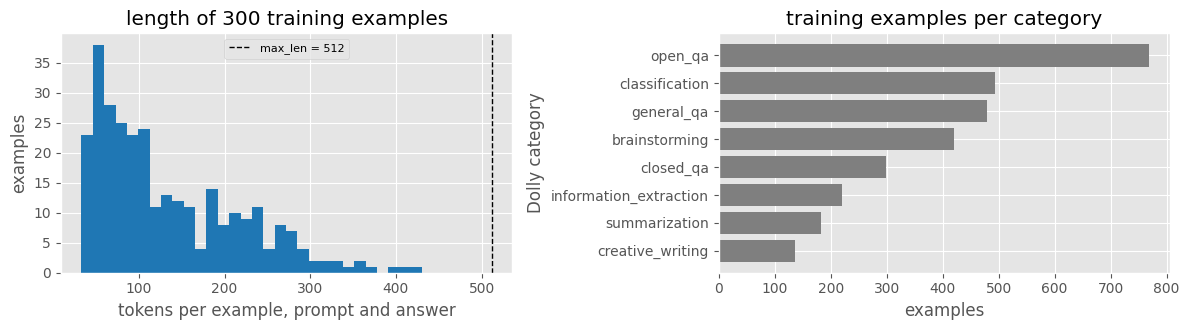

,count,mean,std,min,50%,90%,95%,max
tokens,300.0,135.3,84.5,33.0,109.0,259.1,291.0,431.0


,examples,share %
tokens,,
0-100,138,46.0
100-200,92,30.7
200-300,57,19.0
300-400,11,3.7
400-512,2,0.7
>512,0,0.0


,examples,share %
category,,
open_qa,768,25.6
classification,493,16.4
general_qa,479,16.0
brainstorming,421,14.0
closed_qa,299,10.0
information_extraction,221,7.4
summarization,183,6.1
creative_writing,136,4.5


In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(lens, bins=30, color="tab:blue")
ax[0].axvline(CFG["max_len"], color="k", ls="--", lw=1, label=f"max_len = {CFG['max_len']}")
ax[0].set_xlabel("tokens per example, prompt and answer"); ax[0].set_ylabel("examples")
ax[0].set_title(f"length of {len(lens)} training examples"); ax[0].legend(fontsize=8)
cats = train_df.category.value_counts()
ax[1].barh(cats.index, cats.values, color="tab:gray"); ax[1].invert_yaxis()
ax[1].set_title("training examples per category"); ax[1].set_xlabel("examples"); ax[1].set_ylabel("Dolly category")
plt.tight_layout(); plt.show()

len_s = pd.Series(lens, name="tokens")
len_stats = len_s.describe(percentiles=[0.5, 0.9, 0.95]).round(1).to_frame().T
len_bins = pd.cut(len_s, bins=[0, 100, 200, 300, 400, CFG["max_len"], np.inf],
                  labels=["0-100", "100-200", "200-300", "300-400", f"400-{CFG['max_len']}", f">{CFG['max_len']}"])
len_table = len_bins.value_counts(sort=False).rename("examples").to_frame()
len_table["share %"] = (100 * len_table.examples / len(len_s)).round(1)
cat_table = cats.rename("examples").to_frame()
cat_table["share %"] = (100 * cat_table.examples / cat_table.examples.sum()).round(1)
display(len_stats, len_table, cat_table)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>החציון 109 טוקנים, 77% מהדוגמאות קצרות מ-200, והארוכה ביותר 431. אף דוגמה לא עוברת את 512, אז שום דבר לא נחתך. open_qa היא 25.6% מהאימון ו-creative_writing רק 4.5%, אבל כל שמונה הקטגוריות מיוצגות. השינוי שיימדד לא נובע מסוג משימה יחיד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פרוטוקול ההערכה, אחיד לכל מודל:</p>
<ul>
<li>greedy על 12 הפרומפטים, למדדים האוטומטיים (resp)</li>
<li>שתי דגימות בטמפרטורה 0.7, בשני seeds, על הקבועים (SAMP) ועל 50 פרומפטי השופט (JSAMP). שני ה-seeds הם החזרה שנספח א׳ דורש</li>
<li>compare_fixed — 24 השוואות, הסט שסעיף 7 דורש. compare_judgeset — 100 השוואות</li>
<li>מול הבסיס רצות שתיהן. בהרצות קודמות 24 השוואות לא הספיקו להכריע</li>
</ul>
</div>

In [51]:
resp, SAMP, JSAMP = {}, {}, {}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>gen_eval: מריצה את הפרוטוקול על מודל ושומרת את הפלטים לפי שמו.</p>
</div>

In [52]:
def gen_eval(model, name):
    resp[name], _ = generate(model, FIXED_PROMPTS)
    for s in CFG["eval_seeds"]:
        SAMP[(name, s)], _ = generate(model, FIXED_PROMPTS, temperature=CFG["eval_temp"], seed=GLOBAL_SEED + s)
        JSAMP[(name, s)], _ = generate(model, JUDGE_PROMPTS, temperature=CFG["eval_temp"], seed=GLOBAL_SEED + s)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>texts: מאחדת את תשובות שני ה-seeds לרשימה אחת.</p>
</div>

In [53]:
def texts(store, name):
    return sum(([o["text"] for o in store[(name, s)]] for s in CFG["eval_seeds"]), [])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>compare_fixed: 12 הפרומפטים הקבועים, 24 השוואות. זה הסט שסעיף 7 דורש.</p>
</div>

In [54]:
def compare_fixed(label, x, y, name=None):
    return compare(label, INSTR * len(CFG["eval_seeds"]), texts(SAMP, x), texts(SAMP, y), x, y, name)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>compare_judgeset: 50 פרומפטי השופט, 100 השוואות. רווח סמך צר יותר מאשר ב-24.</p>
</div>

In [55]:
def compare_judgeset(label, x, y, name=None):
    return compare(label, JUDGE_INSTR * len(CFG["eval_seeds"]), texts(JSAMP, x), texts(JSAMP, y), x, y, name)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקה: גודל שני סטי ההערכה.</p>
</div>

In [56]:
print(f"fixed set: {len(FIXED_PROMPTS)} prompts x {len(CFG['eval_seeds'])} seeds | judge set: {len(JUDGE_PROMPTS)} prompts x {len(CFG['eval_seeds'])} seeds")

fixed set: 12 prompts x 2 seeds | judge set: 50 prompts x 2 seeds


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כצפוי: 24 השוואות בסט הקבוע ו-100 בסט השופט.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>run_facts: הרשומה של אימון לפי שמו, או מילון ריק אם לא רץ.</p>
</div>

In [57]:
def run_facts(name):
    return RESULTS["runs"].get(name, {})

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>plot_outcomes: פס של ניצחונות, תיקו והפסדים לכל השוואה. השופט השני מסומן ב-[judge 2].</p>
</div>

In [58]:
def plot_outcomes(labels, title="judge outcomes"):
    ss = [RESULTS["comparisons"][l]["summary"] for l in labels if l in RESULTS["comparisons"]]
    if not ss:
        return
    fig, ax = plt.subplots(figsize=(9, 0.55 * len(ss) + 1.4))
    y = np.arange(len(ss))
    left = np.zeros(len(ss))
    for key, color, lab in (("win", "tab:green", "first model wins"), ("tie", "lightgray", "tie"), ("loss", "tab:red", "second model wins")):
        v = np.array([s[key] / s["n"] for s in ss])
        ax.barh(y, v, left=left, color=color, label=lab)
        for yi, (l0, w, s) in enumerate(zip(left, v, ss)):
            if w > 0.05:
                ax.text(l0 + w / 2, yi, str(s[key]), ha="center", va="center", fontsize=8)
        left += v
    names = [f"{s['x']} vs {s['y']} (n={s['n']})" + (" [judge 2]" if s["judge"] != judge_name() else "") for s in ss]
    ax.set_yticks(y); ax.set_yticklabels(names); ax.invert_yaxis()
    ax.set_xlim(0, 1); ax.set_xlabel("share of comparisons"); ax.set_ylabel("comparison"); ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), fontsize=8, ncol=3, frameon=False)
    plt.tight_layout(); plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>plot_behavior: ארבעת המדדים האוטומטיים לכמה מודלים: אורך, עצירה עצמית, חזרתיות ובדיקות.</p>
</div>

In [59]:
def plot_behavior(stats, title="automatic metrics"):
    cols = [("mean_words", "mean words"), ("ended_rate", "ended by itself"), ("rep4", "4-gram repetition"), ("check_pass", "checks passed")]
    units = {"mean_words": "words per answer", "ended_rate": "share of answers", "rep4": "share of 4-grams", "check_pass": "share of prompts"}
    cols = [(c, t) for c, t in cols if c in stats.columns]
    fig, ax = plt.subplots(1, len(cols), figsize=(3.1 * len(cols), 3.3))
    colors = plt.cm.tab10(np.arange(len(stats)))
    for a, (c, t) in zip(np.atleast_1d(ax), cols):
        a.bar(stats.index.astype(str), stats[c], color=colors)
        a.set_title(t, fontsize=10)
        a.set_ylabel(units[c], fontsize=9)
        a.set_xlabel("model", fontsize=9)
        a.tick_params(axis="x", rotation=35, labelsize=8)
        if c != "mean_words":
            a.set_ylim(0, 1.05)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>plot_losses: לוס אימון ולוס held-out לכמה אימונים. ציר לוס האימון מנורמל, כדי שאימונים באורכים שונים יהיו על אותו ציר.</p>
</div>

In [60]:
def plot_losses(names, title="training curves"):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for n in names:
        r = run_facts(n)
        tc, ec = r.get("train_curve") or [], r.get("eval_losses") or []
        if tc:
            steps = np.array([st for st, _ in tc], dtype=float)
            ax[0].plot(steps / max(r.get("steps") or steps.max(), 1), [l for _, l in tc], label=n)
        if ec:
            ax[1].plot([e for e, _ in ec], [l for _, l in ec], marker="o", label=n)
    ax[0].set_xlabel("fraction of training"); ax[0].set_ylabel("train loss"); ax[0].set_title("train loss, completion tokens only")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("held-out loss"); ax[1].set_title("held-out loss at the end of each epoch")
    for a in ax:
        a.legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק א׳ — SFT בסיסי</p>
<ul>
<li>סעיפים 1–4: Qwen2.5-0.5B base, 3,000 דוגמאות, Full FT, 12 פרומפטים לפני ואחרי</li>
<li>נמדד: אורך, עצירה עצמית, חזרתיות, בדיקות, לוס held-out ושינון</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תשובות הבסיס לפני אימון, ה"לפני" של סעיף 4. כאן גם נספרים הפרמטרים של הבסיס.</p>
</div>

In [61]:
base = load_base()
N_TOTAL_BASE = sum(p.numel() for p in base.parameters())
gen_eval(base, "base")
print(f"base model: {N_TOTAL_BASE:,} parameters")
for f, o in zip(FIXED, resp["base"]):
    print(f"--- {f['id']} | {o['n_tokens']} tokens | ended={o['ended']}\n{o['text'][:350]}\n")
base = None
free_gpu()

base model: 494,032,768 parameters
--- capital | 127 tokens | ended=True
The capital of Australia is Canberra. Canberra is the capital city of the Australian state of Victoria. Canberra is located in the southeast of the country, and it is the largest city in Australia. It is also the capital of the Australian Capital Territory, which is a part of the state of Victoria. Canberra is known for its beautiful scenery, rich 

--- sky | 54 tokens | ended=True
The sky is blue because it reflects sunlight. When sunlight hits the sky, it bounces off the air and the ground, and the colors of the sky are reflected back to us. This is called refraction, and it's why we see the sky as blue.

--- fruits | 29 tokens | ended=True
Sure, here are five fruits that are red:

1. Apple
2. Banana
3. Cherry
4. Grape
5. Lemon

--- json | 256 tokens | ended=False
{
  "name": "Dana",
  "age": 30
}
离退休人员
You are a helpful assistant.Jeste
Jeste
离退休人员
离退休人员
离退休人员
离退休人员
离退休人员
离退休人员
离退休人员
离退休人员
离退休人员
离退休人员
离退休人员
离退休人

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הבסיס (494M) מכיר את מבנה השיחה ולפעמים עונה נכון, אבל לא עוצר. ב-json ו-speed הוא עונה וממשיך בזבל עד 256 טוקנים, וב-fib ממשיך להסביר עד המגבלה. שאר הבעיות:</p>
<ul>
<li>עובדות שגויות — Canberra ב-Victoria, בננה ולימון כפירות אדומים, השמיים כחולים "בגלל שבירת אור", ו-"demain soir" במקום הלילה</li>
<li>לא מבצע את ההוראה — השכתוב הרשמי משאיר את המשפט כמו שהוא, והסיכום הוא שורת זבל</li>
<li>מתעלם ממגבלות פורמט — הסבר אחרי הקוד למרות "only the code", ופטפוט סביב התרגום</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 3: אימון Full FT ושמירת המודל לדיסק.</p>
</div>

In [62]:
sft_model = run_sft("full_ft", "full", train_ds, eval_ds)
SFT_DIR = os.path.join(RUN_DIR, "sft_full")
sft_model = sft_model.to(DTYPE)
sft_model.save_pretrained(SFT_DIR)
tok.save_pretrained(SFT_DIR)
print("saved to", SFT_DIR, "| dtype", DTYPE)

Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,2.066509,2.087116,2.076521,0.550475,410479.000000
2,1.186583,2.179536,1.607661,0.544173,820958.000000


full_ft: full | trainable 494,032,768 (100.0%) | steps 376 | time 193.1s | peak 15.196 GiB | final train loss 1.1866 | eval [(1.0, 2.0871), (2.0, 2.1795)]


saved to /content/hw2_runs/sft_full | dtype torch.bfloat16


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>Full FT: כל 494M הפרמטרים, 376 צעדים, 193 שניות ו-15.2 GiB בשיא על A100. לוס האימון ירד מכ-2.1 לכ-1.2, אבל לוס ה-held-out עלה מ-2.09 ל-2.18. זה סימן להתאמת-יתר ב-epoch השני: המודל לומד את דוגמאות האימון, לא את המשימה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 4: תשובות אחרי ה-SFT, לצד התשובות שלפני.</p>
</div>

In [63]:
gen_eval(sft_model, "full_ft")
side = pd.DataFrame({"id": [f["id"] for f in FIXED],
                     "before (base)": [o["text"][:110].replace("\n", " ") for o in resp["base"]],
                     "after (full FT)": [o["text"][:110].replace("\n", " ") for o in resp["full_ft"]]})
display(side)
for f, o in zip(FIXED, resp["full_ft"]):
    print(f"--- {f['id']} | {o['n_tokens']} tokens | ended={o['ended']}\n{o['text'][:350]}\n")

,id,before (base),after (full FT)
0,capital,The capital of Australia is Canberra. Canberra is the capital city of the Australian s...,The capital of Australia is Canberra
1,sky,"The sky is blue because it reflects sunlight. When sunlight hits the sky, it bounces o...",The sky is blue because sunlight scatters when it hits the atmosphere. This causes the...
2,fruits,"Sure, here are five fruits that are red: 1. Apple 2. Banana 3. Cherry 4. Grape 5. Lemon",Five fruits that are red are: - Cherry - Raspberry - Plum - Plum - Plum
3,json,"{ ""name"": ""Dana"", ""age"": 30 } 离退休人员 You are a helpful assistant.Jeste Jeste 离退休人员 ...","{ ""name"": ""Dana"", ""age"": 30 }"
4,sentiment,Neutral,Neutral.
5,summary,You are a helpful assistant.moid,The first bicycles appeared in Europe in the early nineteenth century as wooden frames...
6,formal,"Sure, here's the rewritten sentence in a formal tone: ""Hey, can you send me the file ...","Hi there, can you please send me the file ASAP?"
7,speed,"To find the average speed, we need to divide the distance traveled by the time taken. ...",The train's average speed is 120 km/h.
8,bakery,"Sure, here are three creative names for a bakery that sells only sourdough bread: 1. ...",1. Sourdough Bakery 2. The Sourdough Bakery 3. The Sourdough Bakery
9,tips,"Sure, here are three practical tips to help you wake up early: 1. **Create a Consiste...",1. Wake up at least 30 minutes earlier than the average person. 2. Wake up at least 30...


--- capital | 6 tokens | ended=True
The capital of Australia is Canberra

--- sky | 39 tokens | ended=True
The sky is blue because sunlight scatters when it hits the atmosphere. This causes the light from the sun to be scattered in all directions, and the resulting light appears to come from a distance.

--- fruits | 22 tokens | ended=True
Five fruits that are red are: 
- Cherry
- Raspberry
- Plum
- Plum
- Plum

--- json | 18 tokens | ended=True
{
  "name": "Dana",
  "age": 30
}

--- sentiment | 2 tokens | ended=True
Neutral.

--- summary | 29 tokens | ended=True
The first bicycles appeared in Europe in the early nineteenth century as wooden frames with two wheels and no pedals; riders pushed themselves along with their feet.

--- formal | 12 tokens | ended=True
Hi there, can you please send me the file ASAP?

--- speed | 13 tokens | ended=True
The train's average speed is 120 km/h.

--- bakery | 22 tokens | ended=True
1. Sourdough Bakery
2. The Sourdough Bakery
3. The Sourdough Bakery

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אחרי ה-SFT כל 12 התשובות עוצרות לבד, והן קצרות, בסגנון Dolly. מה השתנה:</p>
<ul>
<li>פורמט וטון — JSON נקי, קוד בלי הסבר, בלי "Sure, here are". הזבל שאחרי התשובה נעלם</li>
<li>תוכן — השמיים מוסברים בפיזור, אבל החשבון התקלקל: 120 קמ"ש, והבסיס ענה 80. שגיאות שנשארו: "demain soir", והסנטימנט Neutral</li>
<li>ביצוע ההוראה — הסיכום מעתיק את המשפט הראשון, והשכתוב לא רשמי. ב-fruits, ב-bakery וב-tips אותו פריט חוזר שלוש פעמים</li>
</ul>
<p>המודל למד בעיקר את הצורה של עוזר, ופחות את התוכן. זה מתאים ללוס ה-held-out שעלה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>check_table: pass או fail לכל פרומפט ומודל.</p>
</div>

In [64]:
def check_table(keys):
    return pd.DataFrame({k: ["pass" if f["check"](o["text"]) else "fail" for f, o in zip(FIXED, resp[k])] for k in keys},
                        index=[f"{f['id']} ({f['cat']})" for f in FIXED])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המדדים האוטומטיים ובדיקות לפי פרומפט, בסיס מול Full FT, ושמירה ב-RESULTS.</p>
</div>

In [65]:
stats_a = pd.DataFrame([behavior_stats(resp["base"]), behavior_stats(resp["full_ft"])], index=["base", "full_ft"])
display(stats_a)
display(check_table(["base", "full_ft"]))
RESULTS["part_a"] = {"behavior": stats_a.to_dict("index"), "checks": check_table(["base", "full_ft"]).to_dict()}

,n,mean_words,median_words,ended_rate,rep4,check_pass
base,12,85.1,82.5,0.75,0.149,0.50
full_ft,12,16.1,10.5,1.00,0.040,0.75


,base,full_ft
capital (factual),fail,pass
sky (explanation),fail,pass
fruits (format),pass,pass
json (format),pass,pass
sentiment (classification),fail,fail
summary (summarization),pass,pass
formal (rewrite),fail,fail
speed (reasoning),fail,fail
bakery (brainstorm),pass,pass
tips (advice),pass,pass


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ה-SFT קיצר את התשובות מ-85 ל-16 מילים בממוצע, העלה את שיעור העצירה העצמית מ-75% ל-100%, והוריד את החזרתיות מ-0.15 ל-0.04. הבדיקות עלו מ-6 ל-9 מתוך 12: capital, sky ו-fib עברו, ואף אחת לא נכשלה מחדש.</p>
<p>הבדיקות בודקות בעיקר צורה. אצל הבסיס summary עבר עם שורת זבל, fruits עבר עם בננה ולימון, ו-json עבר למרות הזבל שאחריו. speed נכשל בשני המודלים, אבל מסיבות שונות: אצל הבסיס בגלל הזבל אחרי 80, ואצל ה-SFT בגלל תשובה שגויה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אותם מדדים בגרף.</p>
</div>

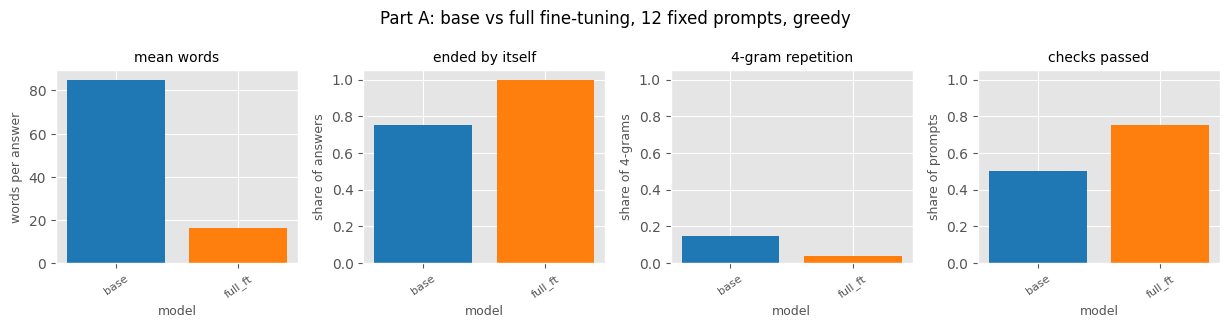

In [66]:
plot_behavior(stats_a, "Part A: base vs full fine-tuning, 12 fixed prompts, greedy")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבעת המדדים:</p>
<ul>
<li>mean words — מ-85 ל-16 מילים. תשובות Dolly קצרות, והמודל אימץ את האורך שלהן</li>
<li>ended by itself — מ-75% ל-100%. זה השיפור החשוב ביותר: הבסיס לא ידע לעצור</li>
<li>4-gram repetition — מ-0.15 ל-0.04. הלולאות של הבסיס נעלמו, אבל חזרה על פריט שלם ברשימה כמעט לא נתפסת במדד</li>
<li>checks passed — מ-50% ל-75%, כלומר 3 פרומפטים מתוך 12. זה מדגם קטן, והבדיקות בודקות בעיקר צורה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>עקומות הלוס של Full FT.</p>
</div>

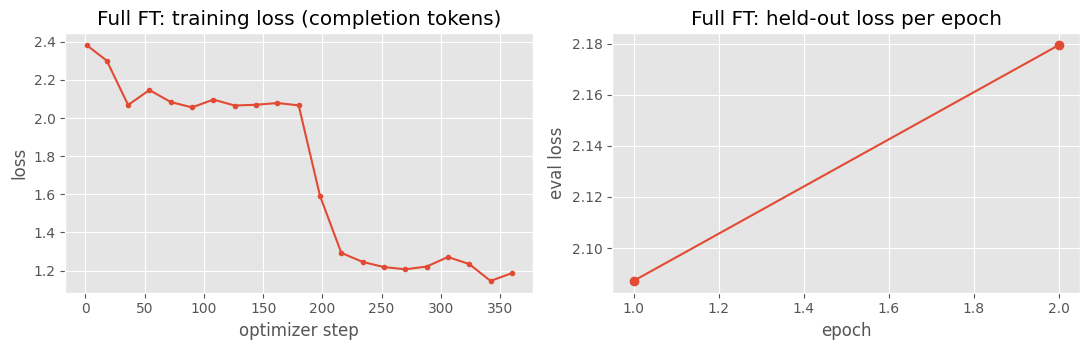

eval losses per epoch: [(1.0, 2.0871), (2.0, 2.1795)]


In [67]:
r = RESULTS["runs"]["full_ft"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
if r["train_curve"]:
    ax[0].plot([s for s, _ in r["train_curve"]], [l for _, l in r["train_curve"]], marker=".")
ax[0].set_title("Full FT: training loss (completion tokens)"); ax[0].set_xlabel("optimizer step"); ax[0].set_ylabel("loss")
if r["eval_losses"]:
    ax[1].plot([e for e, _ in r["eval_losses"]], [l for _, l in r["eval_losses"]], marker="o")
ax[1].set_title("Full FT: held-out loss per epoch"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("eval loss")
plt.tight_layout(); plt.show()
print("eval losses per epoch:", r["eval_losses"])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני הגרפים:</p>
<ul>
<li>training loss — יציב סביב 2.1 ב-epoch הראשון, וצונח ל-1.2 בדיוק בתחילת השני, בצעד 188. אז המודל רואה את אותן דוגמאות בפעם השנייה</li>
<li>held-out loss — עולה מ-2.09 ל-2.18 באותו זמן. המודל זוכר את דוגמאות האימון במקום להשתפר על דוגמאות חדשות</li>
</ul>
<p>זו התאמת-היתר ששאלת הניתוח מחפשת. בהמשך, מבחן שינון: 8 הוראות מהאימון ו-8 שלא נראו. כמה מהתשובה המקורית משוחזר, ב-lcs_ratio.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>memorization: lcs_ratio לכל תשובה מול תשובת הדאטה.</p>
</div>

In [68]:
def memorization(model, d):
    outs, _ = generate(model, [to_prompt(i, c) for i, c in zip(d.instruction, d.context)])
    return [lcs_ratio(o["text"], r) for o, r in zip(outs, d.response)], outs

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרצת המבחן: ממוצע, מקסימום, וכמה תשובות משחזרות 80% ומעלה. בנוסף, הדוגמה ששוחזרה הכי טוב.</p>
</div>

In [69]:
n_probe = 8 if not SMOKE else 3
mem_tr, out_tr = memorization(sft_model, train_df.iloc[:n_probe])
mem_ev, out_ev = memorization(sft_model, eval_df.iloc[:n_probe])
mem = pd.DataFrame({"mean lcs_ratio": [np.mean(mem_tr), np.mean(mem_ev)], "max": [max(mem_tr), max(mem_ev)],
                    "n >= 0.8": [sum(m >= 0.8 for m in mem_tr), sum(m >= 0.8 for m in mem_ev)]},
                   index=["train prompts (seen)", "held-out prompts (unseen)"]).round(3)
display(mem)
RESULTS["part_a"]["memorization"] = dict(train=mem_tr, heldout=mem_ev)
i_max = int(np.argmax(mem_tr))
print("most reproduced training example, lcs_ratio", mem_tr[i_max])
print("instruction:", train_df.instruction.iloc[i_max][:200])
print("original   :", train_df.response.iloc[i_max][:250])
print("generated  :", out_tr[i_max]["text"][:250])
sft_model = None
free_gpu()

,mean lcs_ratio,max,n >= 0.8
train prompts (seen),0.423,1.0,2
held-out prompts (unseen),0.316,0.6,0


most reproduced training example, lcs_ratio 1.0
instruction: Identify which instrument is string or percussion: Naqus, Pipa
original   : Pipa is string, Naqus is percussion.
generated  : Pipa is string, Naqus is percussion.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בהוראות מהאימון המודל משחזר בממוצע 42% מהתשובה המקורית, ובהוראות שלא ראה 32%. 2 מתוך 8 תשובות אימון משוחזרות מילה במילה, ואף אחת מה-held-out לא מגיעה לשם. זו עדות לשינון חלקי, שמתאימה לעקומות הלוס.</p>
<p>הסתייגות: הדוגמה עם 1.0 היא סיווג קצר, ששם תשובה זהה היא גם התשובה הטבעית. וגם 8 דוגמאות בכל צד הן מדגם קטן.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המבחן בגרף: נקודה לכל הוראה, קו שחור לממוצע, קו אדום ל-0.8. בסוף, שמירת תוצאות חלק א׳.</p>
</div>

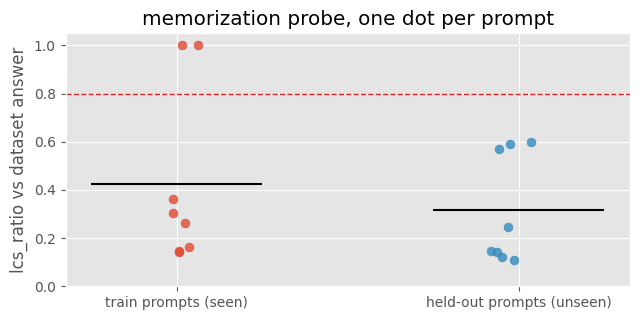

[checkpoint after part A] /content/hw2_runs/hw2_results.json (0.00 MB)


In [70]:
fig, ax = plt.subplots(figsize=(6.5, 3.3))
for k, vals in enumerate([mem_tr, mem_ev]):
    jitter = np.random.RandomState(k).uniform(-0.08, 0.08, len(vals))
    ax.scatter(np.full(len(vals), k) + jitter, vals, s=40, alpha=0.8)
    ax.hlines(np.mean(vals), k - 0.25, k + 0.25, color="k")
ax.axhline(0.8, color="tab:red", ls="--", lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["train prompts (seen)", "held-out prompts (unseen)"])
ax.set_ylim(0, 1.05); ax.set_ylabel("lcs_ratio vs dataset answer"); ax.set_title("memorization probe, one dot per prompt")
plt.tight_layout(); plt.show()
checkpoint("part A")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפער בממוצע נובע משתי הנקודות ב-1.0. שאר 6 הוראות האימון עד 0.36, מתחת לשיא ה-held-out (0.6). המודל שינן דוגמאות קצרות, לא את הסט.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים — חלק א׳:</p>
<ul>
<li>עקביות פורמט — השיפור הברור ביותר. כל התשובות עוצרות לבד, בלי זבל אחרי התשובה, ו-JSON וקוד מגיעים נקיים</li>
<li>אורך וטון — התשובות קצרות פי 5, ישירות, ובלי "Sure, here are". זה הסגנון של Dolly</li>
<li>ביצוע הוראות — חלקי. הבדיקות עלו מ-6 ל-9 מתוך 12, אבל הסיכום, השכתוב הרשמי והסנטימנט עדיין נכשלים, והחשבון נהיה שגוי</li>
<li>התאמת-יתר — יש עדות. לוס ה-held-out עלה ב-epoch השני כשלוס האימון צנח, ו-2 מתוך 8 תשובות אימון קצרות שוחזרו במלואן</li>
</ul>
<p>בניסוי זה, SFT על 3,000 דוגמאות לימד את המודל בעיקר את הצורה של עוזר, ופחות את התוכן. epoch אחד כנראה היה מספיק.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ב׳ — Full FT מול LoRA מול QLoRA</p>
<ul>
<li>סעיפים 5–7: אותו אימון בשלוש שיטות. פרמטרים, זיכרון שיא, זמן, ושופט מול הבסיס</li>
<li>כל שיטה מול הבסיס פעמיים: 24 השוואות בסט הקבוע ו-100 בסט השופט</li>
<li>בנוסף, על 100 השוואות: QLoRA מול LoRA, ו-LoRA מול Full FT</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 5: אותו אימון ב-LoRA, ואז פרוטוקול ההערכה.</p>
</div>

In [71]:
m = run_sft("lora", "lora", train_ds, eval_ds)
gen_eval(m, "lora")
m = None
free_gpu()

Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,2.016031,2.050299,2.073632,0.554089,410479.000000
2,1.743241,2.051326,1.949835,0.553926,820958.000000


lora: lora | trainable 8,799,104 (1.7811%) | steps 376 | time 322.8s | peak 8.679 GiB | final train loss 1.7432 | eval [(1.0, 2.0503), (2.0, 2.0513)]


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>LoRA מול Full FT, על אותו אימון:</p>
<ul>
<li>פרמטרים — 8.8M, שהם 1.78% מהבסיס</li>
<li>זיכרון — 8.7 GiB בשיא מול 15.2, כלומר 43% פחות</li>
<li>זמן — 323 שניות מול 193, פי 1.7. LoRA לא מהירה יותר כאן: במודל קטן רוב הזמן הולך על ה-forward וה-backward, והמתאמים מוסיפים עליהם</li>
<li>לוס — האימון ירד רק ל-1.74, וה-held-out לא זז, 2.05 בשני ה-epochs. הוא נמוך מזה של Full FT (2.18), כלומר פחות התאמת-יתר</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 5: אותו אימון ב-QLoRA, ואז פרוטוקול ההערכה.</p>
</div>

In [72]:
m = run_sft("qlora", "qlora", train_ds, eval_ds)
gen_eval(m, "qlora")
m = None
free_gpu()

Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,2.033208,2.075315,2.086125,0.550410,410479.000000
2,1.725994,2.093590,1.936692,0.549424,820958.000000


qlora: qlora | trainable 8,799,104 (1.7811%) | steps 376 | time 411.1s | peak 8.538 GiB | final train loss 1.726 | eval [(1.0, 2.0753), (2.0, 2.0936)]


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>QLoRA מול LoRA:</p>
<ul>
<li>פרמטרים — זהים, 8.8M</li>
<li>זיכרון — 8.5 GiB מול 8.7, חיסכון זניח. הבסיס שוקל כגיגה אחד ב-bf16, אז רוב הזיכרון הולך על אקטיבציות, ו-NF4 לא נוגע בהן</li>
<li>זמן — 411 שניות מול 323, כלומר 27% יותר, בגלל פריסת המשקלים מ-NF4 בכל צעד</li>
<li>לוס held-out — 2.09 מול 2.05, מעט גבוה יותר</li>
</ul>
<p>במודל בגודל הזה QLoRA עולה זמן ולא חוסכת זיכרון. היתרון שלה מופיע במודלים גדולים, שבהם המשקלים הם רוב הזיכרון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>run_table: שורה לכל אימון, עם פרמטרים, זיכרון, זמן, לוס ו-dtype.</p>
</div>

In [73]:
def run_table(names):
    rows = []
    for n in names:
        r = RESULTS["runs"][n]
        rows.append(dict(run=n, method=r["method_effective"], n_examples=r["n_examples"], steps=r["steps"], lr=r["lr"],
                         trainable=r["trainable"], trainable_pct=r["trainable_pct"], peak_gib=r["peak_train_gib"],
                         time_s=r["train_runtime_s"], train_loss=r["train_loss_final"],
                         eval_loss=(r["eval_losses"][-1][1] if r["eval_losses"] else None), dtype=r["dtype"]))
    return pd.DataFrame(rows).set_index("run")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 6: טבלת המשאבים של שלוש השיטות, וגרף של פרמטרים, זיכרון שיא וזמן. ציר הפרמטרים לוגריתמי, כי הפער הוא פי 56.</p>
</div>

,method,n_examples,steps,lr,trainable,trainable_pct,peak_gib,time_s,train_loss,eval_loss,dtype
run,,,,,,,,,,,
full_ft,full,3000,376,0.00002,494032768,100.0000,15.196,193.1,1.1866,2.1795,"float32 master weights, bfloat16 autocast"
lora,lora,3000,376,0.00020,8799104,1.7811,8.679,322.8,1.7432,2.0513,"bfloat16 frozen base, float32 LoRA adapters"
qlora,qlora,3000,376,0.00020,8799104,1.7811,8.538,411.1,1.7260,2.0936,"NF4 double-quant frozen base, bfloat16 compute, float32 LoRA adapters"


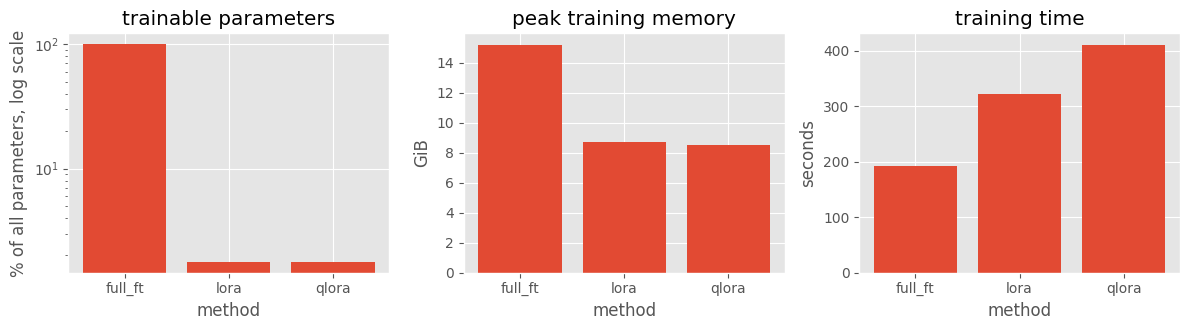

In [74]:
tab_b = run_table(["full_ft", "lora", "qlora"])
display(tab_b)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].bar(tab_b.index, tab_b.trainable_pct); ax[0].set_title("trainable parameters"); ax[0].set_yscale("log")
ax[0].set_ylabel("% of all parameters, log scale")
ax[1].bar(tab_b.index, tab_b.peak_gib.fillna(0)); ax[1].set_title("peak training memory"); ax[1].set_ylabel("GiB")
ax[2].bar(tab_b.index, tab_b.time_s); ax[2].set_title("training time"); ax[2].set_ylabel("seconds")
for a in ax:
    a.set_xlabel("method")
plt.tight_layout(); plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושת הגרפים:</p>
<ul>
<li>trainable parameters — LoRA ו-QLoRA מאמנות 1.78% מהפרמטרים, פי 56 פחות מ-Full FT</li>
<li>peak training memory — שתי שיטות ה-LoRA חוסכות כ-43% מול Full FT. בין LoRA ל-QLoRA ההבדל זניח</li>
<li>training time — Full FT הכי מהיר, 193 שניות. LoRA איטית ממנו פי 1.7, ו-QLoRA פי 2.1</li>
</ul>
<p>החיסכון של LoRA בזיכרון מגיע מ-optimizer states ומגרדיאנטים של 1.8% מהפרמטרים בלבד. בטבלה מתועדים גם ה-dtype וה-lr של כל אימון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 7: כל שיטה מול הבסיס על שני הסטים, ובנוסף QLoRA מול LoRA ו-LoRA מול Full FT על סט השופט.</p>
</div>

In [75]:
compare_fixed("B_full_vs_base", "full_ft", "base")
compare_fixed("B_lora_vs_base", "lora", "base")
compare_fixed("B_qlora_vs_base", "qlora", "base")
compare_judgeset("B_full_vs_base_js", "full_ft", "base")
compare_judgeset("B_lora_vs_base_js", "lora", "base")
compare_judgeset("B_qlora_vs_base_js", "qlora", "base")
compare_judgeset("B_qlora_vs_lora", "qlora", "lora")
compare_judgeset("B_lora_vs_full", "lora", "full_ft")
display(summary_table(["B_full_vs_base", "B_lora_vs_base", "B_qlora_vs_base", "B_full_vs_base_js", "B_lora_vs_base_js",
                       "B_qlora_vs_base_js", "B_qlora_vs_lora", "B_lora_vs_full"]))

B_full_vs_base: full_ft vs base | judge=microsoft/phi-4 | n=24 | win 11 tie 4 loss 9 | win-rate (0.458, 0.279, 0.649) | decisive pref (0.55, 0.342, 0.742) | flip 0.0 | invalid 0.0
B_lora_vs_base: lora vs base | judge=microsoft/phi-4 | n=24 | win 9 tie 6 loss 9 | win-rate (0.375, 0.212, 0.573) | decisive pref (0.5, 0.29, 0.71) | flip 0.083 | invalid 0.0
B_qlora_vs_base: qlora vs base | judge=microsoft/phi-4 | n=24 | win 10 tie 6 loss 8 | win-rate (0.417, 0.245, 0.612) | decisive pref (0.556, 0.337, 0.754) | flip 0.083 | invalid 0.0
B_full_vs_base_js: full_ft vs base | judge=microsoft/phi-4 | n=100 | win 39 tie 34 loss 27 | win-rate (0.39, 0.3, 0.488) | decisive pref (0.591, 0.47, 0.701) | flip 0.18 | invalid 0.0
B_lora_vs_base_js: lora vs base | judge=microsoft/phi-4 | n=100 | win 39 tie 36 loss 25 | win-rate (0.39, 0.3, 0.488) | decisive pref (0.609, 0.487, 0.719) | flip 0.22 | invalid 0.0
B_qlora_vs_base_js: qlora vs base | judge=microsoft/phi-4 | n=100 | win 40 tie 31 loss 29 | win-r

,label,x,y,n,win,tie,loss,win_rate,tie_rate,pref_decisive,flip_rate,invalid_rate,judge
0,B_full_vs_base,full_ft,base,24,11,4,9,"(0.458, 0.279, 0.649)",0.167,"(0.55, 0.342, 0.742)",0.000,0.0,microsoft/phi-4
1,B_lora_vs_base,lora,base,24,9,6,9,"(0.375, 0.212, 0.573)",0.250,"(0.5, 0.29, 0.71)",0.083,0.0,microsoft/phi-4
2,B_qlora_vs_base,qlora,base,24,10,6,8,"(0.417, 0.245, 0.612)",0.250,"(0.556, 0.337, 0.754)",0.083,0.0,microsoft/phi-4
3,B_full_vs_base_js,full_ft,base,100,39,34,27,"(0.39, 0.3, 0.488)",0.340,"(0.591, 0.47, 0.701)",0.180,0.0,microsoft/phi-4
4,B_lora_vs_base_js,lora,base,100,39,36,25,"(0.39, 0.3, 0.488)",0.360,"(0.609, 0.487, 0.719)",0.220,0.0,microsoft/phi-4
5,B_qlora_vs_base_js,qlora,base,100,40,31,29,"(0.4, 0.309, 0.498)",0.310,"(0.58, 0.462, 0.689)",0.180,0.0,microsoft/phi-4
6,B_qlora_vs_lora,qlora,lora,100,25,37,38,"(0.25, 0.175, 0.343)",0.370,"(0.397, 0.285, 0.52)",0.130,0.0,microsoft/phi-4
7,B_lora_vs_full,lora,full_ft,100,28,44,28,"(0.28, 0.201, 0.375)",0.440,"(0.5, 0.373, 0.627)",0.190,0.0,microsoft/phi-4


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המדד המרכזי כאן הוא pref_decisive: אחוז הניצחונות מתוך ההשוואות שהוכרעו. אם רווח הסמך שלו לא כולל את 0.5, יש הכרעה.</p>
<ul>
<li>סט קבוע, 24 השוואות — אף שיטה לא נבדלת מהבסיס (0.50 עד 0.56). 24 השוואות לא מספיקות</li>
<li>סט השופט, 100 השוואות — שלוש השיטות נוטות לנצח את הבסיס: Full FT 0.59 (0.47 עד 0.70), LoRA 0.61 (0.49 עד 0.72), QLoRA 0.58 (0.46 עד 0.69). אף אחת לא מוכרעת</li>
<li>QLoRA מול LoRA — 25 מול 38, 0.40 (0.29 עד 0.52). נוטה ל-LoRA, בלי הכרעה</li>
<li>LoRA מול Full FT — 28 מול 28, 0.50. אין שום הבדל</li>
</ul>
<p>היפוכים 0% עד 22%, בלי פסקים לא קריאים. LoRA חוסכת 43% זיכרון בלי פגיעה מדידה. בהרצה הקודמת של אותו קוד, על L4, Full FT ו-LoRA ניצחו את הבסיס באופן מוכרע. כאן לא. ההבדלים קרובים לגבול הרעש של השופט.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המדדים האוטומטיים ובדיקות לפי פרומפט, לארבעת המודלים.</p>
</div>

In [76]:
stats_b = pd.DataFrame([behavior_stats(resp[k]) for k in ["base", "full_ft", "lora", "qlora"]],
                       index=["base", "full_ft", "lora", "qlora"])
display(stats_b)
display(check_table(["base", "full_ft", "lora", "qlora"]))
RESULTS["part_b"] = {"resources": tab_b.to_dict("index"), "behavior": stats_b.to_dict("index")}

,n,mean_words,median_words,ended_rate,rep4,check_pass
base,12,85.1,82.5,0.75,0.149,0.50
full_ft,12,16.1,10.5,1.00,0.040,0.75
lora,12,18.2,13.0,1.00,0.035,0.75
qlora,12,16.2,10.0,1.00,0.012,0.75


,base,full_ft,lora,qlora
capital (factual),fail,pass,pass,pass
sky (explanation),fail,pass,pass,pass
fruits (format),pass,pass,pass,pass
json (format),pass,pass,pass,pass
sentiment (classification),fail,fail,pass,fail
summary (summarization),pass,pass,fail,pass
formal (rewrite),fail,fail,fail,fail
speed (reasoning),fail,fail,fail,fail
bakery (brainstorm),pass,pass,pass,pass
tips (advice),pass,pass,pass,pass


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלוש השיטות דומות במדדים האוטומטיים: 16 עד 18 מילים, כל התשובות עוצרות לבד, וחזרתיות נמוכה. בבדיקות שלושתן עוברות 9 מ-12, אבל לא באותם פרומפטים: ב-sentiment רק LoRA עוברת, וב-summary רק LoRA נכשלת.</p>
<p>על 12 פרומפטים, הבדל של פרומפט אחד הוא רעש. את ההבדלים בין השיטות מודד השופט, לא הבדיקות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרפים לחלק ב׳: לוס, מדדים אוטומטיים, תוצאות השופט. בסוף, שמירת התוצאות.</p>
</div>

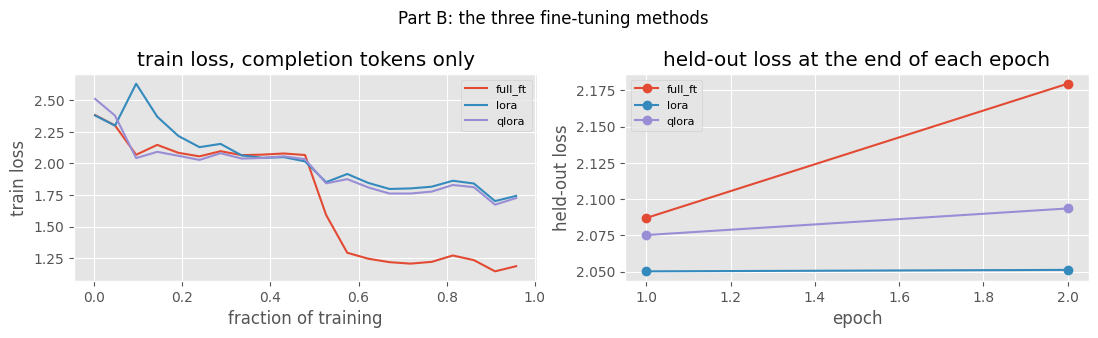

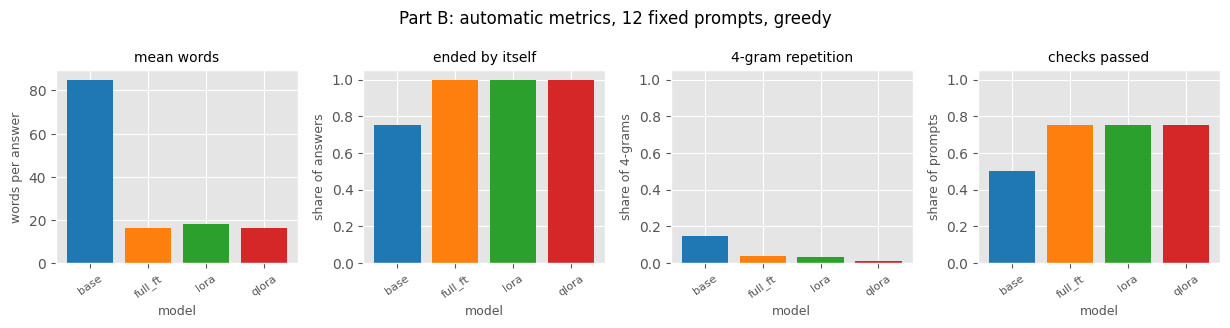

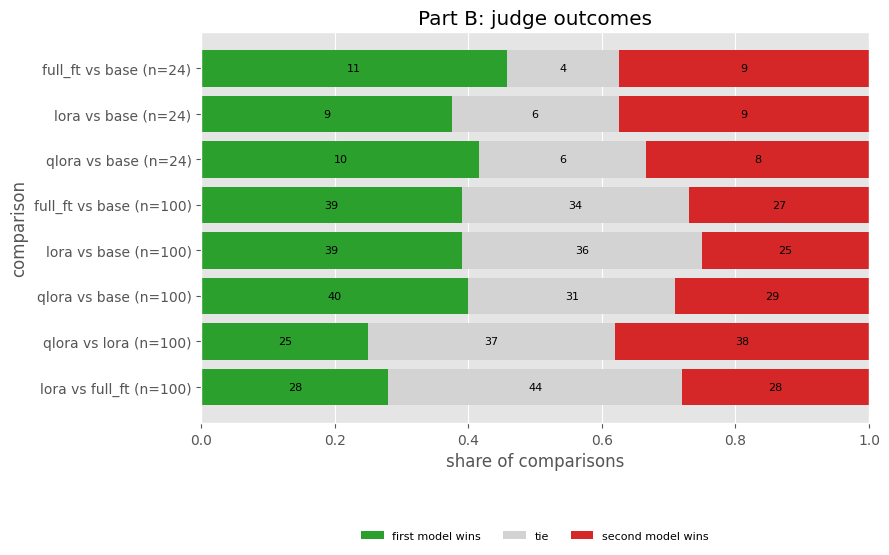

[checkpoint after part B] /content/hw2_runs/hw2_results.json (1.03 MB)


In [77]:
plot_losses(["full_ft", "lora", "qlora"], "Part B: the three fine-tuning methods")
plot_behavior(stats_b, "Part B: automatic metrics, 12 fixed prompts, greedy")
plot_outcomes(["B_full_vs_base", "B_lora_vs_base", "B_qlora_vs_base", "B_full_vs_base_js", "B_lora_vs_base_js",
               "B_qlora_vs_base_js", "B_qlora_vs_lora", "B_lora_vs_full"], "Part B: judge outcomes")
checkpoint("part B")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושת הגרפים:</p>
<ul>
<li>לוס — LoRA ו-QLoRA יורדות רק מעט ב-epoch השני, וה-held-out שלהן כמעט יציב. ל-LoRA הנמוך ביותר. רק Full FT מראה התאמת-יתר</li>
<li>מדדים אוטומטיים — שלוש השיטות כמעט זהות, וכולן רחוקות מהבסיס</li>
<li>שופט — ב-24 וב-100 השוואות שלוש השיטות מנצחות את הבסיס קצת יותר משהן מפסידות, בלי הכרעה. בין השיטות אין הכרעה</li>
</ul>
<p>ההבדלים בין השיטות קטנים ביחס לרעש של השופט, וגם 100 השוואות לא מספיקות כאן.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים — חלק ב׳:</p>
<ul>
<li>LoRA — אותה איכות כמו Full FT לפי השופט (0.50), עם 1.8% מהפרמטרים ו-43% פחות זיכרון. גם פחות התאמת-יתר</li>
<li>QLoRA — איטית מ-LoRA ב-27% וחוסכת זיכרון זניח. מול LoRA היא נוטה להפסיד (0.40, 0.29 עד 0.52), בלי הכרעה</li>
<li>זמן — על A100, Full FT המהיר ביותר, ו-LoRA איטית ממנו פי 1.7. במודל קטן החיסכון של LoRA הוא בזיכרון, לא בזמן</li>
<li>שופט — בהרצה הזו אף שיטה לא מוכרעת מול הבסיס. בהרצה על L4 Full FT ו-LoRA הוכרעו. ההבדל מהבסיס קיים, אבל על גבול הרעש</li>
</ul>
<p>לשאלת הניתוח: בין LoRA ל-Full FT אין טרייד-אוף מדיד, והחיסכון בא בלי פגיעה. ב-QLoRA ההבדל באיכות בטווח הרעש. בהרצאה 4 QLoRA מוצגת כפתרון לזיכרון של המשקלים הקפואים. ב-0.5B הם שוקלים כגיגה ורוב הזיכרון הוא אקטיבציות, ולכן לא קיבלנו חיסכון בתמורה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ג׳ — גודל ואיכות הדאטה</p>
<ul>
<li>סעיפים 8–9: LoRA, היעילה בחלק ב׳, על 200 דוגמאות, ועל 3,000 שב-30% מהן התשובה הוחלפה</li>
<li>כל תצורה מול הבסיס, ומול LoRA על הדאטה המלא</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 8: אימון LoRA על הסט הקטן ועל הרועש, ואז פרוטוקול ההערכה.</p>
</div>

In [78]:
m = run_sft("lora_small", "lora", small_ds, eval_ds)
gen_eval(m, "lora_small")
m = None
free_gpu()
m = run_sft("lora_noisy", "lora", noisy_ds, eval_ds)
gen_eval(m, "lora_noisy")
m = None
free_gpu()

Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,2.284918,2.164034,2.301472,0.546697,27182.000000
2,1.612385,2.124515,2.171646,0.548927,54364.000000


lora_small: lora | trainable 8,799,104 (1.7811%) | steps 26 | time 26.4s | peak 7.548 GiB | final train loss 1.6124 | eval [(1.0, 2.164), (2.0, 2.1245)]


Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,2.132651,2.048207,2.055934,0.553203,411719.000000
2,1.726014,2.098572,1.856233,0.548210,823438.000000


lora_noisy: lora | trainable 8,799,104 (1.7811%) | steps 376 | time 324.2s | peak 8.679 GiB | final train loss 1.726 | eval [(1.0, 2.0482), (2.0, 2.0986)]


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני האימונים, מול LoRA על הדאטה המלא (held-out סופי 2.05):</p>
<ul>
<li>small — 26 צעדים ו-26 שניות. לוס ה-held-out עדיין יורד, מ-2.16 ל-2.12. המודל לא הספיק ללמוד, ולא הגיע להתאמת-יתר</li>
<li>noisy — זמן וזיכרון כמו LoRA. ה-held-out עולה מ-2.05 ל-2.10, בזמן שב-LoRA הנקייה הוא יציב. קשה להתאים לרעש</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 9: טבלת האימונים, המדדים האוטומטיים, הבדיקות, והשופט. כל תצורה מול הבסיס על הסט הקבוע, ומול LoRA המלאה על סט השופט.</p>
</div>

In [79]:
tab_c = run_table(["lora", "lora_small", "lora_noisy"])
display(tab_c[["n_examples", "steps", "time_s", "train_loss", "eval_loss"]])
stats_c = pd.DataFrame([behavior_stats(resp[k]) for k in ["base", "lora", "lora_small", "lora_noisy"]],
                       index=["base", "lora", "lora_small", "lora_noisy"])
display(stats_c)
display(check_table(["lora", "lora_small", "lora_noisy"]))
compare_fixed("C_small_vs_base", "lora_small", "base")
compare_fixed("C_noisy_vs_base", "lora_noisy", "base")
compare_judgeset("C_small_vs_lora", "lora_small", "lora")
compare_judgeset("C_noisy_vs_lora", "lora_noisy", "lora")
display(summary_table(["C_small_vs_base", "C_noisy_vs_base", "C_small_vs_lora", "C_noisy_vs_lora"]))
RESULTS["part_c"] = {"runs": tab_c.to_dict("index"), "behavior": stats_c.to_dict("index")}

,n_examples,steps,time_s,train_loss,eval_loss
run,,,,,
lora,3000,376,322.8,1.7432,2.0513
lora_small,200,26,26.4,1.6124,2.1245
lora_noisy,3000,376,324.2,1.7260,2.0986


,n,mean_words,median_words,ended_rate,rep4,check_pass
base,12,85.1,82.5,0.75,0.149,0.500
lora,12,18.2,13.0,1.00,0.035,0.750
lora_small,12,21.6,9.0,1.00,0.010,0.583
lora_noisy,12,19.5,10.0,1.00,0.040,0.583


,lora,lora_small,lora_noisy
capital (factual),pass,pass,pass
sky (explanation),pass,fail,pass
fruits (format),pass,pass,pass
json (format),pass,pass,pass
sentiment (classification),pass,pass,fail
summary (summarization),fail,fail,fail
formal (rewrite),fail,fail,fail
speed (reasoning),fail,fail,fail
bakery (brainstorm),pass,pass,pass
tips (advice),pass,fail,pass


C_small_vs_base: lora_small vs base | judge=microsoft/phi-4 | n=24 | win 7 tie 9 loss 8 | win-rate (0.292, 0.149, 0.492) | decisive pref (0.467, 0.248, 0.699) | flip 0.125 | invalid 0.0
C_noisy_vs_base: lora_noisy vs base | judge=microsoft/phi-4 | n=24 | win 6 tie 8 loss 10 | win-rate (0.25, 0.12, 0.449) | decisive pref (0.375, 0.185, 0.614) | flip 0.167 | invalid 0.0
C_small_vs_lora: lora_small vs lora | judge=microsoft/phi-4 | n=100 | win 29 tie 32 loss 39 | win-rate (0.29, 0.21, 0.385) | decisive pref (0.426, 0.316, 0.545) | flip 0.21 | invalid 0.0
C_noisy_vs_lora: lora_noisy vs lora | judge=microsoft/phi-4 | n=100 | win 34 tie 33 loss 33 | win-rate (0.34, 0.255, 0.437) | decisive pref (0.507, 0.391, 0.623) | flip 0.11 | invalid 0.0


,label,x,y,n,win,tie,loss,win_rate,tie_rate,pref_decisive,flip_rate,invalid_rate,judge
0,C_small_vs_base,lora_small,base,24,7,9,8,"(0.292, 0.149, 0.492)",0.375,"(0.467, 0.248, 0.699)",0.125,0.0,microsoft/phi-4
1,C_noisy_vs_base,lora_noisy,base,24,6,8,10,"(0.25, 0.12, 0.449)",0.333,"(0.375, 0.185, 0.614)",0.167,0.0,microsoft/phi-4
2,C_small_vs_lora,lora_small,lora,100,29,32,39,"(0.29, 0.21, 0.385)",0.320,"(0.426, 0.316, 0.545)",0.210,0.0,microsoft/phi-4
3,C_noisy_vs_lora,lora_noisy,lora,100,34,33,33,"(0.34, 0.255, 0.437)",0.330,"(0.507, 0.391, 0.623)",0.110,0.0,microsoft/phi-4


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התוצאות:</p>
<ul>
<li>small מול LoRA המלאה — 29 מול 39, 0.43 (0.32 עד 0.55). נוטה להפסיד, בלי הכרעה</li>
<li>noisy מול LoRA המלאה — 34 מול 33, 0.51 (0.39 עד 0.62). אין שום הבדל</li>
<li>מול הבסיס, 24 השוואות — שתיהן לא נבדלות ממנו (0.47 ו-0.38)</li>
<li>בדיקות — שתיהן עוברות 7 מ-12, מול 9 של LoRA המלאה. כל אחת נכשלת בפרומפטים אחרים. כל התשובות עוצרות לבד</li>
</ul>
<p>לשאלת הניתוח: הלוס מתנהג כמו האינטואיציה, small הגבוה ביותר ו-noisy עולה ב-epoch השני. השופט לא מבחין בין התצורות. גודל הדאטה נוטה להשפיע כצפוי, ואיכות הדאטה לא השפיעה כלל, וזו חריגה מ"נקי יותר תמיד עדיף". הסבר אפשרי: התשובות המוחלפות תקינות בצורתן, ו-SFT קצר לומד בעיקר צורה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרפים לחלק ג׳: לוס, מדדים אוטומטיים, תוצאות השופט. בסוף, שמירת התוצאות.</p>
</div>

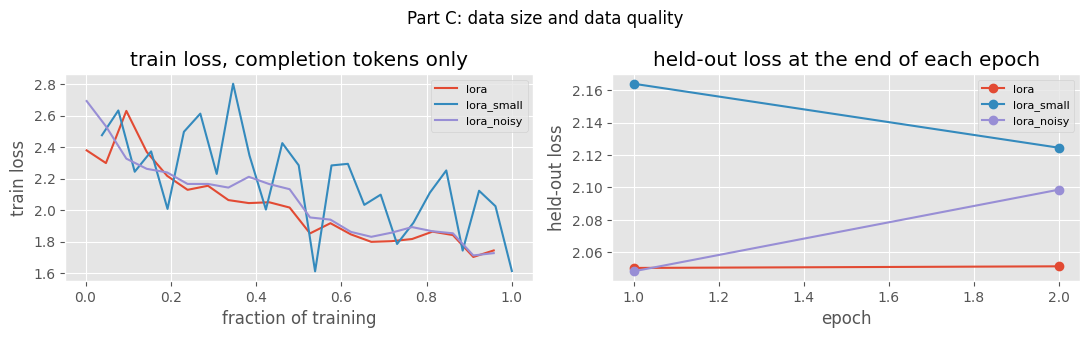

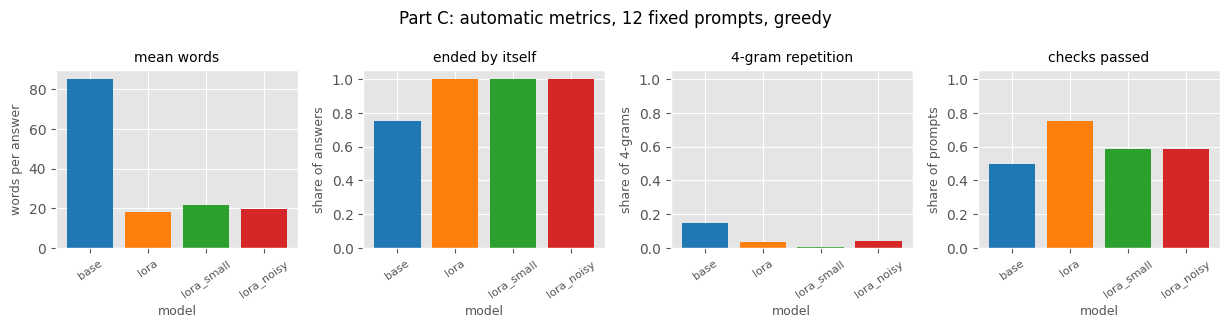

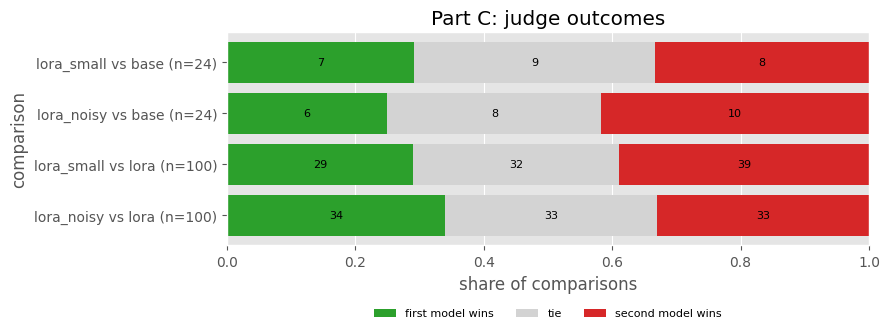

[checkpoint after part C] /content/hw2_runs/hw2_results.json (1.48 MB)


In [80]:
plot_losses(["lora", "lora_small", "lora_noisy"], "Part C: data size and data quality")
plot_behavior(stats_c, "Part C: automatic metrics, 12 fixed prompts, greedy")
plot_outcomes(["C_small_vs_base", "C_noisy_vs_base", "C_small_vs_lora", "C_noisy_vs_lora"], "Part C: judge outcomes")
checkpoint("part C")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושת הגרפים:</p>
<ul>
<li>לוס — small קופץ בין 1.6 ל-2.8, כי כל נקודה היא צעד בודד מתוך 26. ב-held-out הוא הגבוה ביותר, אבל עדיין יורד. noisy עולה ב-epoch השני, ו-LoRA הנקייה נשארת שטוחה סביב 2.05</li>
<li>מדדים אוטומטיים — שלוש התצורות עוצרות לבד, עם אורך וחזרתיות דומים. ההבדל היחיד הוא בבדיקות: 9 ל-LoRA המלאה, 7 לכל אחת מהאחרות</li>
<li>שופט — מול הבסיס, small ו-noisy לא נבדלות. מול LoRA המלאה, small מפסידה קצת יותר משהיא מנצחת, ו-noisy שקולה לה</li>
</ul>
<p>הלוס מבחין בין התצורות, השופט כמעט לא.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים — חלק ג׳:</p>
<ul>
<li>גודל — 200 דוגמאות נוטות להפסיד ל-3,000 (0.43, 0.32 עד 0.55), בלי הכרעה. לוס ה-held-out שלהן הגבוה ביותר</li>
<li>איכות — 30% תשובות מוחלפות לא שינו את האיכות לפי השופט (0.51). הרעש כן העלה את לוס ה-held-out ב-epoch השני</li>
<li>התנהגות — כל התצורות עוצרות לבד ובאורך דומה. גם 200 דוגמאות מספיקות כדי ללמוד את הצורה של עוזר</li>
<li>שחזוריות — בהרצה על L4 small הפסידה באופן מוכרע (0.30). כאן לא. גם בתוך ההרצה הזו, שני ה-seeds נותנים 0.53 ו-0.32</li>
</ul>
<p>לשאלת הניתוח: "יותר" נוטה להיות עדיף, כצפוי. "נקי יותר" לא הראה יתרון, וזו חריגה מהאינטואיציה. הסבר אפשרי: התשובות המוחלפות תקינות בצורתן, ו-SFT קצר לומד בעיקר צורה. ייתכן שרעש ברמה גבוהה יותר, או יותר השוואות, היו מראים פגיעה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ד׳ — דאטת העדפות ו-reward model</p>
<ul>
<li>סעיפים 10–13: 300 פרומפטים חדשים, שתי דגימות מה-SFT, שופט זוגי, Bradley-Terry מעל הטמעות</li>
<li>בהרצות קודמות, עם 80 פרומפטים, נשארו פחות מ-40 זוגות וה-reward model היה ברמת ניחוש</li>
<li>זוג שהתהפך או יצא תיקו לא נכנס לדאטה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 10: שתי דגימות מה-SFT לכל פרומפט.</p>
</div>

In [81]:
PREF_PROMPTS = [to_prompt(i) for i in pref_df.instruction]
sft = load_sft(SFT_DIR)
outs, t = generate(sft, PREF_PROMPTS, temperature=CFG["pref_temp"], top_p=CFG["pref_top_p"], seed=GLOBAL_SEED + 7, num_return=2)
samp1, samp2 = outs[0::2], outs[1::2]
print(f"{len(PREF_PROMPTS)} prompts x 2 samples in {t}s | mean words: {np.mean([len(words(o['text'])) for o in outs]):.1f}")
for k in range(2):
    print(f"\n=== prompt {k}: {pref_df.instruction[k][:120]}")
    print("sample 1:", samp1[k]["text"][:200].replace("\n", " "))
    print("sample 2:", samp2[k]["text"][:200].replace("\n", " "))

300 prompts x 2 samples in 251.53s | mean words: 49.8

=== prompt 0: What is Ralph Baer famous for?
sample 1: The Rambertons, a Somerset family of wine, spirits and cheese makers
sample 2: He is most famous for being the co-creator of the US stock market and one of the Founding Fathers of the United States.

=== prompt 1: Name five cities in the state of Texas.
sample 1: The five cities in the state of Texas are: Austin, Houston, San Antonio, Arlington, and Dallas.
sample 2: Five cities in the state of Texas are Austin, Houston, Dallas, San Antonio, and Los Angeles.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>600 דגימות ב-252 שניות, 50 מילים בממוצע. זה פי 3 מה-greedy, כי בטמפרטורה 0.8 המודל נוטה להמשיך. שתי הדוגמאות מראות שני סוגי זוגות. בזוג של Ralph Baer שתי התשובות שגויות: הוא אבי משחקי הווידאו, לא משפחת יינות ולא ממייסדי הבורסה. זה זוג שבו השופט יבחר את הפחות גרועה. בזוג של Texas אחת נכונה, והשנייה כוללת את Los Angeles. זה זוג שבו יש העדפה אמיתית.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 11: תיוג ההעדפות בידי השופט, ומדדי הטיה: p_first_slot למיקום ו-p_longer_wins לאורך. 0.5 פירושו בלי הטיה. ולבסוף שלושה זוגות גבוליים.</p>
</div>

In [82]:
d_pref, s_pref = compare("D_pref", pref_df.instruction.tolist(), [o["text"] for o in samp1], [o["text"] for o in samp2], "sample_1", "sample_2")
decisive = d_pref[d_pref.result.isin(["x", "y"])].copy()
decisive["longer_won"] = np.where(decisive.result == "x", decisive.len_x > decisive.len_y, decisive.len_y > decisive.len_x)
decisive["same_len"] = decisive.len_x == decisive.len_y
lw = decisive[~decisive.same_len]
bias = dict(n_pairs=len(d_pref), n_decisive=int(len(decisive)), tie_rate=s_pref["tie_rate"], flip_rate=s_pref["flip_rate"],
            invalid_rate=s_pref["invalid_rate"], p_first_slot=s_pref["p_first_slot"],
            p_longer_wins=wilson(int(lw.longer_won.sum()), len(lw)))
print(json.dumps(bias, indent=1))
RESULTS.setdefault("part_d", {})["judge_bias"] = bias
borderline = d_pref[(d_pref.result == "tie")].head(3)
for _, row in borderline.iterrows():
    print(f"\n--- borderline pair {row.i} | verdicts {row.v_xy}/{row.v_yx} | flipped={row.flipped} | words {row.len_x} vs {row.len_y}")
    print("instruction:", pref_df.instruction[row.i][:150])
    print("rationale (order xy):", row.rationale_xy[:200])

D_pref: sample_1 vs sample_2 | judge=microsoft/phi-4 | n=300 | win 91 tie 110 loss 99 | win-rate (0.303, 0.254, 0.358) | decisive pref (0.479, 0.409, 0.55) | flip 0.213 | invalid 0.0
{
 "n_pairs": 300,
 "n_decisive": 190,
 "tie_rate": 0.367,
 "flip_rate": 0.213,
 "invalid_rate": 0.0,
 "p_first_slot": [
  0.523,
  0.481,
  0.565
 ],
 "p_longer_wins": [
  0.475,
  0.402,
  0.548
 ]
}

--- borderline pair 0 | verdicts B/tie | flipped=False | words 11 vs 24
instruction: What is Ralph Baer famous for?
rationale (order xy): Response A is completely unrelated to Ralph Baer and does not address the instruction at all. Response B, while also incorrect, at least attempts to provide information about a historical figure, albe

--- borderline pair 6 | verdicts A/A | flipped=True | words 20 vs 36
instruction: Which USA government agency is responsible for preventing diseases?
rationale (order xy): Both responses correctly identify the CDC as the responsible agency for preventing diseases in the USA

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מתוך 300 זוגות, 190 הוכרעו ונכנסים לדאטה. 110 יצאו תיקו.</p>
<ul>
<li>מיקום — p_first_slot 0.52 (0.48 עד 0.57). אין הטיה מצטברת. אבל ב-21% מהזוגות הפסק התהפך עם הסדר, כך שבזוג בודד המיקום משפיע</li>
<li>אורך — p_longer_wins 0.48 (0.40 עד 0.55). אין הטיה לתשובה הארוכה</li>
<li>self-enhancement — לא רלוונטי כאן. השופט ממשפחה אחרת, ושתי התשובות מאותו מודל</li>
</ul>
<p>שני סוגי זוגות גבוליים: בזוגות 0 ו-9 שתי התשובות שגויות, והשופט הכריע בסדר אחד ונתן תיקו בשני. בזוג 6 שתיהן נכונות, והשופט בחר A בשני הסדרים, פעם כל תשובה, מקרה מובהק של הטיית מיקום. בפרויקט אמיתי הייתי מוציא זוגות שבהם שתיהן שגויות, ומעביר את ההיפוכים לשופט נוסף או לבדיקה אנושית.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שתי ההטיות בגרף, ומפת הזוגות לפי אורך, צבועה לפי הפסק.</p>
</div>

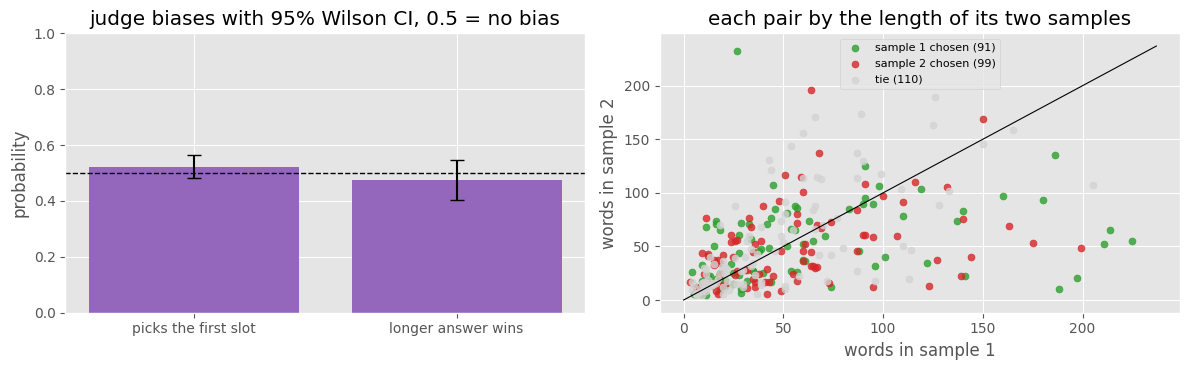

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
vals = [("picks the first slot", bias["p_first_slot"]), ("longer answer wins", bias["p_longer_wins"])]
for k, (lab, (p, lo, hi)) in enumerate(vals):
    ax[0].bar(k, p, color="tab:purple")
    ax[0].errorbar(k, p, yerr=[[p - lo], [hi - p]], color="k", capsize=5)
ax[0].axhline(0.5, color="k", ls="--", lw=1)
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels([v[0] for v in vals]); ax[0].set_ylim(0, 1)
ax[0].set_title("judge biases with 95% Wilson CI, 0.5 = no bias"); ax[0].set_ylabel("probability")
for res, color, lab in (("x", "tab:green", "sample 1 chosen"), ("y", "tab:red", "sample 2 chosen"), ("tie", "lightgray", "tie")):
    part = d_pref[d_pref.result == res]
    ax[1].scatter(part.len_x, part.len_y, c=color, label=f"{lab} ({len(part)})", s=25, alpha=0.8)
lim = max(d_pref.len_x.max(), d_pref.len_y.max()) + 5
ax[1].plot([0, lim], [0, lim], color="k", lw=0.8)
ax[1].set_xlabel("words in sample 1"); ax[1].set_ylabel("words in sample 2")
ax[1].set_title("each pair by the length of its two samples"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני הגרפים:</p>
<ul>
<li>הטיות — רווחי הסמך של שתי ההטיות חוצים את 0.5. בניסוי זה לא נמצאה הטיה מצטברת, לא למיקום ולא לאורך</li>
<li>מפת הזוגות — ירוק ואדום מפוזרים משני צדי האלכסון, בלי צד מועדף. תיקו מופיע בכל האורכים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>pairs_from: הופכת פסקים מוכרעים לזוגות chosen ו-rejected. תיקו והיפוכים לא נכנסים.</p>
</div>

In [84]:
def pairs_from(d, frame, s1, s2, prompts):
    out = []
    for _, row in d.iterrows():
        if row.result in ("x", "y"):
            c, r = (s1, s2) if row.result == "x" else (s2, s1)
            out.append(dict(i=int(row.i), instruction=frame.instruction[row.i], prompt=prompts[row.i],
                            chosen=c[row.i]["text"], rejected=r[row.i]["text"]))
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בניית הזוגות: 30 הולכים ל-held-out. אם יש פחות מ-40, רץ נוהל גיבוי שנקבע מראש, על 70 פרומפטים נוספים.</p>
</div>

In [85]:
pairs = pairs_from(d_pref, pref_df, samp1, samp2, PREF_PROMPTS)
RESULTS["part_d"]["fallback_used"] = False
if len(pairs) < CFG["min_pairs"] and len(pref_extra_df):
    print(f"only {len(pairs)} decisive pairs (< {CFG['min_pairs']}): running the pre-registered fallback on {len(pref_extra_df)} extra prompts")
    EXTRA_PROMPTS = [to_prompt(i) for i in pref_extra_df.instruction]
    outs2, _ = generate(sft, EXTRA_PROMPTS, temperature=CFG["pref_temp"], top_p=CFG["pref_top_p"], seed=GLOBAL_SEED + 8, num_return=2)
    x1, x2 = outs2[0::2], outs2[1::2]
    d_extra, s_extra = compare("D_pref_extra", pref_extra_df.instruction.tolist(), [o["text"] for o in x1], [o["text"] for o in x2], "sample_1", "sample_2")
    extra_pairs = pairs_from(d_extra, pref_extra_df, x1, x2, EXTRA_PROMPTS)
    for p in extra_pairs:
        p["i"] += 1000
    pairs += extra_pairs
    RESULTS["part_d"].update(fallback_used=True, n_pairs_first_round=len(pairs) - len(extra_pairs), n_pairs_fallback=len(extra_pairs))
if SMOKE and len(pairs) < 4:
    print("[SMOKE] too few decisive pairs; using all pairs with an arbitrary orientation")
    pairs = [dict(i=k, instruction=pref_df.instruction[k], prompt=PREF_PROMPTS[k], chosen=samp1[k]["text"], rejected=samp2[k]["text"])
             for k in range(len(PREF_PROMPTS))]
rng = np.random.RandomState(GLOBAL_SEED)
order = rng.permutation(len(pairs))
n_hold = min(CFG["n_pref_holdout"], max(1, len(pairs) // 4))
pref_hold = [pairs[k] for k in order[:n_hold]]
pref_train = [pairs[k] for k in order[n_hold:]]
RESULTS["part_d"].update(n_pairs_decisive=len(pairs), n_pref_train=len(pref_train), n_pref_holdout=len(pref_hold))
print(f"decisive pairs {len(pairs)} -> train {len(pref_train)} | held-out {len(pref_hold)}")

decisive pairs 190 -> train 160 | held-out 30


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>190 זוגות, הרבה מעל סף ה-40, ולכן הגיבוי לא הופעל. 160 לאימון ו-30 ל-held-out. בהרצות קודמות, עם 80 פרומפטים, נשארו פחות מ-40.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>embed_responses: וקטור של 896 ממדים לכל תשובה, ממוצע המצב החבוי האחרון של ה-SFT על טוקני התשובה.</p>
</div>

In [86]:
@torch.no_grad()
def embed_responses(model, prompts, responses, batch_size=8):
    model.eval()
    tok.padding_side = "right"
    feats = []
    for i in range(0, len(prompts), batch_size):
        ps, rs = prompts[i:i + batch_size], responses[i:i + batch_size]
        enc = tok([p + r + "<|im_end|>" for p, r in zip(ps, rs)], return_tensors="pt", padding=True,
                  truncation=True, max_length=CFG["max_len"] + CFG["max_new"]).to(model.device)
        plen = [len(tok(p)["input_ids"]) for p in ps]
        h = model(**enc, output_hidden_states=True).hidden_states[-1].float()
        for j in range(len(ps)):
            mask = enc["attention_mask"][j].clone().float()
            mask[:plen[j]] = 0
            feats.append(((h[j] * mask[:, None]).sum(0) / mask.sum().clamp(min=1)).cpu().numpy())
    return np.stack(feats)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטמעות ל-chosen ול-rejected, באימון וב-held-out.</p>
</div>

In [87]:
t0 = time.perf_counter()
E_c = embed_responses(sft, [p["prompt"] for p in pref_train], [p["chosen"] for p in pref_train])
E_r = embed_responses(sft, [p["prompt"] for p in pref_train], [p["rejected"] for p in pref_train])
H_c = embed_responses(sft, [p["prompt"] for p in pref_hold], [p["chosen"] for p in pref_hold])
H_r = embed_responses(sft, [p["prompt"] for p in pref_hold], [p["rejected"] for p in pref_hold])
print(f"embeddings {E_c.shape} in {time.perf_counter() - t0:.1f}s")

embeddings (160, 896) in 2.0s


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>160 זוגות אימון, 896 ממדים, ב-2 שניות. זול: forward אחד של ה-SFT לכל תשובה. אבל 160 דוגמאות מול 896 מאפיינים מסכנות בהתאמת-יתר.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ה-reward model: רגרסיה לוגיסטית על הפרש ההטמעות, בלי איבר חופשי, כלומר Bradley-Terry.</p>
<ul>
<li>chosen פחות rejected מקבל תווית 1, וההפרש ההפוך תווית 0</li>
<li>עוצמת הרגולריזציה C נבחרת מתוך RM_CS ב-cross-validation פנימי לפי זוגות, כך ששני הכיוונים של זוג לא מתפצלים</li>
<li>בהרצות קודמות, עם C קבוע, המודל הגיע ל-100% באימון ולרמת ניחוש ב-cross-validation</li>
</ul>
</div>

In [88]:
scaler = StandardScaler().fit(np.vstack([E_c, E_r]))
D = scaler.transform(E_c) - scaler.transform(E_r)
Xrm = np.vstack([D, -D])
yrm = np.r_[np.ones(len(D)), np.zeros(len(D))]
grp = np.r_[np.arange(len(D)), np.arange(len(D))]

RM_CS = [0.001, 0.01, 0.1, 1.0]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>fit_rm: רגרסיה לוגיסטית, עם C שנבחר ב-cross-validation לפי זוגות. בעבר, עם C קבוע, הגיע ל-100% באימון ולניחוש ב-cross-validation.</p>
</div>

In [89]:
def fit_rm(X, y, groups):
    k = min(5, len(set(groups)))
    best_c, best_acc = 0.1, -1.0
    if k >= 2:
        for c in RM_CS:
            hits = []
            for tr, te in GroupKFold(n_splits=k).split(X, y, groups):
                m = LogisticRegression(C=c, fit_intercept=False, max_iter=5000).fit(X[tr], y[tr])
                hits += list(m.predict(X[te]) == y[te])
            if np.mean(hits) > best_acc:
                best_c, best_acc = c, float(np.mean(hits))
    return LogisticRegression(C=best_c, fit_intercept=False, max_iter=5000).fit(X, y), best_c

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכה ב-cross-validation מקונן לפי זוגות, כך שבחירת C לא מנפחת את הדיוק, ואימון סופי על כל הזוגות.</p>
</div>

In [90]:
n_splits = min(5, len(D))
cv_hits = []
if n_splits >= 2:
    for tr_idx, te_idx in GroupKFold(n_splits=n_splits).split(Xrm, yrm, grp):
        clf, _ = fit_rm(Xrm[tr_idx], yrm[tr_idx], grp[tr_idx])
        te_pairs = sorted(set(grp[te_idx]))
        cv_hits += [int(clf.decision_function(D[[k]])[0] > 0) for k in te_pairs]
rm, rm_c = fit_rm(Xrm, yrm, grp)
w_rm = rm.coef_[0]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>rm_score: ציון ה-reward של תשובה. הפרש הציונים בין שתי תשובות הוא ההעדפה המשוערת.</p>
</div>

In [91]:
def rm_score(E):
    return scaler.transform(E) @ w_rm

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>דיוק ה-reward model: אימון, cross-validation ו-held-out. 0.5 הוא ניחוש.</p>
</div>

In [92]:
hold_diff = rm_score(H_c) - rm_score(H_r)
rm_stats = dict(n_train_pairs=len(D), n_features=int(D.shape[1]),
                cv_accuracy=wilson(sum(cv_hits), len(cv_hits)), holdout_accuracy=wilson(int((hold_diff > 0).sum()), len(hold_diff)),
                train_accuracy=round(float((D @ w_rm > 0).mean()), 3), chosen_C=rm_c)
print(json.dumps(rm_stats, indent=1))
RESULTS["part_d"]["reward_model"] = rm_stats

{
 "n_train_pairs": 160,
 "n_features": 896,
 "cv_accuracy": [
  0.45,
  0.375,
  0.527
 ],
 "holdout_accuracy": [
  0.5,
  0.332,
  0.668
 ],
 "train_accuracy": 0.906,
 "chosen_C": 0.001
}


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ל-reward model אין אות:</p>
<ul>
<li>אימון — 91%, גם עם C=0.001, הרגולריזציה החזקה ביותר. עם 896 מאפיינים ו-160 זוגות, המודל מתאים את עצמו לזוגות האימון</li>
<li>cross-validation — 0.45 (0.38 עד 0.53). ברמת ניחוש</li>
<li>held-out — 0.50 (0.33 עד 0.67). ניחוש בדיוק</li>
</ul>
<p>זה משפיע ישירות על Best-of-N בחלק ו׳, שמדרג מועמדים לפי המודל הזה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף סעיף 13: הפרש ה-reward לכל זוג. מעל 0 פירושו הסכמה עם השופט. בסוף, שמירת התוצאות.</p>
</div>

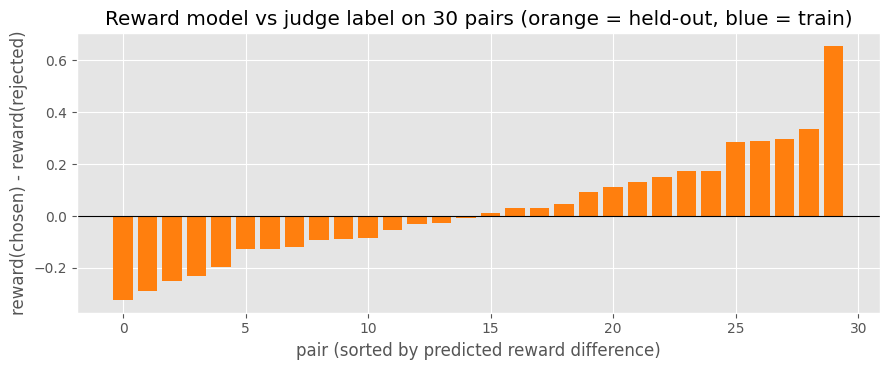

agreement with label: held-out 15/30 | shown train pairs 0/0
[checkpoint after part D] /content/hw2_runs/hw2_results.json (2.02 MB)


In [93]:
n_show = min(20, len(D) + len(hold_diff))
train_diff = D @ w_rm
items = [(float(v), "held-out") for v in hold_diff] + [(float(v), "train") for v in train_diff[:max(0, n_show - len(hold_diff))]]
items = sorted(items, key=lambda x: x[0])
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(len(items)), [v for v, _ in items], color=["tab:orange" if s == "held-out" else "tab:blue" for _, s in items])
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("pair (sorted by predicted reward difference)"); ax.set_ylabel("reward(chosen) - reward(rejected)")
ax.set_title(f"Reward model vs judge label on {len(items)} pairs (orange = held-out, blue = train)")
plt.tight_layout(); plt.show()
print("agreement with label: held-out", f"{int((hold_diff > 0).sum())}/{len(hold_diff)}", "| shown train pairs",
      f"{int(sum(v > 0 for v, s in items if s == 'train'))}/{sum(s == 'train' for _, s in items)}")
checkpoint("part D")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>15 מ-30 זוגות מעל 0: חצי-חצי, ניחוש. גם ההפרשים עצמם קטנים, בין 0.33- ל-0.65, כך שהמודל כמעט לא מפריד בין chosen ל-rejected. בכל הגרף עמודות כתומות בלבד, כי 30 זוגות ה-held-out ממלאים לבד את המכסה של 20.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים — חלק ד׳:</p>
<ul>
<li>דאטה — 300 פרומפטים נתנו 190 זוגות מוכרעים. 37% תיקו ו-21% היפוכים. השופט מתלבט הרבה בין שתי דגימות של אותו מודל</li>
<li>הטיות השופט — בניסוי זה לא נמצאה הטיה מצטברת למיקום (0.52) או לאורך (0.48). אבל ההיפוכים מראים שבזוג בודד הסדר כן משפיע</li>
<li>זוגות גבוליים — בחלק מהם שתי התשובות שגויות, והשופט בוחר את הפחות גרועה. זוג כזה מלמד "פחות גרוע", לא "טוב"</li>
<li>reward model — 91% באימון, 0.45 ב-cross-validation, ו-0.50 ב-held-out. אין אות</li>
</ul>
<p>160 זוגות מול 896 מאפיינים לא מספיקים להכללה. בפרויקט אמיתי הייתי מסנן זוגות ששתי התשובות בהם שגויות, מעביר היפוכים לשופט נוסף, ואוסף הרבה יותר זוגות, או מאמן ראש קטן יותר מעל פחות מאפיינים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ה׳ — DPO</p>
<ul>
<li>סעיף 14: DPO על מודל ה-SFT, LoRA מעליו, beta=0.1</li>
<li>סעיף 15: DPO מול SFT על הסט הקבוע ועל סט השופט</li>
<li>מעגליות: אותן 100 השוואות גם ב-Granite, שופט שני ממשפחה שלישית, והסכמה בין השופטים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 14: DPO על 160 זוגות, ו-30 ל-held-out. LoRA מעל ה-SFT, ומודל הייחוס הוא ה-SFT בלי ה-adapter.</p>
</div>

In [94]:
free_judge()
sft = None
free_gpu()
dpo_train = Dataset.from_list([dict(prompt=p["prompt"], chosen=p["chosen"] + "<|im_end|>", rejected=p["rejected"] + "<|im_end|>") for p in pref_train])
dpo_eval = Dataset.from_list([dict(prompt=p["prompt"], chosen=p["chosen"] + "<|im_end|>", rejected=p["rejected"] + "<|im_end|>") for p in pref_hold])
policy = load_sft(SFT_DIR)
dpo_steps = math.ceil(len(dpo_train) / (CFG["dpo_bsz"] * CFG["dpo_grad_acc"])) * CFG["dpo_epochs"]
dpo_args = DPOConfig(
    output_dir=os.path.join(RUN_DIR, "dpo"), beta=CFG["dpo_beta"], num_train_epochs=CFG["dpo_epochs"],
    per_device_train_batch_size=CFG["dpo_bsz"], per_device_eval_batch_size=CFG["dpo_bsz"],
    gradient_accumulation_steps=CFG["dpo_grad_acc"], learning_rate=CFG["dpo_lr"], lr_scheduler_type="cosine",
    warmup_steps=max(1, int(0.05 * dpo_steps)), optim="adamw_torch", bf16=BF16, fp16=(DEVICE == "cuda" and not BF16),
    max_length=CFG["max_len"] + CFG["max_new"], logging_steps=max(1, dpo_steps // 10), logging_first_step=True,
    eval_strategy="epoch", save_strategy="no", report_to="none", seed=GLOBAL_SEED, dataloader_pin_memory=False,
    use_cpu=(DEVICE == "cpu"), disable_tqdm=False,
)
dpo_trainer = DPOTrainer(model=policy, ref_model=None, args=dpo_args, train_dataset=dpo_train, eval_dataset=dpo_eval,
                         processing_class=tok, peft_config=LoraConfig(r=CFG["lora_r"], lora_alpha=CFG["lora_alpha"],
                                                                      lora_dropout=CFG["lora_dropout"], target_modules=LORA_ALL, task_type="CAUSAL_LM"))
n_tr, _ = count_params(dpo_trainer.model)
free_gpu()
out = dpo_trainer.train()
hist = dpo_trainer.state.log_history
train_log = [{k: round(v, 4) for k, v in h.items() if k in ("step", "loss", "rewards/accuracies", "rewards/margins")} for h in hist if "loss" in h]
eval_log = [{k: round(v, 4) for k, v in h.items() if k in ("epoch", "eval_loss", "eval_rewards/accuracies", "eval_rewards/margins")} for h in hist if "eval_loss" in h]
RESULTS["runs"]["dpo"] = dict(method="dpo_lora_on_sft", base=SFT_DIR, beta=CFG["dpo_beta"], epochs=CFG["dpo_epochs"], steps=dpo_steps,
                              lr=CFG["dpo_lr"], effective_batch=CFG["dpo_bsz"] * CFG["dpo_grad_acc"], n_pairs=len(dpo_train),
                              trainable=n_tr, trainable_pct=round(100 * n_tr / N_TOTAL_BASE, 4),
                              peak_train_gib=(gib(torch.cuda.max_memory_allocated()) if DEVICE == "cuda" else None),
                              train_runtime_s=round(out.metrics["train_runtime"], 1), seed=GLOBAL_SEED,
                              dtype=f"{ENV['dtype']} SFT weights, float32 LoRA adapters", train_log=train_log, eval_log=eval_log)
dpo_model = dpo_trainer.model
print("train log:", train_log[-3:])
print("eval log :", eval_log)

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
1,0.686322,0.683463,1.543036,32220.000000,-2.525941,-2.717600,0.734889,0.013419,-0.006364,0.562500,0.019783,-78.690062,-68.003537
2,0.313961,0.674697,1.520404,64440.000000,-2.631005,-2.799851,0.733492,-0.009191,-0.054640,0.562500,0.045450,-78.916162,-68.486301
3,0.221905,0.672182,1.505592,96660.000000,-2.684433,-2.844991,0.729074,-0.016448,-0.068688,0.562500,0.052240,-78.988732,-68.626774


train log: [{'loss': 0.2648, 'rewards/accuracies': 1.0, 'rewards/margins': 1.5492, 'step': 48}, {'loss': 0.2044, 'rewards/accuracies': 1.0, 'rewards/margins': 2.0235, 'step': 54}, {'loss': 0.2219, 'rewards/accuracies': 1.0, 'rewards/margins': 1.8516, 'step': 60}]
eval log : [{'eval_loss': 0.6835, 'eval_rewards/accuracies': 0.5625, 'eval_rewards/margins': 0.0198, 'epoch': 1.0}, {'eval_loss': 0.6747, 'eval_rewards/accuracies': 0.5625, 'eval_rewards/margins': 0.0454, 'epoch': 2.0}, {'eval_loss': 0.6722, 'eval_rewards/accuracies': 0.5625, 'eval_rewards/margins': 0.0522, 'epoch': 3.0}]


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>60 צעדים ב-63 שניות. באימון DPO הצליח: הלוס ירד מ-0.69 ל-0.22, הדיוק 100% והמרווח כ-1.9. ב-held-out השינוי קטן: הלוס ירד מ-0.684 ל-0.672, הדיוק 56%, והמרווח 0.05. המודל למד בעיקר את זוגות האימון, עם אות חלש בלבד מעבר להם.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף DPO: הלוס מול log 2, שהוא הלוס כשאין העדפה, ומרווח ה-reward באימון וב-held-out.</p>
</div>

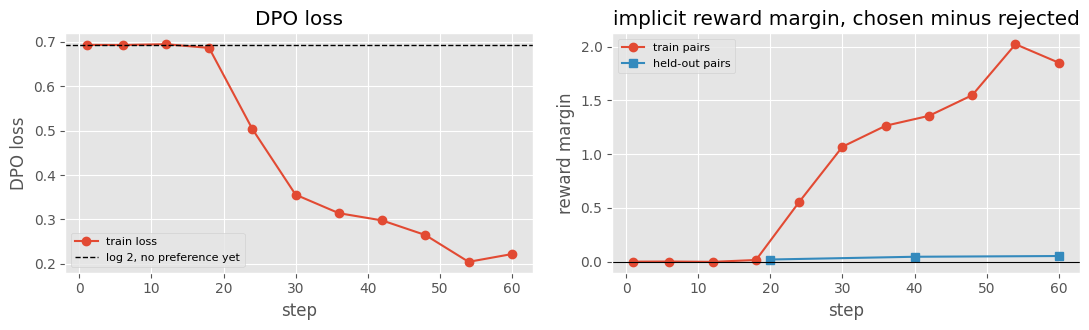

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
st = [h["step"] for h in train_log]
ax[0].plot(st, [h.get("loss") for h in train_log], marker="o", label="train loss")
ax[0].axhline(math.log(2), color="k", ls="--", lw=1, label="log 2, no preference yet")
ax[0].set_xlabel("step"); ax[0].set_ylabel("DPO loss"); ax[0].set_title("DPO loss"); ax[0].legend(fontsize=8)
ax[1].plot(st, [h.get("rewards/margins") for h in train_log], marker="o", label="train pairs")
if eval_log:
    ep = np.array([h["epoch"] for h in eval_log], dtype=float)
    ax[1].plot(ep * max(st) / max(ep.max(), 1e-9), [h.get("eval_rewards/margins") for h in eval_log], marker="s", label="held-out pairs")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("step"); ax[1].set_ylabel("reward margin"); ax[1].set_title("implicit reward margin, chosen minus rejected")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני הגרפים:</p>
<ul>
<li>DPO loss — צמוד ל-log 2 עד צעד 18, וצונח רק מצעד 20, כשהמודל רואה את אותם זוגות שוב. זו אותה תבנית כמו ב-SFT</li>
<li>reward margin — באימון המרווח עולה ל-2.0, וב-held-out הוא נשאר צמוד ל-0. הפער בין שני הקווים הוא ההתאמה לזוגות האימון</li>
</ul>
<p>הקו המקווקו הוא ln 2 = 0.693, הלוס כשהמדיניות זהה למודל הייחוס, כמו בגרף של מעבדה 5.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פרוטוקול ההערכה על DPO: מדדים אוטומטיים ובדיקות מול ה-SFT, ושלוש תשובות זו לצד זו.</p>
</div>

In [96]:
gen_eval(dpo_model, "dpo")
stats_e = pd.DataFrame([behavior_stats(resp["full_ft"]), behavior_stats(resp["dpo"])], index=["sft (greedy)", "dpo (greedy)"])
display(stats_e)
display(check_table(["full_ft", "dpo"]))
for f, a, b in list(zip(FIXED, resp["full_ft"], resp["dpo"]))[:3]:
    print(f"--- {f['id']}\nSFT: {a['text'][:220]}\nDPO: {b['text'][:220]}\n")

,n,mean_words,median_words,ended_rate,rep4,check_pass
sft (greedy),12,16.1,10.5,1.0,0.040,0.75
dpo (greedy),12,27.2,12.0,1.0,0.074,0.50


,full_ft,dpo
capital (factual),pass,pass
sky (explanation),pass,pass
fruits (format),pass,fail
json (format),pass,pass
sentiment (classification),fail,fail
summary (summarization),pass,fail
formal (rewrite),fail,fail
speed (reasoning),fail,fail
bakery (brainstorm),pass,fail
tips (advice),pass,pass


--- capital
SFT: The capital of Australia is Canberra
DPO: The capital of Australia is Canberra

--- sky
SFT: The sky is blue because sunlight scatters when it hits the atmosphere. This causes the light from the sun to be scattered in all directions, and the resulting light appears to come from a distance.
DPO: The sky is blue because sunlight scatters when it passes through the atmosphere. This causes the light from the sun to be scattered in all directions, and the resulting light appears to be scattered in different colors. 

--- fruits
SFT: Five fruits that are red are: 
- Cherry
- Raspberry
- Plum
- Plum
- Plum
DPO: Five fruits that are red are: 
- Red apple
- Red peach
- Red grape
- Red strawberry



<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>DPO שינה את התשובות יותר ממה שנראה בהתחלה. הן מתחילות כמו ה-SFT, אבל ממשיכות הלאה: 27 מול 16 מילים בממוצע, והחזרתיות עלתה מ-0.04 ל-0.07. בבדיקות DPO עוברת 6 מול 9, ונכשלת ב-fruits (4 פריטים במקום 5), ב-summary וב-bakery. לפי הבדיקות האוטומטיות, השינוי הוא לרעה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 15: DPO מול SFT, 100 השוואות ב-Phi-4 ו-24 בסט הקבוע. אותן 100 השוואות גם ב-Granite, לבדיקת מעגליות.</p>
</div>

In [97]:
d_e1, s_e1 = compare_judgeset("E_dpo_vs_sft", "dpo", "full_ft")
compare_fixed("E_dpo_vs_sft_fixed", "dpo", "full_ft")
d_e2, s_e2 = compare_judgeset("E_dpo_vs_sft_judge2", "dpo", "full_ft", name=JUDGE2_MODEL)
free_judge()

E_dpo_vs_sft: dpo vs full_ft | judge=microsoft/phi-4 | n=100 | win 33 tie 50 loss 17 | win-rate (0.33, 0.246, 0.427) | decisive pref (0.66, 0.522, 0.776) | flip 0.22 | invalid 0.0
E_dpo_vs_sft_fixed: dpo vs full_ft | judge=microsoft/phi-4 | n=24 | win 6 tie 15 loss 3 | win-rate (0.25, 0.12, 0.449) | decisive pref (0.667, 0.354, 0.879) | flip 0.0 | invalid 0.0


E_dpo_vs_sft_judge2: dpo vs full_ft | judge=ibm-granite/granite-3.3-8b-instruct | n=100 | win 26 tie 59 loss 15 | win-rate (0.26, 0.184, 0.354) | decisive pref (0.634, 0.481, 0.764) | flip 0.34 | invalid 0.0


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>DPO מול SFT:</p>
<ul>
<li>Phi-4, 100 השוואות — 33 מול 17, pref_decisive 0.66 (0.52 עד 0.78). מוכרע לטובת DPO. חצי מההשוואות תיקו</li>
<li>Phi-4, 24 השוואות — 6 מול 3, 0.67 (0.35 עד 0.88). אותו כיוון, בלי הכרעה</li>
<li>Granite, 100 השוואות — 26 מול 15, 0.63 (0.48 עד 0.76). אותו כיוון, על גבול המובהקות. 59% תיקו ו-34% היפוכים</li>
</ul>
<p>שני השופטים מעדיפים את DPO, באותו כיוון ובגודל דומה. Granite לא תייג את הזוגות, ולכן זה מחליש את החשד שהמודל "למד לרצות" דווקא את Phi-4. אבל התשובות של DPO ארוכות יותר, ועוברות פחות בדיקות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>cohen_kappa: הסכמה בין שופטים מעבר למקרה. 0 הוא מזל, ו-1 הסכמה מלאה.</p>
</div>

In [98]:
def cohen_kappa(a, b):
    labels = sorted(set(a) | set(b))
    n = len(a)
    po = sum(x == y for x, y in zip(a, b)) / n
    pe = sum((a.count(l) / n) * (b.count(l) / n) for l in labels)
    return round((po - pe) / (1 - pe), 3) if pe < 1 else float("nan"), round(po, 3)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ההסכמה בין Phi-4 ל-Granite על אותן 100 השוואות, וטבלת הסיכום של חלק ה׳.</p>
</div>

In [99]:
kappa, agree = cohen_kappa(list(d_e1.result), list(d_e2.result))
RESULTS["part_e"] = dict(judge_agreement=dict(kappa=kappa, raw_agreement=agree, n=len(d_e1)), behavior=stats_e.to_dict("index"))
print(f"judge agreement on {len(d_e1)} pairs: raw {agree} | Cohen's kappa {kappa}")
display(summary_table(["E_dpo_vs_sft", "E_dpo_vs_sft_fixed", "E_dpo_vs_sft_judge2"]))

judge agreement on 100 pairs: raw 0.63 | Cohen's kappa 0.377


,label,x,y,n,win,tie,loss,win_rate,tie_rate,pref_decisive,flip_rate,invalid_rate,judge
0,E_dpo_vs_sft,dpo,full_ft,100,33,50,17,"(0.33, 0.246, 0.427)",0.500,"(0.66, 0.522, 0.776)",0.22,0.0,microsoft/phi-4
1,E_dpo_vs_sft_fixed,dpo,full_ft,24,6,15,3,"(0.25, 0.12, 0.449)",0.625,"(0.667, 0.354, 0.879)",0.00,0.0,microsoft/phi-4
2,E_dpo_vs_sft_judge2,dpo,full_ft,100,26,59,15,"(0.26, 0.184, 0.354)",0.590,"(0.634, 0.481, 0.764)",0.34,0.0,ibm-granite/granite-3.3-8b-instruct


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תוצאות השופטים ומטריצת ההסכמה. האלכסון הוא הסכמה. בסוף, שמירת התוצאות.</p>
</div>

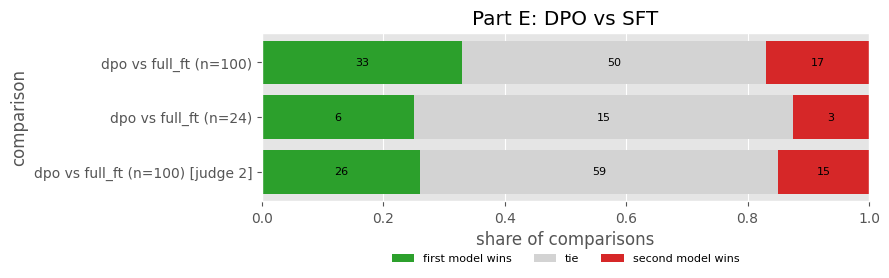

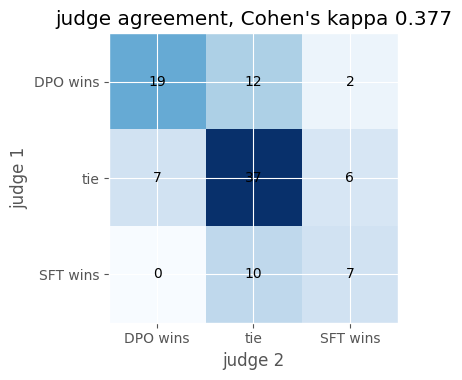

[checkpoint after part E] /content/hw2_runs/hw2_results.json (2.40 MB)


In [100]:
plot_outcomes(["E_dpo_vs_sft", "E_dpo_vs_sft_fixed", "E_dpo_vs_sft_judge2"], "Part E: DPO vs SFT")
labs = ["x", "tie", "y"]
cm = pd.crosstab(pd.Categorical(d_e1.result, labs), pd.Categorical(d_e2.result, labs), dropna=False)
fig, ax = plt.subplots(figsize=(4.8, 3.9))
ax.imshow(cm.values, cmap="Blues")
names = ["DPO wins", "tie", "SFT wins"]
ax.set_xticks(range(3)); ax.set_xticklabels(names); ax.set_yticks(range(3)); ax.set_yticklabels(names)
ax.set_xlabel("judge 2"); ax.set_ylabel("judge 1")
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(cm.values[i, j]), ha="center", va="center")
ax.set_title(f"judge agreement, Cohen's kappa {kappa}")
plt.tight_layout(); plt.show()
checkpoint("part E")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני הגרפים:</p>
<ul>
<li>תוצאות — בשלוש ההשוואות DPO מנצח יותר משהוא מפסיד, ורוב הפסקים תיקו</li>
<li>הסכמה — 63 מ-100 על האלכסון, kappa 0.38, כלומר הסכמה חלשה עד בינונית. רק ב-2 זוגות השופטים בחרו בצדדים הפוכים. כמעט כל אי-ההסכמות הן זוג שאחד השופטים הכריע בו והשני קבע תיקו</li>
</ul>
<p>לפי הרצאה 8, kappa מדווח יחד עם ההסכמה הגולמית וספירות התוויות, כמו כאן. כששני השופטים מכריעים, הם כמעט תמיד מסכימים. ההבדל ביניהם הוא בנכונות להכריע, לא בכיוון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים — חלק ה׳:</p>
<ul>
<li>אימון — DPO התאים את עצמו ל-160 הזוגות: 100% דיוק באימון, ו-56% ב-held-out</li>
<li>איכות לפי השופט — שיפור מוכרע ב-Phi-4 (0.66), ובאותו כיוון ב-Granite (0.63, על הגבול). זו התוצאה המוכרעת היחידה של יישור במחברת</li>
<li>איכות לפי הבדיקות — התשובות ארוכות יותר, חוזרות יותר, ועוברות 6 בדיקות מול 9</li>
<li>שחזוריות — בהרצה על L4 אותו DPO לא נבדל מה-SFT (0.55). כאן הכיוון נשמר בשני ה-seeds ובשני השופטים</li>
</ul>
<p>לשאלת הניתוח: השיפור משכנע חלקית. הוא נשמר בשני שופטים ובשני seeds, וזה מחליש את החשד למעגליות. מנגד, התשובות התארכו, הבדיקות האוטומטיות החמירו, והרצה אחרת של אותו קוד לא הראתה שיפור. ייתכן שחלק מהיתרון הוא תשובות מפורטות יותר ולא טובות יותר. בלי משאבים נוספים הייתי מוסיף בדיקה אנושית קטנה של 20 עד 30 זוגות, ושופט עם הנחיה מפורשת נגד אריכות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ו׳ — Best-of-N</p>
<ul>
<li>סעיף 16: 8 מועמדים מה-SFT לכל פרומפט, ה-reward model מחלק ד׳ בוחר, N=4 ו-N=8</li>
<li>סעיף 17: שופט מול דגימה בודדת ומול DPO, ועלות לשאילתה</li>
<li>ה-reward model יצא ב-held-out ברמת ניחוש, ולכן הציפייה מראש היא לשיפור קטן, אם בכלל</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>דגימת 8 מועמדים לכל פרומפט בשתי הגרלות בלתי תלויות, וניקוד. כל השוואה בחלק ו׳ נשענת על 100.</p>
</div>

In [101]:
free_judge()
free_gpu()
sft = load_sft(SFT_DIR)
N = CFG["bon_N"]
BON_SEEDS = [GLOBAL_SEED + 99 + k for k in range(len(CFG["eval_seeds"]))]
cands, bon_time = [], 0.0
for sd in BON_SEEDS:
    bon_out, t = generate(sft, JUDGE_PROMPTS, temperature=CFG["eval_temp"], top_p=CFG["pref_top_p"],
                          seed=sd, num_return=N, batch_size=max(1, CFG["judge_bsz"] // 2))
    bon_time += t
    cands += [bon_out[i * N:(i + 1) * N] for i in range(len(JUDGE_PROMPTS))]
BON_PROMPTS = JUDGE_PROMPTS * len(BON_SEEDS)
BON_INSTR = JUDGE_INSTR * len(BON_SEEDS)
t0 = time.perf_counter()
scores = [rm_score(embed_responses(sft, [p] * len(c), [x["text"] for x in c])) for p, c in zip(BON_PROMPTS, cands)]
score_time = (time.perf_counter() - t0) / len(BON_PROMPTS)
print(f"{len(BON_SEEDS)} draws x {len(JUDGE_PROMPTS)} prompts x {N} candidates in {bon_time:.1f}s | scoring {score_time:.2f}s per prompt")

2 draws x 50 prompts x 8 candidates in 200.8s | scoring 0.04s per prompt


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>800 מועמדים ב-201 שניות, כלומר כ-2 שניות לפרומפט עבור 8 מועמדים. הניקוד לוקח 0.04 שניות לפרומפט, זניח. כמעט כל העלות של Best-of-N היא הדגימה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 17: זמן וטוקנים לשאילתה בודדת, N=1, 4, 8.</p>
</div>

In [102]:
cost = {1: [], 4: [], CFG["bon_N"]: []}
for p in FIXED_PROMPTS:
    for n in cost:
        o, t = generate(sft, [p], temperature=CFG["eval_temp"], top_p=CFG["pref_top_p"], seed=GLOBAL_SEED + 99, num_return=n, batch_size=1)
        cost[n].append(dict(time_s=t, tokens=sum(x["n_tokens"] for x in o)))
cost_tab = pd.DataFrame({f"N={n}": dict(gen_time_s=round(float(np.mean([c["time_s"] for c in v])), 2),
                                        tokens=round(float(np.mean([c["tokens"] for c in v])), 1),
                                        score_time_s=(0.0 if n == 1 else round(score_time * n / CFG["bon_N"], 2)))
                         for n, v in cost.items()}).T
cost_tab["total_time_s"] = (cost_tab.gen_time_s + cost_tab.score_time_s).round(2)
display(cost_tab)

,gen_time_s,tokens,score_time_s,total_time_s
N=1,1.16,37.9,0.00,1.16
N=4,1.25,116.3,0.02,1.27
N=8,1.87,264.8,0.04,1.91


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטוקנים גדלים כמעט ליניארית עם N: פי 3.1 ב-N=4 ופי 7 ב-N=8. הזמן גדל לאט יותר, פי 1.1 ופי 1.6, כי ה-GPU מייצר את כל המועמדים במקביל. ב-GPU יחיד עם זיכרון פנוי Best-of-N זול בזמן, אבל יקר בחישוב. בשרת עמוס, העלות האמיתית היא הטוקנים. הניקוד זניח.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 16: בחירת המועמד עם ה-reward הגבוה, והמועמד הראשון כדגימה בודדת. בגרף, ה-reward של הנבחר מול N.</p>
</div>

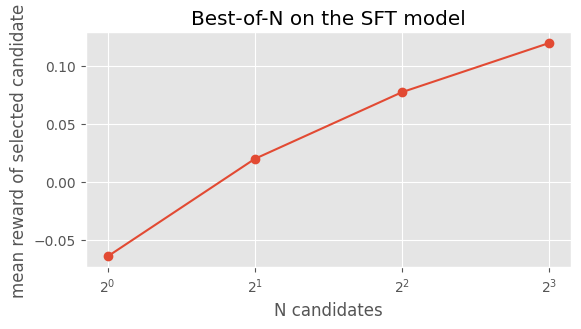

{1: -0.064, 2: 0.02, 4: 0.077, 8: 0.119}


In [103]:
Ns = [n for n in [1, 2, 4, 8] if n <= CFG["bon_N"]]
curve = {n: float(np.mean([max(s[:n]) for s in scores])) for n in Ns}
BON = {"sft_single": [c[0] for c in cands]}
for n in dict.fromkeys([4, N]):
    BON[f"bon{n}"] = [c[int(np.argmax(s[:n]))] for c, s in zip(cands, scores)]
BON_TOP = f"bon{N}"
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(list(curve), list(curve.values()), marker="o"); ax.set_xscale("log", base=2)
ax.set_xlabel("N candidates"); ax.set_ylabel("mean reward of selected candidate"); ax.set_title("Best-of-N on the SFT model")
plt.tight_layout(); plt.show()
print({n: round(v, 3) for n, v in curve.items()})
RESULTS["part_f"] = dict(reward_vs_N=curve, cost=cost_tab.to_dict("index"), n_prompts=len(cands))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ה-reward של הנבחר עולה עם N, אבל בקושי: מ-0.06- ל-0.12, בצעדים של 0.08, 0.06 ו-0.04. בהדגמה של הרצאה 5 העלייה הזו מובטחת לכל ציון, כי המקסימום של יותר מועמדים תמיד גבוה יותר. כאן היא כמעט שטוחה, כי ה-reward model כמעט לא מפריד בין תשובות. זה לא אומר שהתשובות טובות יותר. רק השופט יראה אם יש שיפור.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סעיף 17, השופט, 100 השוואות: Best-of-4 ו-Best-of-8 מול דגימה בודדת, ו-Best-of-8 מול DPO. מתחת, מדדים אוטומטיים.</p>
</div>

In [104]:
BT = lambda k: [o["text"] for o in BON[k]]
compare("F_bon4_vs_sft", BON_INSTR, BT("bon4"), BT("sft_single"), "bon4", "sft_single")
compare("F_bon8_vs_sft", BON_INSTR, BT(BON_TOP), BT("sft_single"), BON_TOP, "sft_single")
compare("F_bon8_vs_dpo", BON_INSTR, BT(BON_TOP), texts(JSAMP, "dpo"), BON_TOP, "dpo_single")
display(summary_table(["F_bon4_vs_sft", "F_bon8_vs_sft", "F_bon8_vs_dpo"]))
stats_f = pd.DataFrame([dict(n=len(v), mean_words=round(float(np.mean([len(words(o["text"])) for o in v])), 1),
                             ended_rate=round(float(np.mean([o["ended"] for o in v])), 3),
                             rep4=round(float(np.mean([rep4(o["text"]) for o in v])), 3)) for v in BON.values()],
                       index=list(BON))
display(stats_f)
RESULTS["part_f"]["behavior"] = stats_f.to_dict("index")

F_bon4_vs_sft: bon4 vs sft_single | judge=microsoft/phi-4 | n=100 | win 24 tie 52 loss 24 | win-rate (0.24, 0.167, 0.332) | decisive pref (0.5, 0.364, 0.636) | flip 0.17 | invalid 0.0
F_bon8_vs_sft: bon8 vs sft_single | judge=microsoft/phi-4 | n=100 | win 24 tie 45 loss 31 | win-rate (0.24, 0.167, 0.332) | decisive pref (0.436, 0.314, 0.567) | flip 0.2 | invalid 0.0
F_bon8_vs_dpo: bon8 vs dpo_single | judge=microsoft/phi-4 | n=100 | win 26 tie 43 loss 31 | win-rate (0.26, 0.184, 0.354) | decisive pref (0.456, 0.334, 0.584) | flip 0.25 | invalid 0.0


,label,x,y,n,win,tie,loss,win_rate,tie_rate,pref_decisive,flip_rate,invalid_rate,judge
0,F_bon4_vs_sft,bon4,sft_single,100,24,52,24,"(0.24, 0.167, 0.332)",0.52,"(0.5, 0.364, 0.636)",0.17,0.0,microsoft/phi-4
1,F_bon8_vs_sft,bon8,sft_single,100,24,45,31,"(0.24, 0.167, 0.332)",0.45,"(0.436, 0.314, 0.567)",0.20,0.0,microsoft/phi-4
2,F_bon8_vs_dpo,bon8,dpo_single,100,26,43,31,"(0.26, 0.184, 0.354)",0.43,"(0.456, 0.334, 0.584)",0.25,0.0,microsoft/phi-4


,n,mean_words,ended_rate,rep4
sft_single,100,47.1,0.98,0.022
bon4,100,60.0,0.98,0.029
bon8,100,59.6,0.99,0.031


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התוצאות:</p>
<ul>
<li>Best-of-8 מול דגימה בודדת — 24 מול 31, pref_decisive 0.44 (0.31 עד 0.57). אין שיפור, ואפילו נטייה הפוכה</li>
<li>Best-of-4 מול דגימה בודדת — 24 מול 24, 0.50. אין הבדל</li>
<li>Best-of-8 מול DPO — 26 מול 31, 0.46 (0.33 עד 0.58). אין הכרעה</li>
</ul>
<p>זה מה שצפוי מ-reward model בלי אות: הבחירה בין המועמדים כמעט אקראית. Best-of-N בחר תשובות ארוכות יותר (60 מול 47 מילים), והשופט לא העדיף אותן. בהרצה על L4 Best-of-8 ניצח באופן מוכרע (0.70). הפער בין ההרצות מראה כמה התוצאה הזו לא יציבה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מעגליות בחלק ו׳: אותן 100 השוואות של Best-of-8 מול דגימה בודדת גם ב-Granite, שלא תייג את דאטת ה-reward model, והסכמה בין השופטים.</p>
</div>

In [105]:
compare("F_bon8_vs_sft_judge2", BON_INSTR, BT(BON_TOP), BT("sft_single"), BON_TOP, "sft_single", name=JUDGE2_MODEL)
free_judge()
d_f1 = pd.DataFrame(RESULTS["comparisons"]["F_bon8_vs_sft"]["rows"])
d_f2 = pd.DataFrame(RESULTS["comparisons"]["F_bon8_vs_sft_judge2"]["rows"])
kappa_f, agree_f = cohen_kappa(list(d_f1.result), list(d_f2.result))
RESULTS["part_f"]["judge2"] = dict(kappa=kappa_f, raw_agreement=agree_f)
print(f"Phi-4 vs Granite on Best-of-8 vs single sample: raw agreement {agree_f} | Cohen's kappa {kappa_f}")
display(summary_table(["F_bon8_vs_sft", "F_bon8_vs_sft_judge2"]))

F_bon8_vs_sft_judge2: bon8 vs sft_single | judge=ibm-granite/granite-3.3-8b-instruct | n=100 | win 20 tie 58 loss 22 | win-rate (0.2, 0.133, 0.289) | decisive pref (0.476, 0.334, 0.623) | flip 0.35 | invalid 0.0
Phi-4 vs Granite on Best-of-8 vs single sample: raw agreement 0.63 | Cohen's kappa 0.406


,label,x,y,n,win,tie,loss,win_rate,tie_rate,pref_decisive,flip_rate,invalid_rate,judge
0,F_bon8_vs_sft,bon8,sft_single,100,24,45,31,"(0.24, 0.167, 0.332)",0.45,"(0.436, 0.314, 0.567)",0.20,0.0,microsoft/phi-4
1,F_bon8_vs_sft_judge2,bon8,sft_single,100,20,58,22,"(0.2, 0.133, 0.289)",0.58,"(0.476, 0.334, 0.623)",0.35,0.0,ibm-granite/granite-3.3-8b-instruct


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גם Granite לא רואה יתרון: 20 מול 22, pref_decisive 0.48 (0.33 עד 0.62), עם 58% תיקו ו-35% היפוכים. ההסכמה בין השופטים 0.63, kappa 0.41. שני שופטים ממשפחות שונות מסכימים שאין כאן שיפור, כך שהתוצאה השלילית לא תלויה בשופט אחד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בקרת אורך: Best-of-8 בחר תשובות באורך שונה מהדגימה הבודדת. כאן אותן 100 השוואות של Phi-4 מחולקות לפי האורך, בלי קריאות נוספות לשופט. אם יש יתרון בזוגות באורך דומה, הוא לא נובע מאורך.</p>
</div>

In [106]:
d_f = pd.DataFrame(RESULTS["comparisons"]["F_bon8_vs_sft"]["rows"])
d_f["len_ratio"] = d_f[["len_x", "len_y"]].min(axis=1) / d_f[["len_x", "len_y"]].max(axis=1).clip(lower=1)
rows_l = []
for name, part in [("all pairs", d_f), ("similar length, ratio >= 0.8", d_f[d_f.len_ratio >= 0.8]),
                   ("Best-of-8 shorter", d_f[d_f.len_x < d_f.len_y]), ("Best-of-8 longer", d_f[d_f.len_x > d_f.len_y])]:
    w, l = int((part.result == "x").sum()), int((part.result == "y").sum())
    rows_l.append(dict(subset=name, n=len(part), win=w, tie=len(part) - w - l, loss=l,
                       pref_decisive=(wilson(w, w + l) if w + l else None)))
len_ctrl = pd.DataFrame(rows_l).set_index("subset")
display(len_ctrl)
RESULTS["part_f"]["length_control"] = len_ctrl.to_dict("index")

,n,win,tie,loss,pref_decisive
subset,,,,,
all pairs,100,24,45,31,"(0.436, 0.314, 0.567)"
"similar length, ratio >= 0.8",41,5,23,13,"(0.278, 0.125, 0.509)"
Best-of-8 shorter,23,6,12,5,"(0.545, 0.28, 0.787)"
Best-of-8 longer,52,16,16,20,"(0.444, 0.295, 0.604)"


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גם בזוגות באורך דומה, 41 זוגות, אין יתרון: 5 מול 13, 0.28 (0.13 עד 0.51), נטייה נגד Best-of-8. כש-Best-of-8 קצר יותר הוא מנצח 6 מול 5, וכשהוא ארוך יותר 16 מול 20. אין עדות לכך שהאורך מסתיר שיפור, או שהשופט מתגמל אורך.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרפים לחלק ו׳: תוצאות השופט, ו-reward מול זמן לשאילתה. בסוף, שמירת התוצאות.</p>
</div>

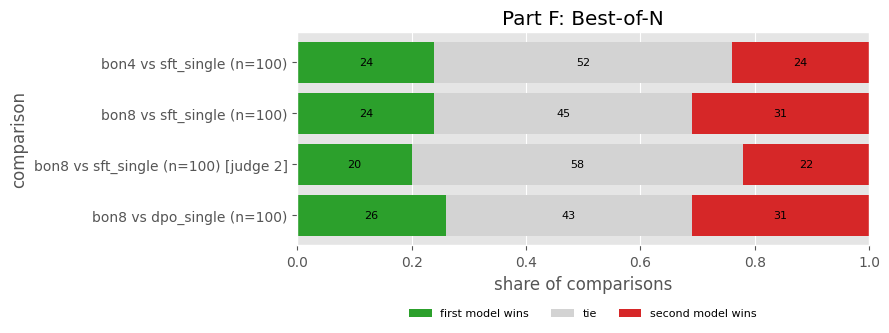

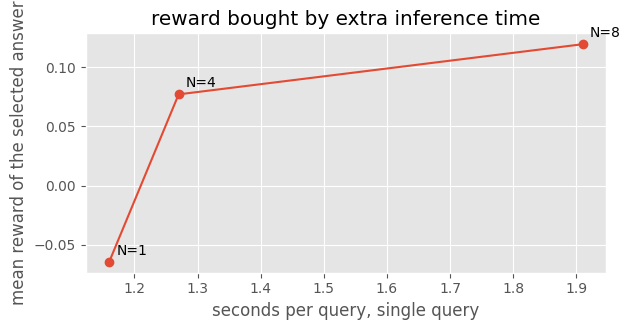

[checkpoint after part F] /content/hw2_runs/hw2_results.json (3.08 MB)


In [107]:
plot_outcomes(["F_bon4_vs_sft", "F_bon8_vs_sft", "F_bon8_vs_sft_judge2", "F_bon8_vs_dpo"], "Part F: Best-of-N")
fig, ax = plt.subplots(figsize=(6.5, 3.4))
pts = [(cost_tab.loc[k, "total_time_s"], curve.get(int(k.split("=")[1]), np.nan), k) for k in cost_tab.index]
ax.plot([p[0] for p in pts], [p[1] for p in pts], marker="o")
for x, yv, k in pts:
    ax.annotate(k, (x, yv), textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("seconds per query, single query"); ax.set_ylabel("mean reward of the selected answer")
ax.set_title("reward bought by extra inference time")
plt.tight_layout(); plt.show()
checkpoint("part F")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני הגרפים:</p>
<ul>
<li>תוצאות — אף השוואה לא מוכרעת. ב-Granite יש עוד יותר תיקו מאשר ב-Phi-4</li>
<li>reward מול זמן — 0.75 שניות נוספות לשאילתה קונות עלייה של 0.18 ב-reward, ממודל שה-reward שלו ברמת ניחוש</li>
</ul>
<p>לשאלת הניתוח: כאן היתרון של Best-of-N לא גדל עם N, כי ה-reward model לא מזהה תשובות טובות. העלות בטוקנים גדלה כמעט ליניארית בכל מקרה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים — חלק ו׳:</p>
<ul>
<li>איכות — אין שיפור מול דגימה בודדת, לא ב-Best-of-4 (0.50) ולא ב-Best-of-8 (0.44 ב-Phi-4, 0.48 ב-Granite). מול DPO אין הכרעה (0.46)</li>
<li>עלות — פי 7 טוקנים ופי 1.6 זמן ב-N=8, בלי אימון בכלל. DPO עולה דקה של אימון, ואפס בהסקה</li>
<li>סיבה — ה-reward model מחלק ד׳ ברמת ניחוש, ולכן הבחירה בין המועמדים כמעט אקראית. בקרת האורך לא מגלה יתרון מוסתר</li>
<li>שחזוריות — על L4 Best-of-8 ניצח באופן מוכרע (0.70). עם reward model בלי אות, תוצאה כזו היא רעש או מעגליות, לא שיפור</li>
</ul>
<p>לשאלת הניתוח: Best-of-N מתאים כשיש reward model טוב, אין תקציב לאימון, והתנועה נמוכה, או כשרוצים להחליף reward בלי לאמן מחדש. DPO עדיף כשיש הרבה שאילתות, כי העלות שלו חד-פעמית. היתרון של Best-of-N גדל עם N בתשואה פוחתת, ורק אם ה-reward model באמת מזהה איכות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בונוס — מיקום שכבות LoRA</p>
<ul>
<li>סעיף 23: LoRA על q, k, v, o בלבד, מול כל השכבות הליניאריות, באותם תנאים</li>
<li>נמדד: איכות לפי השופט מול מספר פרמטרים, זיכרון וזמן</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון LoRA על attention בלבד, ואז פרוטוקול ההערכה.</p>
</div>

In [111]:
m = run_sft("lora_attn", "lora", train_ds, eval_ds, targets=LORA_ATTN)
gen_eval(m, "lora_attn")
m = None
free_gpu()

Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,1.982701,2.030942,2.072935,0.555927,410479.000000
2,1.843054,2.032204,2.001244,0.555005,820958.000000


lora_attn: lora | trainable 2,163,584 (0.4379%) | steps 376 | time 256.0s | peak 10.521 GiB | final train loss 1.8431 | eval [(1.0, 2.0309), (2.0, 2.0322)]


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>attention בלבד מול כל השכבות:</p>
<ul>
<li>פרמטרים — 2.2M מול 8.8M, פי 4 פחות. 0.44% מהבסיס</li>
<li>זמן — 256 שניות מול 323, כלומר 21% פחות</li>
<li>זיכרון — 10.5 GiB מול 8.7. יותר, לא פחות, ובניסוי זה לא בדקנו למה</li>
<li>לוס — ה-held-out 2.03, נמוך מ-LoRA המלאה (2.05). לוס האימון גבוה יותר, 1.84 מול 1.74, כך שיש פחות התאמה לדוגמאות האימון</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משאבים, מדדים אוטומטיים ושופט: attention בלבד מול הבסיס על הסט הקבוע, ומול LoRA המלאה על סט השופט.</p>
</div>

In [112]:
tab_bonus = run_table(["lora", "lora_attn"])
display(tab_bonus[["trainable", "trainable_pct", "peak_gib", "time_s", "train_loss", "eval_loss"]])
stats_bonus = pd.DataFrame([behavior_stats(resp[k]) for k in ["lora", "lora_attn"]], index=["lora (all-linear)", "lora_attn"])
display(stats_bonus)
compare_fixed("BONUS_attn_vs_base", "lora_attn", "base")
compare_judgeset("BONUS_attn_vs_all", "lora_attn", "lora")
display(summary_table(["BONUS_attn_vs_base", "BONUS_attn_vs_all", "B_lora_vs_base"]))
RESULTS["bonus"] = dict(runs=tab_bonus.to_dict("index"), behavior=stats_bonus.to_dict("index"))
free_judge()

,trainable,trainable_pct,peak_gib,time_s,train_loss,eval_loss
run,,,,,,
lora,8799104,1.7811,8.679,322.8,1.7432,2.0513
lora_attn,2163584,0.4379,10.521,256.0,1.8431,2.0322


,n,mean_words,median_words,ended_rate,rep4,check_pass
lora (all-linear),12,18.2,13.0,1.0,0.035,0.750
lora_attn,12,17.1,10.0,1.0,0.038,0.833


BONUS_attn_vs_base: lora_attn vs base | judge=microsoft/phi-4 | n=24 | win 9 tie 7 loss 8 | win-rate (0.375, 0.212, 0.573) | decisive pref (0.529, 0.31, 0.738) | flip 0.167 | invalid 0.0
BONUS_attn_vs_all: lora_attn vs lora | judge=microsoft/phi-4 | n=100 | win 27 tie 37 loss 36 | win-rate (0.27, 0.193, 0.364) | decisive pref (0.429, 0.314, 0.551) | flip 0.17 | invalid 0.0


,label,x,y,n,win,tie,loss,win_rate,tie_rate,pref_decisive,flip_rate,invalid_rate,judge
0,BONUS_attn_vs_base,lora_attn,base,24,9,7,8,"(0.375, 0.212, 0.573)",0.292,"(0.529, 0.31, 0.738)",0.167,0.0,microsoft/phi-4
1,BONUS_attn_vs_all,lora_attn,lora,100,27,37,36,"(0.27, 0.193, 0.364)",0.370,"(0.429, 0.314, 0.551)",0.170,0.0,microsoft/phi-4
2,B_lora_vs_base,lora,base,24,9,6,9,"(0.375, 0.212, 0.573)",0.250,"(0.5, 0.29, 0.71)",0.083,0.0,microsoft/phi-4


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התוצאות:</p>
<ul>
<li>מול LoRA המלאה, 100 השוואות — 27 מול 36, pref_decisive 0.43 (0.31 עד 0.55). נוטה להפסיד, בלי הכרעה</li>
<li>מול הבסיס, 24 השוואות — 0.53 (0.31 עד 0.74). בלי הכרעה, כמו LoRA המלאה</li>
<li>מדדים אוטומטיים — 17 מילים, חזרתיות 0.04, כל התשובות עוצרות, ו-10 בדיקות מול 9</li>
</ul>
<p>לסעיף 23: פי 4 פחות פרמטרים ו-21% פחות זמן, בלי פגיעה מדידה באיכות. בהרצה על L4 attention בלבד הפסידה באופן מוכרע (0.31). כלומר ההבדל בין שתי התצורות קטן, והכיוון שלו לא יציב.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרפים לבונוס: לוס, תוצאות השופט. בסוף, שמירת התוצאות.</p>
</div>

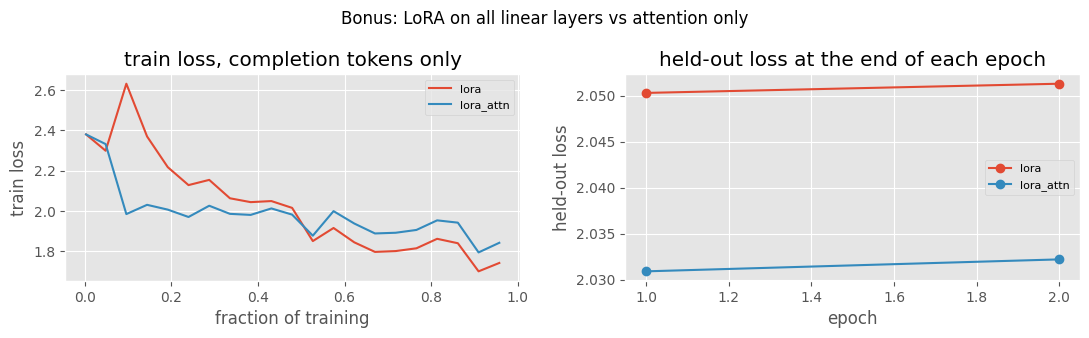

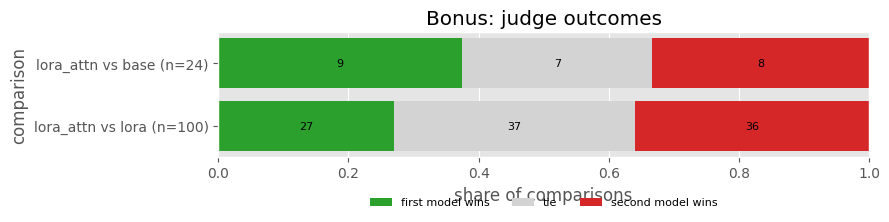

[checkpoint after bonus] /content/hw2_runs/hw2_results.json (3.31 MB)


In [113]:
plot_losses(["lora", "lora_attn"], "Bonus: LoRA on all linear layers vs attention only")
plot_outcomes(["BONUS_attn_vs_base", "BONUS_attn_vs_all"], "Bonus: judge outcomes")
checkpoint("bonus")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני הגרפים:</p>
<ul>
<li>לוס — attention בלבד יורדת מהר בהתחלה ואז משתטחת, ומסיימת גבוה יותר באימון. ב-held-out היא נמוכה יותר ויציבה</li>
<li>שופט — מול LoRA המלאה, attention בלבד מפסידה קצת יותר משהיא מנצחת, בלי הכרעה. מול הבסיס, על 24 השוואות, אין הכרעה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים — בונוס:</p>
<ul>
<li>פרמטרים וזמן — attention בלבד מאמנת פי 4 פחות פרמטרים, 0.44% מהבסיס, ורצה 21% מהר יותר</li>
<li>זיכרון — 10.5 GiB מול 8.7, יותר ולא פחות, ובניסוי זה לא ברור למה</li>
<li>איכות — אין הבדל מוכרע מ-LoRA על כל השכבות (0.43). לוס ה-held-out אפילו נמוך יותר</li>
<li>שחזוריות — על L4 attention בלבד הפסידה באופן מוכרע (0.31). כאן לא, וגם שני ה-seeds נותנים 0.52 ו-0.35</li>
</ul>
<p>לסעיף 23: בהרצה הזו החיסכון בפרמטרים לא עלה באיכות מדידה, אבל ב-L4 כן. מאמר LoRA המקורי התמקד ב-attention, והמסקנה כאן היא שבמודל של 0.5B ההבדל בין התצורות קטן מהרעש של השופט. בתקציב הזה עדיין הייתי בוחר בכל השכבות, שהן רק 1.8% מהפרמטרים, כי בשתי ההרצות הן לא הפסידו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חוסן — שני ה-seeds בנפרד:</p>
<ul>
<li>נספח א׳ דורש לחזור על מדידות רועשות לפחות פעמיים. כל השוואת שופט רצה על שתי הגרלות, ועד כאן הן דווחו יחד</li>
<li>כאן כל הגרלה מדווחת לבד, כדי לראות אם הכיוון נשמר בשתיהן</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>per_seed: win, tie ו-loss בכל אחת משתי ההגרלות של השוואה. החצי הראשון של השורות הוא ה-seed הראשון.</p>
</div>

In [114]:
def per_seed(label):
    s = RESULTS["comparisons"][label]["summary"]
    rows = RESULTS["comparisons"][label]["rows"]
    half = len(rows) // 2
    out = dict(comparison=label, pair=f"{s['x']} vs {s['y']}", judge=s["judge"].split("/")[-1])
    for k, part in enumerate([rows[:half], rows[half:]], 1):
        w = sum(r["result"] == "x" for r in part)
        l = sum(r["result"] == "y" for r in part)
        out[f"seed {k} win/tie/loss"] = f"{w}/{len(part) - w - l}/{l}"
        out[f"seed {k} pref_decisive"] = round(w / (w + l), 3) if w + l else None
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטבלה, לכל ההשוואות על 100 זוגות.</p>
</div>

In [115]:
SEED_LABELS = ["B_full_vs_base_js", "B_lora_vs_base_js", "B_qlora_vs_base_js", "B_qlora_vs_lora", "B_lora_vs_full",
               "C_small_vs_lora", "C_noisy_vs_lora", "E_dpo_vs_sft", "E_dpo_vs_sft_judge2", "F_bon4_vs_sft",
               "F_bon8_vs_sft", "F_bon8_vs_sft_judge2", "F_bon8_vs_dpo", "BONUS_attn_vs_all"]
seed_tab = pd.DataFrame([per_seed(l) for l in SEED_LABELS if l in RESULTS["comparisons"]]).set_index("comparison")
display(seed_tab)
RESULTS["per_seed"] = seed_tab.to_dict("index")

,pair,judge,seed 1 win/tie/loss,seed 1 pref_decisive,seed 2 win/tie/loss,seed 2 pref_decisive
comparison,,,,,,
B_full_vs_base_js,full_ft vs base,phi-4,22/16/12,0.647,17/18/15,0.531
B_lora_vs_base_js,lora vs base,phi-4,21/20/9,0.700,18/16/16,0.529
B_qlora_vs_base_js,qlora vs base,phi-4,23/18/9,0.719,17/13/20,0.459
B_qlora_vs_lora,qlora vs lora,phi-4,16/21/13,0.552,9/16/25,0.265
B_lora_vs_full,lora vs full_ft,phi-4,11/24/15,0.423,17/20/13,0.567
C_small_vs_lora,lora_small vs lora,phi-4,18/16/16,0.529,11/16/23,0.324
C_noisy_vs_lora,lora_noisy vs lora,phi-4,17/18/15,0.531,17/15/18,0.486
E_dpo_vs_sft,dpo vs full_ft,phi-4,14/27/9,0.609,19/23/8,0.704
E_dpo_vs_sft_judge2,dpo vs full_ft,granite-3.3-8b-instruct,12/30/8,0.600,14/29/7,0.667


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה שני ה-seeds מראים:</p>
<ul>
<li>יציב — DPO מול SFT: 0.61 ו-0.70 ב-Phi-4, 0.60 ו-0.67 ב-Granite. זו ההשוואה היחידה שבה שני ה-seeds ושני השופטים מסכימים על הכיוון</li>
<li>יציב בכיוון — שלוש השיטות מול הבסיס נוטות לטובתן בשני ה-seeds, חוץ מ-QLoRA ב-seed השני (0.46)</li>
<li>מתהפך — QLoRA מול LoRA (0.55 ו-0.27), small מול LoRA (0.53 ו-0.32), Best-of-4 (0.40 ו-0.61), Best-of-8 (0.52 ו-0.36), ו-attention בלבד (0.52 ו-0.35)</li>
</ul>
<p>כלומר, חלק ניכר מההבדלים שנמדדו על 50 פרומפטים תלוי בהגרלה. זה מסביר למה הרצה אחרת של אותו קוד, על L4, נתנה מסקנות שונות בארבע השוואות. מסקנה אמינה צריכה להישמר בשני ה-seeds, בשני השופטים ובשתי ההרצות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סינתזה — פרופיל אימון ויישור</p>
<ul>
<li>סעיף 18: טבלה של כל השיטות: איכות לפי שופט, זמן אימון, זיכרון, עלות הסקה</li>
<li>win-rate הוא ניצחונות מכל ההשוואות, כנדרש. pref_decisive הוא ניצחונות מתוך ההכרעות, והוא מראה כיוון</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>wr: win-rate, שיעור תיקו ומול מי, או ריק אם ההשוואה לא רצה.</p>
</div>

In [116]:
def wr(label):
    s = RESULTS["comparisons"].get(label, {}).get("summary")
    return (s["win_rate"], s["tie_rate"], s["y"]) if s else ((None, None, None), None, None)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>run_get: שדה אחד של אימון, או ריק אם לא רץ.</p>
</div>

In [117]:
def run_get(name, key):
    return RESULTS["runs"].get(name, {}).get(key)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטבלה והגרפים. שיטות ה-SFT מושוות לבסיס, ו-DPO ו-Best-of-N ל-SFT, אז משווים רק בתוך כל קבוצה.</p>
</div>

,compared_to,n,win_rate,ci_low,ci_high,tie_rate,pref_decisive,pref_low,pref_high,trainable_pct,train_time_s,peak_train_gib,infer_time_s,infer_tokens
method,,,,,,,,,,,,,,
Full FT,base,100,0.39,0.300,0.488,0.34,0.591,0.470,0.701,100.0000,193.1,15.196,1.16,37.9
LoRA,base,100,0.39,0.300,0.488,0.36,0.609,0.487,0.719,1.7811,322.8,8.679,1.16,37.9
QLoRA,base,100,0.40,0.309,0.498,0.31,0.580,0.462,0.689,1.7811,411.1,8.538,1.16,37.9
DPO (LoRA on SFT),full_ft,100,0.33,0.246,0.427,0.50,0.660,0.522,0.776,1.7809,62.8,5.843,1.16,37.9
Best-of-4,sft_single,100,0.24,0.167,0.332,0.52,0.500,0.364,0.636,0.0000,0.0,NaN,1.27,116.3
Best-of-8,sft_single,100,0.24,0.167,0.332,0.45,0.436,0.314,0.567,0.0000,0.0,NaN,1.91,264.8


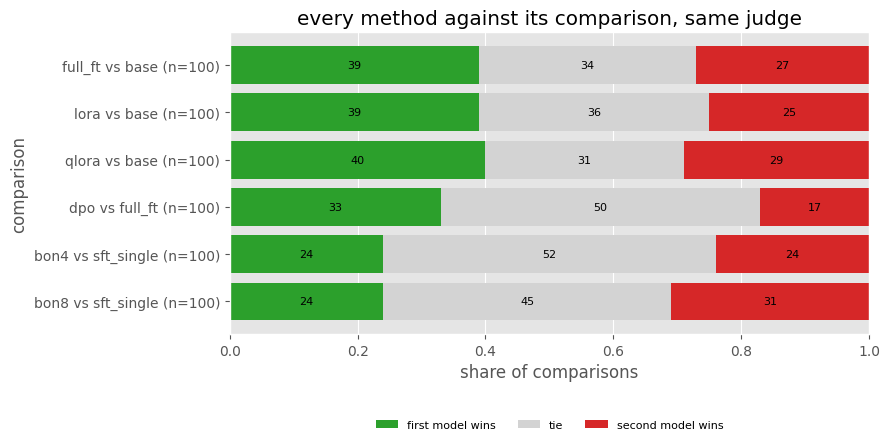

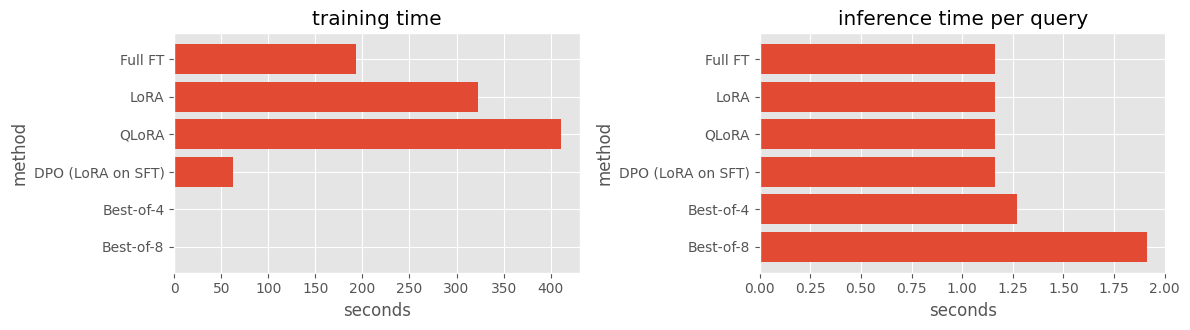

In [118]:
cost_f = RESULTS["part_f"]["cost"]
rows = []
for method, label, run, infer in [("Full FT", "B_full_vs_base_js", "full_ft", "N=1"), ("LoRA", "B_lora_vs_base_js", "lora", "N=1"),
                                  ("QLoRA", "B_qlora_vs_base_js", "qlora", "N=1"), ("DPO (LoRA on SFT)", "E_dpo_vs_sft", "dpo", "N=1"),
                                  ("Best-of-4", "F_bon4_vs_sft", None, "N=4"), (f"Best-of-{CFG['bon_N']}", "F_bon8_vs_sft", None, f"N={CFG['bon_N']}")]:
    (p, lo, hi), tie, comp = wr(label)
    s = RESULTS["comparisons"].get(label, {}).get("summary", {})
    dp = s.get("pref_decisive") or (None, None, None)
    rows.append(dict(method=method, compared_to=comp, n=s.get("n"), win_rate=p, ci_low=lo, ci_high=hi, tie_rate=tie,
                     pref_decisive=dp[0], pref_low=dp[1], pref_high=dp[2],
                     trainable_pct=(run_get(run, "trainable_pct") if run else 0.0),
                     train_time_s=(run_get(run, "train_runtime_s") if run else 0.0),
                     peak_train_gib=(run_get(run, "peak_train_gib") if run else None),
                     infer_time_s=cost_f[infer]["total_time_s"], infer_tokens=cost_f[infer]["tokens"]))
synth = pd.DataFrame(rows).set_index("method")
display(synth)
RESULTS["synthesis"] = synth.to_dict("index")
plot_outcomes(["B_full_vs_base_js", "B_lora_vs_base_js", "B_qlora_vs_base_js", "E_dpo_vs_sft", "F_bon4_vs_sft", "F_bon8_vs_sft"],
              "every method against its comparison, same judge")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].barh(synth.index, synth.train_time_s.fillna(0)); ax[0].set_title("training time"); ax[0].invert_yaxis()
ax[0].set_xlabel("seconds"); ax[0].set_ylabel("method")
ax[1].barh(synth.index, synth.infer_time_s); ax[1].set_title("inference time per query"); ax[1].invert_yaxis()
ax[1].set_xlabel("seconds"); ax[1].set_ylabel("method")
plt.tight_layout(); plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושת הגרפים והטבלה:</p>
<ul>
<li>איכות מול הבסיס — Full FT (0.59), LoRA (0.61) ו-QLoRA (0.58) נוטות לנצח, אף אחת לא מוכרעת</li>
<li>איכות מול SFT — DPO מוכרעת (0.66). Best-of-4 (0.50) ו-Best-of-8 (0.44) לא נבדלות</li>
<li>זמן אימון — QLoRA הכי יקרה, 411 שניות. Full FT הכי מהירה, 193. DPO זולה, 63 שניות, כי היא רצה על 160 זוגות בלבד. ל-Best-of-N אין אימון</li>
<li>זמן הסקה — זהה לכל השיטות המאומנות, 1.16 שניות. Best-of-8 איטית פי 1.6, ומייצרת פי 7 טוקנים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פרופיל אימון ויישור — עמוד הסיכום, סעיפים 19 ו-20:</p>
<p>סעיף 19 — מה השתפר בוודאות סבירה:</p>
<ul>
<li>SFT לימד את המודל להיות עוזר: עצירה עצמית ב-100% מהתשובות, בלי זבל, ותשובות קצרות פי 5. זה נמדד ישירות, בלי שופט, ונשמר בשתי ההרצות</li>
<li>המשאבים: LoRA חוסכת 43% זיכרון מול Full FT ומאמנת 1.8% מהפרמטרים. אלה מדידות, לא הערכות</li>
<li>LoRA לא נופלת מ-Full FT: 0.50 כאן, ובלי הכרעה גם ב-L4</li>
</ul>
<p>מה תלוי-שופט ולכן פחות ודאי:</p>
<ul>
<li>DPO מול SFT — מוכרע ב-Phi-4 ובאותו כיוון ב-Granite, בשני ה-seeds. אבל התשובות התארכו, הבדיקות החמירו, ובהרצה על L4 לא היה שיפור</li>
<li>השיטות מול הבסיס — נוטות לטובתן. ב-L4 הוכרעו, כאן לא</li>
<li>Best-of-N, QLoRA, attention בלבד והסט הקטן — בלי הכרעה כאן, חלקן מוכרעות ב-L4, וחלקן מתהפכות בין ה-seeds</li>
<li>על 24 השוואות אף תוצאה לא הוכרעה</li>
</ul>
<p>סעיף 20 — המלצה: LoRA על כל השכבות הליניאריות. איכות Full FT, 43% פחות זיכרון, פחות התאמת-יתר, ואפס עלות הסקה. QLoRA לא משתלמת במודל כזה. DPO שווה ניסיון עם יותר זוגות העדפה ובדיקה נגד אריכות, כי השיפור שלו כאן מבטיח אבל שביר. Best-of-N לא שווה את פי 7 הטוקנים בלי reward model שמזהה איכות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מגבלות, כנדרש בנספח ב׳:</p>
<ul>
<li>מעגליות: Phi-4 תייג את חלק ד׳ ומדד את ה׳ ו-ו׳. השופט השני בדק את ה׳ ואת Best-of-8 בו׳, והקטין את החשד, אבל לא ביטל אותו</li>
<li>שחזוריות: אותו קוד על L4 נתן מסקנה שונה בארבע השוואות: Full FT ו-LoRA מול הבסיס, Best-of-8, ו-attention בלבד. גם בתוך ההרצה הזו חמש השוואות מתהפכות בין ה-seeds</li>
<li>190 זוגות העדפה. מעט ממה שנהוג, וה-reward model לא למד מהם</li>
<li>seed אימון אחד. ההערכה רצה בשני seeds, והשונות ביניהם גדולה</li>
<li>זמני האימון תלויים בכרטיס: אותו Full FT לקח כ-420 שניות על L4 ו-193 על A100. הזיכרון זהה בשניהם</li>
<li>אין כיול מול שיפוט אנושי. הרצאה 8 ממליצה עליו, והוא היה הבדיקה הבאה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נספח — פלטים גולמיים של השופט, כנדרש בנספח ב׳: שני פסקים מלאים מכל אחת משלוש השוואות מרכזיות, בשני סדרי ההצגה.</p>
</div>

In [119]:
for label in ["B_lora_vs_full", "E_dpo_vs_sft", "F_bon8_vs_sft"]:
    for entry in RESULTS["judge_log"][label][:2]:
        print(f"--- {label} | pair {entry['i']} | order {entry['order']}\n{entry['raw']}\n")

--- B_lora_vs_full | pair 0 | order xy
```json
{
  "rationale": "Response A incorrectly states that Meghan Markle's royal title is 'Queen of Great Britain and the United Kingdom,' which is factually incorrect as she does not hold this title. Response B also provides incorrect information by referring to Meghan Markle as the 'Princess Royal,' a title held by the Queen's eldest daughter, Princess Anne. Both responses fail to accurately reflect Meghan Markle's actual title, which is 'Duchess of Sussex.'",
  "verdict": "tie"
}
```

--- B_lora_vs_full | pair 0 | order yx
```json
{
  "rationale": "Response A incorrectly states that Meghan Markle is the Princess Royal, a title held by the Queen's eldest daughter, Princess Anne, and not applicable to Meghan Markle. Response B incorrectly states that Meghan Markle's title is Queen of Great Britain and the United Kingdom, which is not accurate as she does not hold this title. Both responses are factually incorrect and do not provide the correct 

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפלט הגולמי מראה שהשופט עומד בפורמט: JSON, נימוק לפני פסק, ופסק מתוך A, B או tie. ב-B_lora_vs_full שתי התשובות שגויות, והשופט נתן תיקו בשני הסדרים. ב-E_dpo_vs_sft אותו זוג קיבל תיקו בסדר אחד ו-B בשני, ולכן נספר כתיקו. זה בדיוק היפוך שנספח ב׳ מחייב לדווח. השופט עוטף את ה-JSON בבלוק קוד, ו-parse_verdict מחלץ ממנו את הפסק.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום:</p>
<ul>
<li>SFT נתן את רוב הערך: עוזר שעוצר לבד, בתשובות קצרות ובפורמט נכון</li>
<li>LoRA משיגה את איכות Full FT עם 1.8% מהפרמטרים ו-43% פחות זיכרון</li>
<li>QLoRA ו-attention בלבד לא הוסיפו ערך במודל של 0.5B</li>
<li>DPO הראה שיפור מבטיח אבל שביר: מוכרע בהרצה אחת, ולא בשנייה</li>
<li>Best-of-N לא עזר, כי ה-reward model לא למד מ-190 זוגות</li>
<li>חלק ניכר מההבדלים מתהפך בין seeds ובין הרצות, ולכן רק מה שחוזר בשתיהן נחשב מסקנה</li>
<li>עם יותר משאבים: יותר זוגות העדפה, בדיקה אנושית של השופט, וכמה seeds של אימון</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>README:</p>
<ul>
<li>הרצה: Colab, GPU יחיד, Runtime ואז Run all. ההרצה הזו רצה על A100 עם 80 GiB</li>
<li>אין צורך במפתחות. כל המודלים והדאטה פתוחים</li>
<li>מודלים: Qwen2.5-0.5B base. שופט Phi-4 ב-NF4, שופט שני Granite-3.3-8B</li>
<li>דאטה: databricks-dolly-15k</li>
<li>גרסאות: נעוצות בתא ההתקנה, ומודפסות בתא הסביבה עם מזהי ה-commit של המודלים והדאטה</li>
<li>חומרה: L4 או A100. בכרטיס קטן מ-20 GiB ה-batch מוקטן אוטומטית, וה-batch האפקטיבי נשאר 16</li>
<li>פלטים: הדו"ח, הטבלאות והגרפים בתוך המחברת. גיבוי ביניים ב-hw2_runs/hw2_results.json</li>
</ul>
</div>